# Previsão de Atingimento de Meta por Equipe — Contrato Manutenção AT
**MBA em Ciência de Dados | Disciplina: Modelos de Machine Learning**

Notebook estruturado conforme os 5 tópicos do trabalho. **Nota sobre a ordem:** a EDA (tópico 2 do PDF) é executada APÓS a construção da base analítica, porque o alvo e as features só existem depois da junção das três fontes — parte do pré-processamento (tópico 3). No vídeo, apresente na ordem do PDF apontando as seções correspondentes:

| Tópico do PDF | Seção deste notebook |
|---|---|
| 1. Definição do Problema | Seção 1 |
| 2. EDA | Seção 3 |
| 3. Pré-processamento | Seções 2 e 4 |
| 4. Treinamento | Seção 5 |
| 5. Avaliação e Conclusão | Seção 6 |

**Convenção:** em cada seção, a PRIMEIRA etapa vem implementada; as demais estão em células comentadas com a lógica passo a passo — descomente e implemente.

---

> ### Revisão v3 — resposta à avaliação da banca
> Esta versão incorpora as correções apontadas na avaliação da disciplina (nota 9,3).
> Todo bloco alterado ou acrescentado está marcado com **[v3]**. Principais mudanças:
>
> 1. **§1.6** — features explicadas sem jargão, para leitor fora do domínio.
> 2. **§2.9** — exemplo trabalhado das três fontes com linhas reais e chaves destacadas (substitui o slide "Fluxo das três fontes").
> 3. **§3.7** — PCA com interpretação das cargas; padrão de eixos auditado por `assert`.
> 4. **§4.1** — `ano` removido da lista fechada de features (extrapolação temporal).
> 5. **§5.1** — protocolo de validação reescrito: **origem móvel + holdout dos 5 meses finais**, no lugar de treino=2024 / teste=2025 (que deixava mais amostras no teste que no treino).
> 6. **§5.2** — linhas de base (maioria e persistência) incorporadas ao benchmark.
> 7. **§6.1–6.2** — matriz de confusão absoluta **e** normalizada; IC 95% por bootstrap.
> 8. **§6.4** — curva de limiar **corrigida** (a tabela anterior continha um erro) e ponto de operação escolhido por custo do erro.
> 9. **§6.5** — análise de erros em 5 cortes sobre predições fora-de-dobra.
> 10. **§6.6–6.7** — calibração de probabilidade e `precision@k`.
> 11. **§6.8** — protocolo antigo preservado como teste de estresse.


## 0 — Importações e Leitura das Bases

### 0.1 — Imports

In [1]:
# ============================================================
# SEÇÃO 0 — Configuração do Ambiente
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9,
                     'ytick.labelsize': 9})

print("Ambiente configurado.")

Ambiente configurado.



### Célula 0.2 — Leitura da base de apontamento (execução)

In [ ]:
# ============================================================
# BASE 1 — Apontamento de faturamento (execução por serviço)
# Arquivo: Execucao_Contrato.xlsx
# Aba: apontamentos
# Colunas selecionadas: 6 de 37 disponíveis
# Esperado: (30990, 6)
# ============================================================

# Dados brutos e nomes reais ficam fora do repositório (data/raw/ está no .gitignore).
import json, os
DIR_RAW = 'data/raw'
with open(os.path.join(DIR_RAW, 'config_local.json'), encoding='utf-8') as f:
    CFG = json.load(f)
PATH_EXCEL = os.path.join(DIR_RAW, 'Execucao_Contrato.xlsx')
PATH_METAS = os.path.join(DIR_RAW, 'Medicao_por_Equipes.xlsx')
ABA_APTO   = 'apontamentos'   # execução e faturamento por atividade
ABA_PRECO  = 'resumo_voz'     # preço unitário licitado
ABA_CAP    = ' PxQ Base'      # capacidade produtiva
ABA_METAS  = 'metas'          # meta mensal por equipe

def ler_catalogo(path, aba, chave='Cod SAP', max_linhas=30):
    """Lê uma aba do catálogo localizando a linha de cabeçalho pela coluna-chave.
    Funciona com o cabeçalho na 1ª linha ou abaixo de linhas de título."""
    topo = pd.read_excel(path, sheet_name=aba, header=None, nrows=max_linhas)
    achou = topo.apply(lambda r: r.astype(str).str.strip().str.lower().eq(chave.lower()).any(), axis=1)
    assert achou.any(), f"coluna '{chave}' não encontrada nas {max_linhas} primeiras linhas da aba {aba!r}"
    return pd.read_excel(path, sheet_name=aba, header=int(achou.idxmax()), dtype={chave: str})

COLS_APTO = [
    'cod_atividade',   # chave de ligação com PxQ (equivalente ao Cod SAP)
    'des_equipe',      # identificador da equipe
    'data_servico',    # data de execução — usada para extrair o mês
    'unidade_medida',  # qualificador do serviço — usado para filtrar registros inválidos
    'qtd_atividade',   # volume executado por serviço
    'valor_total',     # receita do serviço — base para agregação mensal por equipe
]

df_apto = pd.read_excel(
    PATH_EXCEL,
    sheet_name=ABA_APTO,
    usecols=COLS_APTO,
    dtype={'cod_atividade': str}
)

# Padronização de colunas
df_apto.columns = df_apto.columns.str.strip().str.lower().str.replace(' ', '_')

print("Shape apontamento:", df_apto.shape)
print(df_apto.dtypes)
display(df_apto.drop(columns='des_equipe').head(3))   # nome da equipe não é exibido

# VALIDE: shape deve ser (30990, 6)
assert df_apto.shape == (30990, 6), \
    f"Shape inesperado: {df_apto.shape}. Verifique usecols e a aba do apontamento."
print("VALIDE [BASE 1]: shape (30990, 6) — OK")

### Célula 0.3 — Leitura da base de preços (PxQ / contrato)

In [3]:
# ============================================================
# BASE 2 — PxQ Base (tabela de preços contratuais por Cod SAP)
# Arquivo: Execucao_Contrato.xlsx
# Aba: resumo_voz
# Cabeçalho localizado automaticamente pela coluna 'Cod SAP'
# ============================================================

df_pxq = ler_catalogo(PATH_EXCEL, ABA_PRECO)   # cabeçalho localizado pela coluna 'Cod SAP'

# Padronização de colunas
df_pxq.columns = (
    df_pxq.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print("Shape PxQ:", df_pxq.shape)
print(df_pxq.dtypes)
print('Colunas:', df_pxq.columns.tolist())   # linhas do catálogo não são exibidas

# VALIDE: Cod SAP deve estar presente e sem coluna de cabeçalho errada
assert 'cod_sap' in df_pxq.columns, \
    "Coluna 'Cod Sap' não encontrada — verifique a aba de preços."
print("VALIDE [BASE 2]: header lido corretamente, 'Cod Sap' presente — OK")

Shape PxQ: (398, 15)
processo                              object
grupo                                 object
tipo_de_equipe_licitação              object
descrição                             object
cod_sap                               object
unidade                               object
preço_unitário_licitado              float64
qtd._licitação_36_meses                int64
valor_licitação_36_meses             float64
qtd._pro_rata_licitação_22_meses     float64
valor_pro_rata_licitação_22_meses    float64
quantidade_executada_22_meses        float64
valor_executado_22_meses             float64
%_pró_rata                           float64
%_contrato_total                     float64
dtype: object
Colunas: ['processo', 'grupo', 'tipo_de_equipe_licitação', 'descrição', 'cod_sap', 'unidade', 'preço_unitário_licitado', 'qtd._licitação_36_meses', 'valor_licitação_36_meses', 'qtd._pro_rata_licitação_22_meses', 'valor_pro_rata_licitação_22_meses', 'quantidade_executada_22_meses', 'valor_e

### 0.4 — Leitura da base de metas

In [4]:
# ============================================================
# BASE 3 — Medição por Equipes (metas mensais)
# Arquivo: Medicao_por_Equipes.xlsx
# Aba: metas
# Esperado: 632 linhas úteis após limpeza
# Colunas renomeadas para: ['equipe', 'mes', 'meta_mes']
# ============================================================

df_metas_raw = pd.read_excel(PATH_METAS, sheet_name=ABA_METAS)

# Inspecionar antes de renomear
print("Colunas originais:", df_metas_raw.columns.tolist())
print("Shape bruto:", df_metas_raw.shape)

# Renomear para o padrão do projeto
# Ajuste os índices ou nomes de acordo com as colunas reais da aba
df_metas = df_metas_raw.copy()
df_metas.columns = ['equipe', 'mes', 'meta_mes']  # adaptar se houver mais colunas

# Remover eventuais linhas de totais ou cabeçalhos duplicados
df_metas = df_metas.dropna(subset=['equipe', 'mes', 'meta_mes']).reset_index(drop=True)

# O arquivo dedicado já traz a meta tipada como número: não há parsing de texto.
df_metas['meta_mes'] = pd.to_numeric(df_metas['meta_mes'], errors='raise')

print("\nShape metas após limpeza:", df_metas.shape)
print(df_metas.dtypes)   # nomes de equipes e metas não são exibidos

# VALIDE: 632 linhas
assert df_metas.shape[0] == 632, \
    f"Número de linhas inesperado: {df_metas.shape[0]}. Esperado 632."
print("VALIDE [BASE 3]: 632 linhas — OK")

Colunas originais: ['Equipe', 'InicioMes', 'Meta']
Shape bruto: (632, 3)

Shape metas após limpeza: (632, 3)
equipe              object
mes         datetime64[ns]
meta_mes           float64
dtype: object
VALIDE [BASE 3]: 632 linhas — OK


### 0.5 — Verificação global das bases

In [5]:
# ============================================================
# VALIDE GLOBAL — conferência dos três shapes antes de avançar
# ============================================================

checks = {
    'apontamento': (df_apto.shape, (30990, 6)),
    'pxq'        : ('cod_sap' in df_pxq.columns, True),
    'metas'      : (df_metas.shape[0], 632),
}

for nome, (obtido, esperado) in checks.items():
    status = 'OK' if obtido == esperado else 'FALHA'
    print(f"[{status}] {nome}: obtido={obtido} | esperado={esperado}")

print("\nSeção 0 concluída. Prosseguir para Seção 1 (Definição do Problema).")

[OK] apontamento: obtido=(30990, 6) | esperado=(30990, 6)
[OK] pxq: obtido=True | esperado=True
[OK] metas: obtido=632 | esperado=632

Seção 0 concluída. Prosseguir para Seção 1 (Definição do Problema).


# Seção 1 — Definição do Problema

## 1.1 Contexto

Este trabalho é desenvolvido no contexto de uma empresa prestadora de serviços de campo (doravante **Prestadora**), subcontratada de uma distribuidora de energia elétrica no Estado do Ceará. O vínculo contratual analisado é o **contrato de Manutenção de Ativos de Alta Tensão (Manutenção AT)**, com vigência total de **36 meses**, dos quais **22 meses já foram executados** (março de 2024 a dezembro de 2025).

O contrato opera por **unidade de serviço**: o catálogo contratual define aproximadamente 400 tipos de serviço (identificados por **Cod SAP**), cada um com um **preço unitário** determinado pelo preço de referência da distribuidora multiplicado pelo fator de desconto contratual **k = 1,3939**. A receita gerada por uma equipe em um mês é, portanto, função direta do volume e do **mix de serviços** executados.

A **meta mensal por equipe** é estabelecida com base no custo fixo dos recursos humanos alocados (equipe técnica) acrescido de uma **margem de 10%**. Metas foram fixadas para **52 equipes** ao longo dos 22 meses da janela de análise.

---

## 1.2 Problemática

**Tipo de problema:** Classificação binária supervisionada.

**Pergunta de negócio:** *A equipe X atingirá a meta financeira mensal no mês M?*

**Variável alvo:**

$$\text{atingiu_meta} = \begin{cases} 1 & \text{se } \text{receita_mes} \geq \text{meta_mes} \\ 0 & \text{caso contrário} \end{cases}$$

**O que cada amostra representa:** uma equipe em um mês — ou seja, o comportamento produtivo e financeiro de uma equipe específica durante um mês calendário. A base final contém **565 pares (equipe, mês)** antes da remoção do primeiro mês de cada equipe, e **513 amostras** utilizáveis após a construção de variáveis de lag (que exigem ao menos um mês anterior por equipe).

**Formulação preditiva (antivazamento):** o modelo é treinado exclusivamente com informações disponíveis *antes* do início do mês alvo — variáveis **EX-ANTE**. Colunas calculadas com dados do próprio mês (receita\_mes, razao\_atingimento, cobriu\_custo, densidade\_mix, esforco\_total) são **proibidas como features**, pois só existem ao final do período e sua inclusão constituiria vazamento de dados (*data leakage*).

---

## 1.3 Motivação

Do ponto de vista operacional, antecipar com precisão o risco de não-atingimento da meta permite à gestão contratual:

1. **Realocar equipes** entre contratos ou frentes de serviço dentro do mês ainda em curso.
2. **Renegociar o mix de serviços** junto à distribuidora — priorizando Cod SAPs com maior densidade de receita por equipe-dia.
3. **Acionar alertas precoces** para supervisores de campo antes que o déficit financeiro se consolide.

A **hipótese central** do modelo é que o **mix de serviços executados nos meses anteriores** — especificamente a *densidade de receita por equipe-dia* (R$/equipe-dia) — é o principal determinante do atingimento de meta, mais do que o volume bruto de serviços. Essa hipótese é testada via importância de features e análise de correlação na EDA (Seção 3).

Do ponto de vista acadêmico, o problema exibe três características que tornam a modelagem não-trivial e, portanto, relevante para a disciplina:

- **Desbalanceamento de classes**: ~71% de observações positivas (atingiu meta) na base completa — exige métricas além da acurácia.
- **Drift de rótulo temporal**: a taxa de atingimento sobe de ~66% em 2024 para ~76% em 2025, impactando diretamente o split treino/teste.
- **Risco de vazamento de dados**: receita e razão de atingimento são computadas no mesmo mês do alvo — qualquer uso dessas colunas como feature invalida o modelo preditivo.

---

## 1.4 Origem dos Dados

Os dados utilizados são **internos** à Prestadora, extraídos dos sistemas operacionais em formato Excel (.xlsx). Nenhuma informação sensível de terceiros foi exposta; os dados de meta e execução referem-se exclusivamente ao contrato Manutenção AT.

| Base | Arquivo | Conteúdo | Granularidade |
|------|---------|----------|---------------|
| **Apontamento** | `Execucao_Contrato.xlsx`, aba `apontamentos` | Registro de execução de serviços por Cod SAP, equipe e mês | 1 linha por serviço executado (30.990 registros) |
| **PxQ Base** | `Execucao_Contrato.xlsx`, abas `resumo_voz` (preço) e ` PxQ Base` (capacidade) | Catálogo contratual: Cod SAP, descrição e preço unitário (header na linha 2) | 1 linha por tipo de serviço |
| **Metas** | `Medicao_por_Equipes.xlsx`, aba `metas` | Meta financeira mensal por equipe | 1 linha por (equipe, mês) — 632 registros |

**Chaves de ligação:**
- `Cod SAP`: une a execução (Apontamento) à tabela de preços (PxQ), permitindo calcular a receita por serviço.
- `(equipe, mes)`: une a execução agregada (receita mensal por equipe) à tabela de metas, gerando o rótulo `atingiu_meta`.

As três bases são **integradas na Seção 2** (junção e engenharia de features), e a EDA é conduzida na **Seção 3** sobre a base final já construída — porque o alvo e as features de lag só existem após essa integração.

---

## 1.5 Dicionário de Dados — Base Final

A base final possui **29 colunas** e **565 amostras** (513 após remoção do 1º mês de cada equipe). Cada coluna é classificada segundo o protocolo antivazamento:

- **ID**: identifica a observação, não entra no modelo.
- **RÓTULO**: a variável alvo.
- **MESMO-MÊS**: calculada com dados do mês corrente — **proibida como feature** (vazamento).
- **EX-ANTE**: conhecida antes do início do mês alvo — **única categoria válida como feature**.

| Coluna | Descrição | Tipo / Escala | Categoria |
|--------|-----------|---------------|-----------|
| `equipe` | Identificador da equipe | Categórico (texto) | ID |
| `mes` | Mês de referência (período YYYY-MM) | Data | ID |
| `ano` | Ano extraído de `mes` | Inteiro | EX-ANTE |
| `mes_num` | Número do mês (1–12) | Inteiro | EX-ANTE |
| `receita_mes` | Receita total faturada pela equipe no mês (R\$) | Numérico contínuo | MESMO-MÊS |
| `meta_mes` | Meta financeira mensal da equipe (R\$) | Numérico contínuo | EX-ANTE |
| `atingiu_meta` | **Alvo**: 1 se receita_mes ≥ meta_mes; 0 caso contrário | Binário | **RÓTULO** |
| `razao_atingimento` | receita_mes / meta_mes | Numérico contínuo | MESMO-MÊS |
| `cobriu_custo` | 1 se receita_mes ≥ custo_equipe; 0 caso contrário | Binário | MESMO-MÊS |
| `esforco_total` | Volume total de serviços executados no mês (unidades) | Numérico contínuo | MESMO-MÊS |
| `densidade_mix` | receita_mes / esforco_total — receita média por unidade de serviço (R$/un) | Numérico contínuo | MESMO-MÊS |
| `receita_m1` | receita_mes do mês anterior (.shift(1) por equipe) | Numérico contínuo | EX-ANTE |
| `meta_m1` | meta_mes do mês anterior (.shift(1) por equipe) | Numérico contínuo | EX-ANTE |
| `razao_m1` | razao_atingimento do mês anterior (.shift(1) por equipe) | Numérico contínuo | EX-ANTE |
| `atingiu_m1` | atingiu_meta do mês anterior (.shift(1) por equipe) | Binário | EX-ANTE |
| `esforco_m1` | esforco_total do mês anterior (.shift(1) por equipe) | Numérico contínuo | EX-ANTE |
| `densidade_mix_m1` | densidade_mix do mês anterior (.shift(1) por equipe) | Numérico contínuo | EX-ANTE |
| `var_meta` | Variação percentual da meta em relação ao mês anterior: (meta_mes − meta_m1) / meta_m1 | Numérico contínuo | EX-ANTE |
| `razao_media_3m` | Média das razões de atingimento dos últimos 3 meses (.rolling(3).mean() por equipe) | Numérico contínuo | EX-ANTE |
| `taxa_atingimento_hist` | Proporção de meses em que a equipe atingiu meta até o mês anterior (histórico acumulado) | Numérico contínuo [0, 1] | EX-ANTE |
| `n_meses_hist` | Número de meses históricos disponíveis para a equipe até o mês anterior | Inteiro | EX-ANTE |

> **Nota sobre multicolinearidade — variante explicativa:** `densidade_mix_m1` e `esforco_m1` são features EX-ANTE individuais válidas. Contudo, seu **produto** reconstrói `receita_m1` — portanto, nunca devem ser usadas **juntas** em modelos lineares sem regularização, e sua interação explícita é proibida. Na variante preditiva (formulação principal), ambas entram separadamente sem restrição adicional.

> **Features utilizadas no treino (FEATURES_EX_ANTE):** `meta_mes`, `ano`, `mes_num`, `receita_m1`, `razao_m1`, `atingiu_m1`, `esforco_m1`, `densidade_mix_m1`, `meta_m1`, `var_meta`, `razao_media_3m`, `taxa_atingimento_hist`, `n_meses_hist` — **13 features**.

> **Variável alvo:** `atingiu_meta`.

---

## 1.6 — [v3] As features explicadas sem jargão

O dicionário de dados de §1.5 classifica as colunas pelo protocolo antivazamento, mas descreve cada
uma em linguagem interna do contrato. Esta seção existe para que **alguém de fora do domínio** consiga
entender o que cada atributo mede, como é calculado e — o ponto central da formulação — **por que ele
já é conhecido antes do mês começar**.

São **12 features** (a lista v2 tinha 13; `ano` foi removida — justificativa em §4.1). O alvo é
`atingiu_meta`.

| Feature | O que mede | Como é calculada | Por que é EX-ANTE | Intuição de negócio |
|---|---|---|---|---|
| `meta_mes` | Quanto a equipe precisa faturar neste mês para bater a meta. | Custo fixo da equipe + margem de 10%, definido pela gestão contratual. | É pactuada **antes** do mês começar; não depende do que a equipe fizer. | Meta alta pode ser sinal de equipe maior, ou de expectativa mais agressiva. |
| `mes_num` | Em que mês do ano estamos (1 a 12). | Extraído da data de referência. | O calendário é conhecido por definição. | Captura sazonalidade: chuva, férias e paradas programadas mudam o ritmo de campo. |
| `receita_m1` | Quanto a equipe faturou **no mês passado**. | Soma de `valor_total` do mês anterior. | Mês anterior já fechado quando o mês corrente começa. | Nível recente de produção — a inércia mais direta. |
| `meta_m1` | Qual era a meta da equipe **no mês passado**. | `meta_mes` deslocada um mês (`.shift(1)`). | Idem: pertence ao passado. | Serve de régua para ler a receita anterior e a variação da meta. |
| `razao_m1` | O quanto da meta a equipe cumpriu **no mês passado** (1,0 = bateu exatamente). | `receita_m1 ÷ meta_m1`. | Ambos os componentes são do mês anterior. | Mede desempenho **relativo à própria meta** — comparável entre equipes de tamanhos diferentes. |
| `atingiu_m1` | Se a equipe bateu a meta **no mês passado** (sim/não). | 1 se `razao_m1 ≥ 1`, senão 0. | Resultado do mês anterior. | A memória mais curta possível; é também a linha de base "persistência" (§5.2). |
| `esforco_m1` | Quanto trabalho de campo a equipe entregou no mês passado, em **equipes-dia**. | Para cada serviço, `quantidade ÷ capacidade produtiva`; somado no mês anterior. | Volume do mês anterior. | Converte serviços de naturezas diferentes numa unidade comum de tempo de campo. |
| `densidade_mix_m1` | Quanto a equipe faturou **por dia de trabalho** no mês passado. | `receita_m1 ÷ esforco_m1`. | Razão entre duas grandezas do mês anterior. | É o "valor por hora" da carteira: densidade alta = serviços caros por dia (poda pesada, troca de poste); baixa = serviços de pouco valor unitário, que exigem muito mais volume para a mesma meta. |
| `var_meta` | Quanto a meta subiu ou caiu em relação ao mês passado. | `(meta_mes − meta_m1) ÷ meta_m1`. | A meta do mês corrente é pactuada antes de o mês começar. | Uma meta que sobe 20% de um mês para o outro é um choque de exigência que o histórico ainda não reflete. |
| `razao_media_3m` | O desempenho **típico** da equipe nos últimos três meses. | Média móvel de 3 meses de `razao_atingimento`, deslocada um mês. | A janela termina no mês anterior. | Suaviza o ruído de um mês atípico e revela a tendência real. |
| `taxa_atingimento_hist` | Em que fração dos meses de sua história a equipe bateu a meta. | Média acumulada de `atingiu_meta` até o mês anterior. | Usa apenas o histórico fechado. | Confiabilidade de longo prazo: separa quem bate meta de forma consistente de quem oscila. |
| `n_meses_hist` | Há quantos meses a equipe está em operação no contrato. | Contagem de meses anteriores da própria equipe. | Contagem do passado. | Qualifica a confiança nas demais features: com 1 ou 2 meses de história, os indicadores acima são frágeis. |

**Alvo — `atingiu_meta`:** 1 se a receita faturada no mês for maior ou igual à meta do mês; 0 caso contrário.

### A regra que organiza tudo: por que só existem features "do mês passado"

O modelo precisa responder **antes do mês começar**. Qualquer coluna medida durante o mês —
`receita_mes`, `razao_atingimento`, `esforco_total`, `densidade_mix` — só existe quando o mês acabou,
e usá-la seria responder à pergunta com a resposta na mão (*data leakage*). Por isso toda coluna é
classificada em **ID**, **RÓTULO**, **MESMO-MÊS** (proibida como feature) ou **EX-ANTE**, e a lista
acima contém exclusivamente EX-ANTE. Operacionalmente: **tudo o que o modelo usa está disponível no
primeiro dia útil do mês**, que é quando a decisão de priorizar equipes precisa ser tomada.

A única exceção aparente é `meta_mes`, que se refere ao mês corrente — mas ela é **pactuada antes**
do mês começar, e por isso é legitimamente ex-ante.

# Seção 2 — Construção da Base Analítica

> **Tópico 3 da rubrica (Pré-processamento) — Parte A: filtragem/limpeza, enriquecimento entre bases e engenharia de atributos.**
>
> Esta seção integra as **três fontes** (apontamento, catálogo PxQ, metas) numa única base `(equipe, mês)`, gera o **rótulo** `atingiu_meta` e as **features EX-ANTE** (lags). A EDA (Seção 3) e a modelagem (Seções 4–6) operam sobre o CSV produzido aqui.
>
> **A ordem das subseções é a ordem de execução:** o esforço físico criado em 2.3 é insumo da divisão de meta em 2.4; a agregação de 2.5 alimenta a junção de 2.6; os lags de 2.7 dependem da base rotulada de 2.6.
>
> Cada célula encerra com uma verificação **VALIDE** explícita contra os números de referência.

### 2.0 — Pré-requisitos (imports e leitura das bases)

Reexecuta os imports e a leitura das três fontes para que esta seção rode de forma autônoma no Colab (idempotente em relação à Seção 0).

In [7]:
# ============================================================
# 2.0 — Imports e leitura das bases (autocontido)
# ============================================================
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# Dados brutos e nomes reais ficam fora do repositório (data/raw/ está no .gitignore).
import json, os
DIR_RAW = 'data/raw'
with open(os.path.join(DIR_RAW, 'config_local.json'), encoding='utf-8') as f:
    CFG = json.load(f)
PATH_EXCEL = os.path.join(DIR_RAW, 'Execucao_Contrato.xlsx')
PATH_METAS = os.path.join(DIR_RAW, 'Medicao_por_Equipes.xlsx')
ABA_APTO   = 'apontamentos'   # execução e faturamento por atividade
ABA_PRECO  = 'resumo_voz'     # preço unitário licitado
ABA_CAP    = ' PxQ Base'      # capacidade produtiva
ABA_METAS  = 'metas'          # meta mensal por equipe

def ler_catalogo(path, aba, chave='Cod SAP', max_linhas=30):
    """Lê uma aba do catálogo localizando a linha de cabeçalho pela coluna-chave.
    Funciona com o cabeçalho na 1ª linha ou abaixo de linhas de título."""
    topo = pd.read_excel(path, sheet_name=aba, header=None, nrows=max_linhas)
    achou = topo.apply(lambda r: r.astype(str).str.strip().str.lower().eq(chave.lower()).any(), axis=1)
    assert achou.any(), f"coluna '{chave}' não encontrada nas {max_linhas} primeiras linhas da aba {aba!r}"
    return pd.read_excel(path, sheet_name=aba, header=int(achou.idxmax()), dtype={chave: str})
JAN_INI, JAN_FIM = pd.Period('2024-03'), pd.Period('2025-12')   # janela do contrato
MARGEM_CUSTO = 0.10                                             # meta = custo * (1 + margem)

# BASE 1 — apontamento (execução por serviço). 6 colunas + des_grupo (processo).
COLS_APTO = ['cod_atividade','des_equipe','des_grupo','data_servico',
             'unidade_medida','qtd_atividade','valor_total']
df_apto = pd.read_excel(PATH_EXCEL, sheet_name=ABA_APTO,
                        usecols=COLS_APTO, dtype={'cod_atividade': str})
df_apto.columns = df_apto.columns.str.strip().str.lower().str.replace(' ', '_')

# BASE 2 — Catálogo contratual, lido de DUAS abas (decisão de auditoria):
#   • PREÇO: aba 'resumo_voz', coluna 'Preço Unitário Licitado' (cabeçalho localizado pela coluna 'Cod SAP').
#     É o preço oficial do contrato. A coluna 'FATOR K=1,3939' da aba ' PxQ Base'
#     era estudo interno (~9,76% acima do licitado) e foi descartada.
#   • CAPACIDADE: aba ' PxQ Base', 'Capacidade Produtiva' (idem) —
#     a aba 'resumo_voz' não traz capacidade. As duas abas casam pelos mesmos cod_sap.
df_preco = ler_catalogo(PATH_EXCEL, ABA_PRECO)
df_cap   = ler_catalogo(PATH_EXCEL, ABA_CAP)

# BASE 3 — metas mensais por equipe (arquivo dedicado; data e meta já tipadas).
df_metas = pd.read_excel(PATH_METAS, sheet_name=ABA_METAS)

print('Apontamento:', df_apto.shape, '| Preço (Resumo):', df_preco.shape,
      '| Capacidade (PxQ):', df_cap.shape, '| Metas:', df_metas.shape)

# VALIDE: apontamento (30990, 7) e metas com 632 linhas brutas
assert df_apto.shape[0] == 30990, f'apontamento: {df_apto.shape[0]} linhas (esperado 30990)'
assert df_metas.shape[0] == 632,  f'metas: {df_metas.shape[0]} linhas (esperado 632)'
print('VALIDE [2.0]: apontamento 30990 linhas e metas 632 linhas — OK')

Apontamento: (30990, 7) | Preço (Resumo): (398, 15) | Capacidade (PxQ): (406, 46) | Metas: (632, 3)
VALIDE [2.0]: apontamento 30990 linhas e metas 632 linhas — OK


### 2.1 — Apontamento: janela temporal e limpeza de texto

**Decisão:** restringir o apontamento à janela contratual (mar/2024–dez/2025) e normalizar `des_equipe` (uppercase, espaços colapsados) garante que a mesma equipe não se fragmente por variação de grafia na chave `(equipe, mês)`.

In [8]:
# ============================================================
# 2.1 — Janela mar/2024–dez/2025 + limpeza de texto da equipe
# ============================================================
ap = df_apto.copy()

# Limpeza de texto: padroniza o identificador de equipe (chave de junção).
ap['equipe'] = (ap['des_equipe'].astype(str)
                .str.strip().str.upper().str.replace(r'\s+', ' ', regex=True))

# Conversão de data → período mensal e recorte da janela contratual.
ap['mes'] = ap['data_servico'].dt.to_period('M')
ap = ap[(ap['mes'] >= JAN_INI) & (ap['mes'] <= JAN_FIM)].copy()

print('Apontamento na janela:', ap.shape)
print('Janela efetiva:', ap['mes'].min(), '->', ap['mes'].max())
print('Equipes distintas no apontamento:', ap['equipe'].nunique())

# VALIDE: janela correta e 52 equipes
assert ap['mes'].min() == JAN_INI and ap['mes'].max() == JAN_FIM, 'janela fora do esperado'
assert ap['equipe'].nunique() == 52, f"{ap['equipe'].nunique()} equipes (esperado 52)"
print('VALIDE [2.1]: janela mar/2024–dez/2025 e 52 equipes — OK')

Apontamento na janela: (30990, 9)
Janela efetiva: 2024-03 -> 2025-12
Equipes distintas no apontamento: 52
VALIDE [2.1]: janela mar/2024–dez/2025 e 52 equipes — OK


### 2.2 — Enriquecimento com o catálogo contratual (preço licitado e capacidade)

**Decisão (auditoria de fonte):** o **preço** vem da aba `resumo_voz`, coluna **`Preço Unitário Licitado`** (preço oficial do contrato), e **não** da coluna `FATOR K=1,3939` da aba ` PxQ Base` — esta era um estudo interno, ~9,76% acima do licitado. A **capacidade** continua vindo de ` PxQ Base` (a aba `resumo_voz` não a possui); as duas abas casam pelos mesmos `cod_sap`.

**Por que o fator k não entra no modelo:** a receita usada no rótulo é a **faturada** (`valor_total` do apontamento), que já incorpora o k vigente de cada mês (inclusive a alteração de mar/2025). O catálogo serve apenas para **ranquear serviços por densidade** (R$/equipe-dia) e definir o limiar `DENS_MEDIANA`; para isso o preço-base licitado é suficiente e estável. Reconstruir preço a partir de k seria redundante e sensível a valores desatualizados.

In [9]:
# ============================================================
# 2.2 — Catálogo: preço LICITADO (resumo_voz) + capacidade (PxQ) → densidade
# ============================================================
# Preço oficial do contrato (aba resumo_voz). Fonte de verdade para preço unitário.
preco = df_preco[['Cod SAP', 'Preço Unitário Licitado']].copy()
preco.columns = ['cod_sap', 'preco_unitario']
preco['cod_sap'] = preco['cod_sap'].astype(str).str.strip()
preco['preco_unitario'] = pd.to_numeric(preco['preco_unitario'], errors='coerce')
preco = preco.dropna().drop_duplicates()

# Capacidade produtiva (aba PxQ Base; resumo_voz não traz esta coluna).
cap = df_cap[['Cod SAP', 'Capacidade Produtiva']].copy()
cap.columns = ['cod_sap', 'capacidade']
cap['cod_sap'] = cap['cod_sap'].astype(str).str.strip()
cap = cap.dropna().drop_duplicates()

# Catálogo unificado: casa preço e capacidade pelo mesmo cod_sap.
pxq = preco.merge(cap, on='cod_sap', how='inner')

# Densidade contratual = receita potencial por equipe-dia (R$/equipe-dia).
pxq['densidade'] = pxq['preco_unitario'] * pxq['capacidade']
DENS_MEDIANA = pxq['densidade'].median()     # limiar de "baixa densidade"

# Enriquecimento do apontamento pela chave cod_atividade ↔ cod_sap.
ap = ap.merge(pxq, left_on='cod_atividade', right_on='cod_sap', how='left')

n_nulos = ap['capacidade'].isna().sum()
print('cod_sap no catálogo unificado:', pxq['cod_sap'].nunique())
print('DENS_MEDIANA (R$/equipe-dia):', round(DENS_MEDIANA, 2))
print('Linhas sem capacidade após merge:', n_nulos, '/', len(ap))

# VALIDE: casamento 100% (sem capacidade nula). DENS_MEDIANA bate com a spec v2 (≈ 3.454).
assert n_nulos == 0, f'{n_nulos} linhas sem capacidade — casamento incompleto'
assert pxq['cod_sap'].nunique() == 398, f"{pxq['cod_sap'].nunique()} cod_sap (esperado 398)"
assert abs(DENS_MEDIANA - 3454) < 5, f'DENS_MEDIANA={DENS_MEDIANA:.1f} (esperado ≈ 3.454, spec v2)'
print('VALIDE [2.2]: casamento 100%, 398 serviços, DENS_MEDIANA ≈ 3.454 (preço licitado) — OK')

cod_sap no catálogo unificado: 398
DENS_MEDIANA (R$/equipe-dia): 3454.13
Linhas sem capacidade após merge: 0 / 30990
VALIDE [2.2]: casamento 100%, 398 serviços, DENS_MEDIANA ≈ 3.454 (preço licitado) — OK


### 2.3 — Esforço físico e processo

**Decisão:** `esforço = qtd_atividade / capacidade` converte volumes heterogêneos numa unidade comum (equipes-dia), e o `processo` (prefixo de `des_grupo`) classifica o trabalho por frente.
**Atenção:** mar/2024 tem `des_grupo` 100% vazio; o NaN é **preservado** (sem `astype(str)` antes do split) para não criar um falso processo `'nan'`.

In [10]:
# ============================================================
# 2.3 — Esforço físico (equipes-dia) e processo (frente de serviço)
# ============================================================
# Esforço: normaliza o volume executado pela capacidade produtiva do serviço.
ap['esforco'] = ap['qtd_atividade'] / ap['capacidade']

# Processo = prefixo antes de ' - ' em des_grupo. NÃO usar astype(str):
# mar/2024 tem des_grupo 100% NaN; o split sobre str criaria o processo falso 'nan'.
ap['processo'] = ap['des_grupo'].str.split(' - ', n=1).str[0]

esf_total = ap['esforco'].sum()
print('Esforço total (equipes-dia):', round(esf_total, 1))
print('Processos identificados:', ap['processo'].dropna().unique().tolist())
print('Linhas com processo NaN (mar/2024)', int(ap['processo'].isna().sum()))

# VALIDE: esforço total ≈ 13,9 mil equipes-dia e NaN preservado em mar/2024
assert 13800 < esf_total < 14100, f'esforço total={esf_total:.0f} (esperado ~13.900)'
assert ap.loc[ap['mes'] == pd.Period('2024-03'), 'processo'].isna().all(), \
    'mar/2024 deveria ter processo 100% NaN'
print('VALIDE [2.3]: esforço total ~13,9 mil equipes-dia e NaN de mar/2024 preservado — OK')

Esforço total (equipes-dia): 13960.8
Processos identificados: ['Subestação', 'Linhas', 'Distribuição', 'Segurança']
Linhas com processo NaN (mar/2024) 1089
VALIDE [2.3]: esforço total ~13,9 mil equipes-dia e NaN de mar/2024 preservado — OK


### 2.4 — Correções de grafia nas metas e recodificação das equipes

**Decisão:** alinhar a grafia das metas à do apontamento evita perda de pares na junção.
(a) Uma equipe aparece com grafia diferente nas metas apenas em jan/2024 (fora da janela) — correção de **robustez**.
(b) Uma equipe existe nas metas mas foi dividida em duas no apontamento; sua meta é **rateada entre as duas proporcionalmente ao esforço apontado em cada mês** (fallback 50/50 se não houver esforço), preservando a massa de meta sem inventar receita.

Os nomes envolvidos ficam em `data/raw/config_local.json`, fora do repositório.

(c) **Recodificação:** após o casamento 52/52, cada equipe recebe um código `EQ01…EQ52`, atribuído **em ordem alfabética do nome original**. A ordenação por `(equipe, mes)` permanece idêntica, de modo que lags, dobras e resultados não se alteram. A tabela de correspondência é gravada em `data/raw/mapa_equipes.csv` e não é publicada. `equipe` não é feature (§4.3); serve apenas como chave de agrupamento.


In [11]:
# ============================================================
# 2.4 — Correções de grafia + rateio de meta + recodificação das equipes
# ============================================================
m = df_metas.copy()
m.columns = ['equipe', 'mes', 'meta_mes']
m['equipe'] = (m['equipe'].astype(str)
               .str.strip().str.upper().str.replace(r'\s+', ' ', regex=True))
m['mes'] = pd.to_datetime(m['mes']).dt.to_period('M')

# (a) robustez: unifica grafia (efeito só fora da janela, em jan/2024).
m['equipe'] = m['equipe'].replace(CFG['correcoes_grafia'])

# Recorte da janela contratual.
m = m[(m['mes'] >= JAN_INI) & (m['mes'] <= JAN_FIM)].copy()

# (b) rateio mês a mês da meta da equipe de origem entre as duas equipes de destino,
#     proporcional ao esforço físico apontado (insumo vindo de 2.3).
ORIGEM = CFG['rateio_meta']['origem']
lvf = m[m['equipe'] == ORIGEM].copy()
m   = m[m['equipe'] != ORIGEM].copy()
alvos = CFG['rateio_meta']['destinos']
esf_mes = (ap[ap['equipe'].isin(alvos)]
           .groupby(['equipe', 'mes'])['esforco'].sum().reset_index())

novas = []
for _, r in lvf.iterrows():
    e = esf_mes[esf_mes['mes'] == r['mes']]
    tot = e['esforco'].sum()
    if tot > 0:                               # rateio proporcional ao esforço
        for _, er in e.iterrows():
            novas.append({'equipe': er['equipe'], 'mes': r['mes'],
                          'meta_mes': r['meta_mes'] * er['esforco'] / tot})
    else:                                      # fallback: divide igualmente
        for eq in alvos:
            novas.append({'equipe': eq, 'mes': r['mes'], 'meta_mes': r['meta_mes'] / 2})
m = pd.concat([m, pd.DataFrame(novas)], ignore_index=True)

# Consolida metas duplicadas de (equipe, mês) geradas pelo rateio.
m = m.groupby(['equipe', 'mes'], as_index=False)['meta_mes'].sum()

# Casamento de equipes apontamento ∩ metas (dentro da janela).
eq_casadas = set(ap['equipe'].unique()) & set(m['equipe'].unique())
print('Metas na janela após correções:', m.shape)
print('Equipes que casam (apontamento ∩ metas):', len(eq_casadas))
print('Só no apontamento:', len(set(ap['equipe'].unique()) - set(m['equipe'].unique())))
print('Só nas metas:',      len(set(m['equipe'].unique()) - set(ap['equipe'].unique())))

# VALIDE: 52/52 equipes casando
assert len(eq_casadas) == 52, f'{len(eq_casadas)} equipes casando (esperado 52)'
print('VALIDE [2.4]: 52/52 equipes casando — OK')

# (c) Recodificação EQ01…EQ52 em ordem alfabética do nome original (preserva a ordenação).
MAPA_EQUIPES = {nome: f'EQ{k:02d}' for k, nome in enumerate(sorted(eq_casadas), start=1)}
ordem_antes = ap.sort_values(['equipe', 'mes'], kind='mergesort').index
ap['equipe'] = ap['equipe'].map(MAPA_EQUIPES)
m['equipe']  = m['equipe'].map(MAPA_EQUIPES)
pd.Series(MAPA_EQUIPES, name='codigo').rename_axis('equipe_original').to_csv(
    os.path.join(DIR_RAW, 'mapa_equipes.csv'), sep=';', encoding='utf-8-sig')

# VALIDE: nenhuma equipe sem código e ordenação idêntica à dos nomes originais
assert ap['equipe'].notna().all() and m['equipe'].notna().all(), 'equipe sem código após recodificação'
assert ap['equipe'].nunique() == 52 and m['equipe'].nunique() == 52, 'recodificação não é 1:1'
assert ap.sort_values(['equipe', 'mes'], kind='mergesort').index.equals(ordem_antes), 'ordenação alterada'
print('VALIDE [2.4c]: 52 equipes recodificadas (EQ01…EQ52), ordenação preservada — OK')

Metas na janela após correções: (576, 3)
Equipes que casam (apontamento ∩ metas): 52
Só no apontamento: 0
Só nas metas: 0
VALIDE [2.4]: 52/52 equipes casando — OK
VALIDE [2.4c]: 52 equipes recodificadas (EQ01…EQ52), ordenação preservada — OK


### 2.5 — Agregação para `equipe × mês`

**Decisão:** colapsar o apontamento em uma linha por `(equipe, mês)` produz as variáveis MESMO-MÊS (`receita_mes`, `esforco_total`, `densidade_mix`) e descritores de mix (contagens e percentuais de esforço por processo / baixa densidade). O NaN de processo (mar/2024) é tratado para não gerar coluna espúria.

In [12]:
# ============================================================
# 2.5 — Agregação equipe × mês (variáveis MESMO-MÊS + mix)
# ============================================================
# Flag de serviço de baixa densidade (abaixo da mediana contratual).
ap['baixa_dens'] = (ap['densidade'] < DENS_MEDIANA).astype(float)

def _agg(g):
    rec = g['valor_total'].sum()
    esf = g['esforco'].sum()
    return pd.Series({
        'receita_mes':                 rec,
        'esforco_total':               esf,
        'n_dias_ativos':               g['data_servico'].dt.normalize().nunique(),
        'n_servicos_distintos':        g['cod_atividade'].nunique(),
        'n_grupos':                    g['processo'].nunique(),   # NaN não conta como grupo
        'densidade_mix':               rec / esf if esf > 0 else np.nan,
        'pct_esforco_baixa_densidade': (g.loc[g['baixa_dens'] == 1, 'esforco'].sum() / esf)
                                        if esf > 0 else np.nan,
    })

base = ap.groupby(['equipe', 'mes']).apply(_agg).reset_index()

# Percentual de esforço por processo (mix por frente). dropna evita coluna 'nan'.
proc = (ap.dropna(subset=['processo'])
          .groupby(['equipe', 'mes', 'processo'])['esforco'].sum().reset_index())
tot  = base[['equipe', 'mes', 'esforco_total']]
proc = proc.merge(tot, on=['equipe', 'mes'])
proc['pct'] = np.where(proc['esforco_total'] > 0,
                       proc['esforco'] / proc['esforco_total'], 0.0)

def _slug(s):  # nome de coluna ASCII e estável
    return ('pct_esforco_' + str(s).lower().replace(' ', '_')
            .replace('ç','c').replace('ã','a').replace('õ','o')
            .replace('í','i').replace('á','a').replace('é','e').replace('ô','o'))

piv = (proc.pivot_table(index=['equipe', 'mes'], columns='processo',
                        values='pct', fill_value=0.0))
piv.columns = [_slug(c) for c in piv.columns]
base = base.merge(piv.reset_index(), on=['equipe', 'mes'], how='left')

# mar/2024 não tem processo → pct por processo fica NaN; preenche com 0 (esforço conhecido, mix desconhecido).
pct_cols = [c for c in base.columns if c.startswith('pct_esforco_') and c != 'pct_esforco_baixa_densidade']
base[pct_cols] = base[pct_cols].fillna(0.0)

print('Base agregada (antes da junção com metas):', base.shape)
print('Colunas de mix por processo:', pct_cols)
print('Mediana densidade_mix (R$/equipe-dia REALIZADO):',
      round(base['densidade_mix'].median(), 1), '— grandeza distinta de DENS_MEDIANA')

# VALIDE: 575 pares (equipe, mês) antes da junção
assert base.shape[0] == 575, f'{base.shape[0]} pares (esperado 575)'
print('VALIDE [2.5]: 575 pares (equipe, mês) antes da junção — OK')

Base agregada (antes da junção com metas): (575, 13)
Colunas de mix por processo: ['pct_esforco_distribuicao', 'pct_esforco_linhas', 'pct_esforco_seguranca', 'pct_esforco_subestacao']
Mediana densidade_mix (R$/equipe-dia REALIZADO): 4621.4 — grandeza distinta de DENS_MEDIANA
VALIDE [2.5]: 575 pares (equipe, mês) antes da junção — OK


### 2.6 — Junção das metas e construção do rótulo

**Decisão:** o `inner join` com as metas mantém apenas pares `(equipe, mês)` com meta definida — condição necessária para existir rótulo. `atingiu_meta`, `razao_atingimento` e `cobriu_custo` (custo = meta / 1,10) são MESMO-MÊS: **definem o alvo e são proibidos como feature**.

In [13]:
# ============================================================
# 2.6 — Junção (inner) com metas + rótulos MESMO-MÊS
# ============================================================
b = base.merge(m, on=['equipe', 'mes'], how='inner')

# Rótulo e variáveis derivadas do próprio mês (MESMO-MÊS → proibidas como feature).
b['atingiu_meta']      = (b['receita_mes'] >= b['meta_mes']).astype(int)
b['razao_atingimento'] = b['receita_mes'] / b['meta_mes']
b['custo_equipe']      = b['meta_mes'] / (1 + MARGEM_CUSTO)          # meta = custo*(1+10%)
b['cobriu_custo']      = (b['receita_mes'] >= b['custo_equipe']).astype(int)

pct_pos  = b['atingiu_meta'].mean() * 100
pct_cust = b['cobriu_custo'].mean() * 100
print('Base rotulada:', b.shape)
print('Positivos atingiu_meta: %.1f%%' % pct_pos)
print('Positivos cobriu_custo: %.1f%%' % pct_cust)
print('Equipes na base:', b['equipe'].nunique())

# VALIDE: 565 linhas, 71,3% positivos (atingiu) e 77,3% (cobriu custo)
assert b.shape[0] == 565, f'{b.shape[0]} linhas (esperado 565)'
assert abs(pct_pos - 71.3) < 0.5,  f'positivos={pct_pos:.1f}% (esperado 71,3%)'
assert abs(pct_cust - 77.3) < 0.5, f'cobriu custo={pct_cust:.1f}% (esperado 77,3%)'
print('VALIDE [2.6]: 565 linhas, 71,3% positivos e 77,3% cobriu custo — OK')

Base rotulada: (565, 18)
Positivos atingiu_meta: 71.3%
Positivos cobriu_custo: 77.3%
Equipes na base: 52
VALIDE [2.6]: 565 linhas, 71,3% positivos e 77,3% cobriu custo — OK


### 2.7 — Features históricas EX-ANTE (lags e acumulados)

**Decisão:** todas as features preditivas usam apenas o passado de cada equipe — `.shift(1)` após `sort_values(['equipe','mes'])` garante que nenhuma informação do mês alvo entre no modelo (antivazamento). O 1º mês de cada equipe fica com lag NaN (será removido na modelagem).

In [14]:
# ============================================================
# 2.7 — Features EX-ANTE: lags shift(1), médias móveis e acumulados
# ============================================================
b = b.sort_values(['equipe', 'mes']).reset_index(drop=True)
g = b.groupby('equipe', group_keys=False)

# Lags do mês anterior (shift(1) por equipe) — todas EX-ANTE.
b['receita_m1']        = g['receita_mes'].shift(1)
b['razao_m1']          = g['razao_atingimento'].shift(1)
b['atingiu_m1']        = g['atingiu_meta'].shift(1)
b['esforco_m1']        = g['esforco_total'].shift(1)
b['densidade_mix_m1']  = g['densidade_mix'].shift(1)
b['meta_m1']           = g['meta_mes'].shift(1)

# Variação da meta (a meta do mês é conhecida ex-ante; usa meta_m1 do passado).
b['var_meta']          = (b['meta_mes'] - b['meta_m1']) / b['meta_m1']

# Média móvel 3m da razão (rolling(3) e shift(1) → só passado).
b['razao_media_3m']    = g['razao_atingimento'].apply(
    lambda s: s.rolling(3, min_periods=1).mean().shift(1))

# Histórico acumulado de atingimento até o mês anterior (expanding + shift).
b['taxa_atingimento_hist'] = g['atingiu_meta'].apply(
    lambda s: s.expanding().mean().shift(1))

# Nº de meses históricos disponíveis (0 no 1º mês da equipe).
b['n_meses_hist']      = g.cumcount()

# Calendário (conhecido ex-ante).
b['ano']               = b['mes'].dt.year
b['mes_num']           = b['mes'].dt.month

n_lag_nan = b['receita_m1'].isna().sum()
print('Base com features EX-ANTE:', b.shape)
print('Linhas com lag NaN (1º mês de cada equipe):', int(n_lag_nan))

# VALIDE: 52 linhas com lag NaN (uma por equipe)
assert n_lag_nan == 52, f'{n_lag_nan} linhas com lag NaN (esperado 52)'
print('VALIDE [2.7]: 52 linhas com lag NaN (1º mês de cada equipe) — OK')

Base com features EX-ANTE: (565, 30)
Linhas com lag NaN (1º mês de cada equipe): 52
VALIDE [2.7]: 52 linhas com lag NaN (1º mês de cada equipe) — OK


### 2.8 — Seleção final, drift de rótulo e exportação CSV

**Decisão:** fixar as **29 colunas** do dicionário (Seção 1) descarta auxiliares (`custo_equipe`) e exporta no **padrão brasileiro** (`sep=';'`, `decimal=','`, `utf-8-sig`) para consumo nas Seções 3 a 6. O **drift de rótulo** 2024→2025 é reportado aqui porque condiciona o split temporal da Seção 5.

In [15]:
# ============================================================
# 2.8 — Seleção das 29 colunas, drift e exportação CSV (BR)
# ============================================================
COLS_FINAIS = [
    # IDs
    'equipe', 'mes',
    # calendário (EX-ANTE)
    'ano', 'mes_num',
    # MESMO-MÊS (rótulo e derivadas — proibidas como feature)
    'receita_mes', 'meta_mes', 'atingiu_meta', 'razao_atingimento', 'cobriu_custo',
    'esforco_total', 'densidade_mix',
    # descritores de mix (MESMO-MÊS auxiliares)
    'n_dias_ativos', 'n_servicos_distintos', 'n_grupos',
    'pct_esforco_baixa_densidade',
    'pct_esforco_subestacao', 'pct_esforco_linhas',
    'pct_esforco_distribuicao', 'pct_esforco_seguranca',
    # features EX-ANTE (lags e acumulados)
    'receita_m1', 'meta_m1', 'razao_m1', 'atingiu_m1', 'esforco_m1', 'densidade_mix_m1',
    'var_meta', 'razao_media_3m', 'taxa_atingimento_hist', 'n_meses_hist',
]
# Garante presença de todas as colunas de processo (robustez se uma frente faltar num recorte).
for c in ['pct_esforco_subestacao','pct_esforco_linhas','pct_esforco_distribuicao','pct_esforco_seguranca']:
    if c not in b.columns: b[c] = 0.0

base_final = b[COLS_FINAIS].copy()

# Drift de rótulo (condiciona o split temporal treino=2024 / teste=2025).
drift = base_final.groupby('ano')['atingiu_meta'].agg(['mean', 'count'])
print('=== Drift de rótulo (taxa de atingimento por ano) ===')
print((drift.assign(pct_positivos=(drift['mean']*100).round(1))
            [['pct_positivos', 'count']]).to_string())
print('\nAmostras úteis após remover 1º mês de cada equipe:',
      int(base_final['receita_m1'].notna().sum()))

# Exportação no padrão brasileiro (consumida pelas Seções 3 a 6).
SAIDA = 'base_modelagem_manutencao_at.csv'
base_final.to_csv(SAIDA, sep=';', decimal=',', encoding='utf-8-sig', index=False)
print('\nArquivo exportado:', SAIDA)
print('Shape da base final:', base_final.shape)

# VALIDE final: (565, 29) e re-leitura consistente
assert base_final.shape == (565, 29), f'base final {base_final.shape} (esperado (565, 29))'
chk = pd.read_csv(SAIDA, sep=';', decimal=',', encoding='utf-8-sig')
assert chk.shape == (565, 29), f're-leitura {chk.shape} (esperado (565, 29))'
print('VALIDE [2.8]: base final (565, 29) exportada e relida — OK')

=== Drift de rótulo (taxa de atingimento por ano) ===
      pct_positivos  count
ano                       
2024           65.6    241
2025           75.6    324

Amostras úteis após remover 1º mês de cada equipe: 513

Arquivo exportado: base_modelagem_manutencao_at.csv
Shape da base final: (565, 29)
VALIDE [2.8]: base final (565, 29) exportada e relida — OK


### 2.9 — [v3] Exemplo trabalhado: uma equipe, um mês, três fontes

**Por que esta célula existe.** A avaliação apontou que o fluxo das três fontes ficava difícil de
acompanhar quando apresentado de forma abstrata (caixas e setas com nomes de arquivo). A correção é
mostrar **dados concretos**: escolhe-se **uma equipe e um mês reais** e segue-se a mesma linha pelas
três fontes até o rótulo, com as chaves de junção destacadas.

**O caminho, em quatro passos:**

1. **Apontamento** — linhas de execução da equipe no mês. Chave: `cod_atividade`. Traz `valor_total`
   (receita faturada) e `qtd_atividade`.
2. **Catálogo contratual** — casa pelo `cod_sap` (= `cod_atividade`) e traz `preço unitário licitado`
   e `capacidade produtiva`, de onde saem `densidade` e `esforço`.
3. **Metas** — casa por `(equipe, mês)` e traz `meta_mes`.
4. **Linha final da base** — a agregação de tudo em um único par `(equipe, mês)`, com o rótulo
   `atingiu_meta` calculado à vista: `receita_mes` *versus* `meta_mes`.

A célula gera também uma **figura pronta para a apresentação**, substituindo o slide "Fluxo das três fontes".

In [ ]:
# ------------------------------------------------------------------
# 2.9 — Exemplo trabalhado ponta a ponta (material da apresentação)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

ANONIMIZAR = True     # True -> exibe 'EQUIPE EXEMPLO' no lugar do nome real
N_LINHAS   = 4        # linhas de exemplo por tabela

# Escolha determinística: par (equipe, mês) com nº de serviços legível e razão próxima da mediana.
cand = base_final[(base_final['n_servicos_distintos'].between(4, 15)) &
                  (base_final['receita_m1'].notna())].copy()
if cand.empty:
    cand = base_final[base_final['receita_m1'].notna()].copy()
alvo_razao = cand['razao_atingimento'].median()
i_ex = (cand['razao_atingimento'] - alvo_razao).abs().idxmin()
EQ, MES = cand.loc[i_ex, 'equipe'], cand.loc[i_ex, 'mes']
EQ_ROT = 'EQUIPE EXEMPLO' if ANONIMIZAR else EQ

print('Exemplo escolhido: %s | %s  (razão de atingimento %.3f, mediana da base %.3f)'
      % (EQ_ROT, MES, cand.loc[i_ex, 'razao_atingimento'], alvo_razao))
print('=' * 100)

# ---------- PASSO 1 — Apontamento ----------
p1 = (ap[(ap['equipe'] == EQ) & (ap['mes'] == MES)]
      .sort_values('valor_total', ascending=False)
      .head(N_LINHAS)[['cod_atividade', 'qtd_atividade', 'valor_total']]
      .reset_index(drop=True))
p1.columns = ['cod_atividade (CHAVE)', 'qtd_atividade', 'valor_total (R$)']
print('\nPASSO 1 — APONTAMENTO: cada linha é uma atividade executada e faturada')
print('           (%d linhas no mês; %d maiores exibidas)'
      % (((ap['equipe'] == EQ) & (ap['mes'] == MES)).sum(), len(p1)))
print(p1.to_string(index=False))

# ---------- PASSO 2 — Catálogo ----------
cods = p1['cod_atividade (CHAVE)'].tolist()
p2 = pxq[pxq['cod_sap'].isin(cods)][['cod_sap', 'preco_unitario', 'capacidade', 'densidade']].copy()
p2 = p2.set_index('cod_sap').reindex(cods).reset_index()
p2.columns = ['cod_sap (CHAVE)', 'preço unit. licitado (R$)', 'capacidade produtiva', 'densidade (R$/equipe-dia)']
print('\nPASSO 2 — CATÁLOGO CONTRATUAL: casa por cod_atividade = cod_sap')
print('           preço vem da aba resumo_voz; capacidade vem da aba PxQ Base')
print(p2.to_string(index=False))

# ---------- PASSO 3 — Metas ----------
p3 = m[(m['equipe'] == EQ) & (m['mes'] == MES)][['equipe', 'mes', 'meta_mes']].copy()
p3['equipe'] = EQ_ROT
p3.columns = ['equipe (CHAVE)', 'mês (CHAVE)', 'meta_mes (R$)']
print('\nPASSO 3 — METAS: casa por (equipe, mês)')
print(p3.to_string(index=False))

# ---------- PASSO 4 — Linha final ----------
lin = base_final.loc[[i_ex]].copy()
p4 = lin[['receita_mes', 'meta_mes', 'razao_atingimento', 'esforco_total',
          'densidade_mix', 'n_servicos_distintos', 'atingiu_meta']].reset_index(drop=True)
print('\nPASSO 4 — LINHA FINAL DA BASE (1 par equipe×mês) e o rótulo calculado à vista')
print(p4.round(3).to_string(index=False))
def brl(v):
    '''Formata no padrão brasileiro: 89.617,09'''
    return f'{v:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

print('\n   receita_mes = R$ %s   %s   meta_mes = R$ %s   ->   atingiu_meta = %d'
      % (brl(lin['receita_mes'].iloc[0]),
         '>=' if lin['atingiu_meta'].iloc[0] == 1 else '<',
         brl(lin['meta_mes'].iloc[0]),
         int(lin['atingiu_meta'].iloc[0])))

# ---------- Figura para a apresentação ----------
tabelas = [('1. APONTAMENTO — execução faturada (chave: cod_atividade)', p1),
           ('2. CATÁLOGO CONTRATUAL — preço e capacidade (chave: cod_sap)', p2),
           ('3. METAS — meta do mês (chave: equipe + mês)', p3),
           ('4. BASE FINAL — 1 linha por equipe×mês, com o rótulo', p4.round(2))]
alturas = [len(t) + 1.6 for _, t in tabelas]
fig, axes = plt.subplots(len(tabelas), 1, figsize=(12.5, 0.52*sum(alturas)),
                         gridspec_kw={'height_ratios': alturas})
cores = ['#2471a3', '#8e44ad', '#1e8449', '#b03a2e']
for ax, (tit, tb), cor in zip(axes, tabelas, cores):
    ax.axis('off')
    ax.set_title(tit, fontsize=10.5, loc='left', color=cor, pad=6)
    t = ax.table(cellText=tb.astype(str).values, colLabels=tb.columns,
                 loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(8.5); t.scale(1, 1.35)
    for (r, c), cel in t.get_celld().items():
        cel.set_edgecolor('#d5d8dc')
        if r == 0:
            cel.set_facecolor(cor); cel.set_text_props(color='white', weight='bold')
fig.suptitle('Das três fontes ao rótulo: %s, %s — o mesmo dado seguido de ponta a ponta'
             % (EQ_ROT, MES), fontsize=12.5, y=1.005)
plt.tight_layout(); plt.show()

# VALIDE: a receita da linha final reproduz a soma do apontamento daquele par
soma_ap = ap[(ap['equipe'] == EQ) & (ap['mes'] == MES)]['valor_total'].sum()
assert abs(soma_ap - lin['receita_mes'].iloc[0]) < 0.01, \
    'receita_mes não reproduz a soma de valor_total do apontamento — junção inconsistente'
assert int(lin['atingiu_meta'].iloc[0]) == int(lin['receita_mes'].iloc[0] >= lin['meta_mes'].iloc[0]), \
    'rótulo inconsistente com a regra receita >= meta'
assert not p2['preço unit. licitado (R$)'].isna().any(), 'serviço do exemplo sem preço no catálogo'
print('\nVALIDE [2.9]: o exemplo fecha — soma do apontamento = receita_mes e o rótulo segue a regra.')

---
### Fecho da Seção 2 — cobertura da rubrica

**Tópico 3 (Pré-processamento) — itens cobertos nesta etapa:**

1. **Filtragem e limpeza** (2.1): recorte da janela contratual e normalização de texto da chave `equipe`.
2. **Enriquecimento a partir de outras bases** (2.2): junção do apontamento com o catálogo PxQ (`cod_atividade ↔ cod_sap`), trazendo capacidade e preço.
3. **Engenharia de atributos** (2.3, 2.5, 2.7): esforço físico, densidade de mix, descritores de processo e, sobretudo, **features históricas EX-ANTE** (lags `shift(1)`, médias móveis, acumulados) — janelas deslizantes de série temporal.
4. **Tratamento de valores faltantes** (2.3, 2.5): preservação consciente do NaN de mar/2024 (sem processo) e preenchimento justificado do mix por processo.

> Itens de pré-processamento que pertencem à modelagem (imputação e padronização via `ColumnTransformer`, `SMOTE`, `class_weight`) são executados **dentro do Pipeline na Seção 5**, ajustados só no treino, para evitar vazamento treino→teste. São deliberadamente deixados para lá, não omitidos.

**Entrega à Seção 3 (EDA):** o arquivo versionado **`base_modelagem_manutencao_at.csv`** — base `(565, 29)`, rótulo `atingiu_meta` (71,3% positivos), 13 features EX-ANTE e descritores de mix, com drift de rótulo 2024 (~65,6%) → 2025 (~75,6%) documentado.

# Seção 3 — Análise Exploratória dos Dados (EDA)

Esta seção corresponde ao **tópico 2 (EDA)** da rubrica. Ela roda **depois** da Seção 2
(Construção da Base) porque alvo e features só existem após a junção das fontes —
apontamento, catálogo e metas. A EDA opera sobre `base_modelagem_manutencao_at.csv`
`(565, 29)`, validada na Seção 2.

Cada amostra é um par **equipe × mês**. O alvo é `atingiu_meta` (1 se `receita_mes >= meta_mes`).

A rubrica exige no mínimo 3 itens; entregamos 5 + 1 opcional:

- **3.1** Balanceamento do alvo
- **3.2** Estatísticas descritivas
- **3.3** Distribuições
- **3.4** Matriz de correlação (achado central de antivazamento)
- **3.5** Visualização temporal (drift de rótulo)
- **3.6** (opcional) Outliers

Cada bloco termina com uma verificação `VALIDE` explícita via `assert`.

### 3.0 — Carga e configuração de figuras

Padrão de figura cuidado: todos os eixos rotulados, títulos descritivos, grade leve,
unidades explícitas (R$, contagem, proporção). A rubrica penaliza descuido com rótulos
e escalas de eixos.

In [17]:
# ============================================================
# 3.0 — Imports e configuração visual
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# leitura no padrão brasileiro definido na Seção 2
CSV = "base_modelagem_manutencao_at.csv"    # ajuste o caminho se necessário no colab
df = pd.read_csv(CSV, sep = ";", decimal=",", encoding="utf-8-sig")

# formatadores de eixo reutilizáveis
fmt_reais = mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", "."))
fmt_pct   = mticker.PercentFormatter(xmax=1.0, decimals=0)

print("Shape", df.shape)
print("Janela:", df['mes'].min(), "a", df['mes'].max(), "| equipes:", df['equipe'].nunique())



Shape (565, 29)
Janela: 2024-03 a 2025-12 | equipes: 52


In [18]:
# ------------------------------------------------------------------
# [v3] Padrão de figura e auditoria automática de rótulos de eixos
# A rubrica penaliza "pouca preocupação com rótulos e escalas de eixos".
# ------------------------------------------------------------------
def formatar_eixos(ax, titulo, rotulo_x, rotulo_y, fonte=None):
    '''Aplica o padrão de figura do notebook: título afirmativo + eixos nomeados com unidade.'''
    ax.set_title(titulo, fontsize=12, loc='left')
    ax.set_xlabel(rotulo_x, fontsize=10)
    ax.set_ylabel(rotulo_y, fontsize=10)
    ax.grid(alpha=.3, linestyle='--')
    if fonte:
        ax.figure.text(.01, -.02, f'Fonte: {fonte}', fontsize=8, color='gray')
    return ax


def auditar_eixos(silencioso=False):
    '''Percorre todas as figuras abertas e falha se alguma tiver eixo sem rótulo.'''
    faltando = []
    for num in plt.get_fignums():
        fig = plt.figure(num)
        for k, ax in enumerate(fig.axes):
            if getattr(ax, 'get_label', lambda: '')() == '<colorbar>':
                continue
            if not ax.get_xlabel() or not ax.get_ylabel():
                faltando.append((num, k, ax.get_title()[:40]))
    if faltando and not silencioso:
        print('AVISO — eixos sem rótulo:', faltando)
    return faltando


print('Padrão de figura carregado: formatar_eixos() e auditar_eixos().')

Padrão de figura carregado: formatar_eixos() e auditar_eixos().


### 3.1 — Balanceamento do alvo

Verificamos a proporção de classes de `atingiu_meta`. O desbalanceamento define quais
métricas são confiáveis e justifica `class_weight='balanced'` na Seção 5.

Distribuição de atingiu_meta:
  Classe 0 (não atingiu): 162 amostras (28.7%)
  Classe 1 (atingiu)    : 403 amostras (71.3%)
  Razão majoritária/minoritária: 2.49 : 1


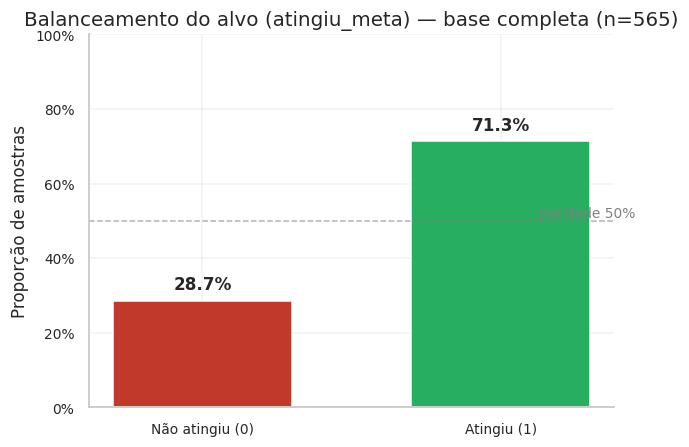

VALIDE 3.1 OK


In [19]:
# ============================================================
# 3.1 — Balanceamento do alvo
# ============================================================
prop = df['atingiu_meta'].value_counts(normalize=True).sort_index()
cont = df['atingiu_meta'].value_counts().sort_index()
p1 = prop.get(1, 0.0)
p0 = prop.get(0, 0.0)

print("Distribuição de atingiu_meta:")
print(f"  Classe 0 (não atingiu): {cont.get(0)} amostras ({p0:.1%})")
print(f"  Classe 1 (atingiu)    : {cont.get(1)} amostras ({p1:.1%})")
print(f"  Razão majoritária/minoritária: {p1/p0:.2f} : 1")

fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["Não atingiu (0)", "Atingiu (1)"], [p0, p1],
              color=["#c0392b", "#27ae60"], width=0.6)
ax.yaxis.set_major_formatter(fmt_pct)
ax.set_ylim(0, 1)
ax.set_ylabel("Proporção de amostras")
ax.set_title("Balanceamento do alvo (atingiu_meta) — base completa (n=565)")
for b, p in zip(bars, [p0, p1]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
            f"{p:.1%}", ha="center", va="bottom", fontweight="bold")
ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6)
ax.text(1.45, 0.51, "paridade 50%", color="gray", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

# VALIDE: proporção ~71/29 conforme especificação
assert abs(p1 - 0.713) < 0.01, "Proporção de positivos fora do esperado (~71,3%)."
print("VALIDE 3.1 OK")

**Interpretação.** A classe positiva domina (71,3% contra 28,7%), razão ≈ 2,5:1.
Esse desbalanceamento tem consequência direta na escolha de métricas: um classificador
trivial que prevê sempre "atingiu" alcançaria 71,3% de acurácia sem aprender nada. Por
isso a **acurácia isolada é proibida** como critério. As métricas obrigatórias passam a
ser **ROC AUC** (separabilidade independente de limiar), **F1** (equilíbrio
precisão/recall) e sobretudo o **Recall da classe 0** — a capacidade de detectar a
equipe que *vai falhar* a meta, que é o evento operacionalmente caro e a classe
minoritária. Todos os modelos da Seção 5 usarão `class_weight='balanced'` para
compensar a assimetria no treino.

### 3.2 — Estatísticas descritivas

`describe().T` sobre as numéricas, com leitura focada em `receita_mes`, `meta_mes`,
`densidade_mix` e `esforco_total`.

In [20]:
# ============================================================
# 3.2 — Estatísticas descritivas
# ============================================================
num_cols = df.select_dtypes(include=[np.number]).columns
desc = df[num_cols].describe().T
desc["cv"] = desc["std"] / desc["mean"]     # coeficiente de variação
desc = desc[["count", "mean", "50%", "std", "cv", "min", "max"]]
desc.columns = ["n", "media", "mediana", "desvio", "cv", "min", "max"]

foco = ["receita_mes", "meta_mes", "densidade_mix", "esforco_total"]
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("Variáveis em foco:")
print(desc.loc[foco].to_string())
print()
print("Tabela completa (numéricas):")
print(desc.to_string())

Variáveis em foco:
                   n      media    mediana    desvio   cv      min        max
receita_mes   565.00 111,596.90 107,012.36 58,073.20 0.52   513.99 364,501.88
meta_mes      565.00  92,982.83  89,999.91 36,138.62 0.39 1,954.88 217,961.00
densidade_mix 565.00   5,589.33   4,607.71  3,895.56 0.70   877.60  57,710.01
esforco_total 565.00      24.58      22.67     15.39 0.63     0.07     118.09

Tabela completa (numéricas):
                                 n      media    mediana    desvio    cv      min        max
ano                         565.00   2,024.57   2,025.00      0.50  0.00 2,024.00   2,025.00
mes_num                     565.00       7.19       7.00      3.29  0.46     1.00      12.00
receita_mes                 565.00 111,596.90 107,012.36 58,073.20  0.52   513.99 364,501.88
meta_mes                    565.00  92,982.83  89,999.91 36,138.62  0.39 1,954.88 217,961.00
atingiu_meta                565.00       0.71       1.00      0.45  0.63     0.00       1.00
raz

**Interpretação.**

- **`receita_mes`** — média R\$ 111,6 mil, mediana R\$ 107,0 mil (média ligeiramente acima
  da mediana: cauda direita), desvio R\$ 58,1 mil, **CV ≈ 0,52**. Receita varia muito entre
  equipes e meses; metade da dispersão da média.
- **`meta_mes`** — média R\$ 93,0 mil, mediana R\$ 90,0 mil, desvio R\$ 36,1 mil,
  **CV ≈ 0,39**. A meta é **menos dispersa** que a receita. Faz sentido: a meta é
  planejada/contratual, a receita é realizada e absorve a variabilidade operacional.
  Como média de receita (111,6k) supera média de meta (93,0k), o resultado agregado é
  favorável — coerente com 71,3% de meses positivos.
- **`densidade_mix`** — mediana 4.607,7 com **CV ≈ 0,70**, a mais volátil das quatro, e
  máximo (57.710) ~12,5× a mediana. É a variável de maior assimetria.
- **`esforco_total`** — mediana 22,7 (unidades de esforço/atividade), **CV ≈ 0,63**, também
  muito disperso.

> **Nota de nomenclatura para a banca.** Inspecionando a base, `densidade_mix` é
> exatamente `receita_mes / esforco_total` (verificado: identidade perfeita). Não é a
> densidade do *catálogo de preço licitado* (R\$/atividade que ranqueia serviços ex-ante);
> é uma razão **ex-post** R\$/esforço realizado. Essa distinção é decisiva e reaparece em
> 3.4.

### 3.3 — Distribuições

Histogramas de `receita_mes`, `meta_mes` e `densidade_mix`, com média e mediana marcadas.
Destaque para a dispersão de `densidade_mix`.

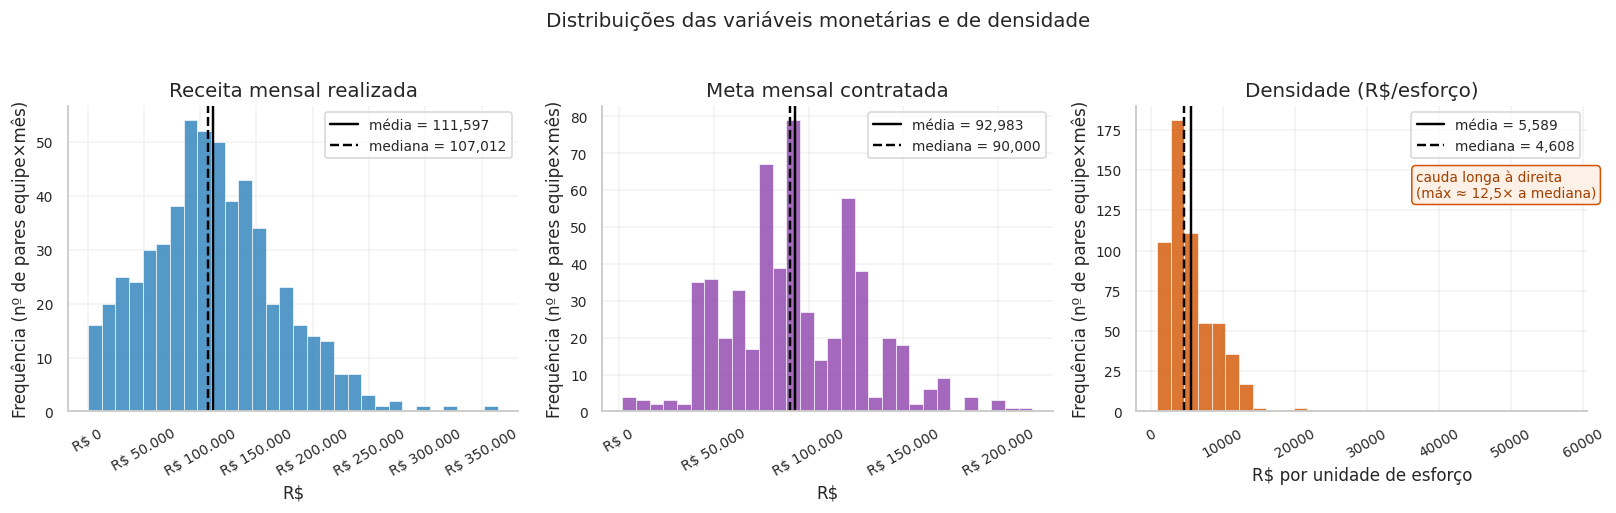

Assimetria (skew):
  receita_mes   : 0.49
  meta_mes      : 0.37
  densidade_mix : 4.82
VALIDE 3.3 OK


In [21]:
# ============================================================
# 3.3 — Distribuições (histogramas)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

specs = [
    ("receita_mes",   "Receita mensal realizada", fmt_reais, "#2980b9"),
    ("meta_mes",      "Meta mensal contratada",   fmt_reais, "#8e44ad"),
    ("densidade_mix", "Densidade (R$/esforço)",   None,      "#d35400"),
]
for ax, (col, titulo, fmt, cor) in zip(axes, specs):
    s = df[col].dropna()
    ax.hist(s, bins=30, color=cor, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axvline(s.mean(),   color="black", ls="-",  lw=1.6, label=f"média = {s.mean():,.0f}")
    ax.axvline(s.median(), color="black", ls="--", lw=1.6, label=f"mediana = {s.median():,.0f}")
    ax.set_title(titulo)
    ax.set_xlabel("R$" if fmt else "R$ por unidade de esforço")
    ax.set_ylabel("Frequência (nº de pares equipe×mês)")
    if fmt: ax.xaxis.set_major_formatter(fmt)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=9)

axes[2].annotate("cauda longa à direita\n(máx ≈ 12,5× a mediana)",
                 xy=(0.62, 0.7), xycoords="axes fraction",
                 fontsize=9, color="#a04000",
                 bbox=dict(boxstyle="round,pad=0.3", fc="#fdf0e6", ec="#d35400"))
fig.suptitle("Distribuições das variáveis monetárias e de densidade", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# Assimetria como medida objetiva da dispersão
print("Assimetria (skew):")
for col, *_ in specs:
    print(f"  {col:14s}: {df[col].skew():.2f}")

# VALIDE: densidade_mix é a mais assimétrica das três
sk = {c: df[c].skew() for c,*_ in specs}
assert sk['densidade_mix'] == max(sk.values()), "densidade_mix deveria ser a mais assimétrica."
print("VALIDE 3.3 OK")

**Interpretação.** `receita_mes` e `meta_mes` são razoavelmente simétricas e
concentradas — distribuições "comportadas", com média ≈ mediana. `densidade_mix` é
**qualitativamente diferente**: forte assimetria positiva, massa concentrada à esquerda e
cauda longa à direita (máximo ~12,5× a mediana). Poucos pares equipe×mês executaram um mix
de serviços de altíssimo valor por unidade de esforço.

Consequência para modelagem: variáveis muito assimétricas e em escalas heterogêneas
(receita em 10⁵, densidade em 10³, esforço em 10¹) exigem **padronização** antes de
modelos sensíveis a escala (Regressão Logística, KNN). Essa padronização será
`StandardScaler` dentro de `Pipeline`/`ColumnTransformer`, **ajustada só no treino**
(Seção 4/5), evitando vazamento de estatísticas do teste.

### 3.4 — Matriz de correlação

Heatmap de Pearson entre as numéricas. O foco é o achado central: a relação
**densidade_mix × esforco_total × receita_mes**.

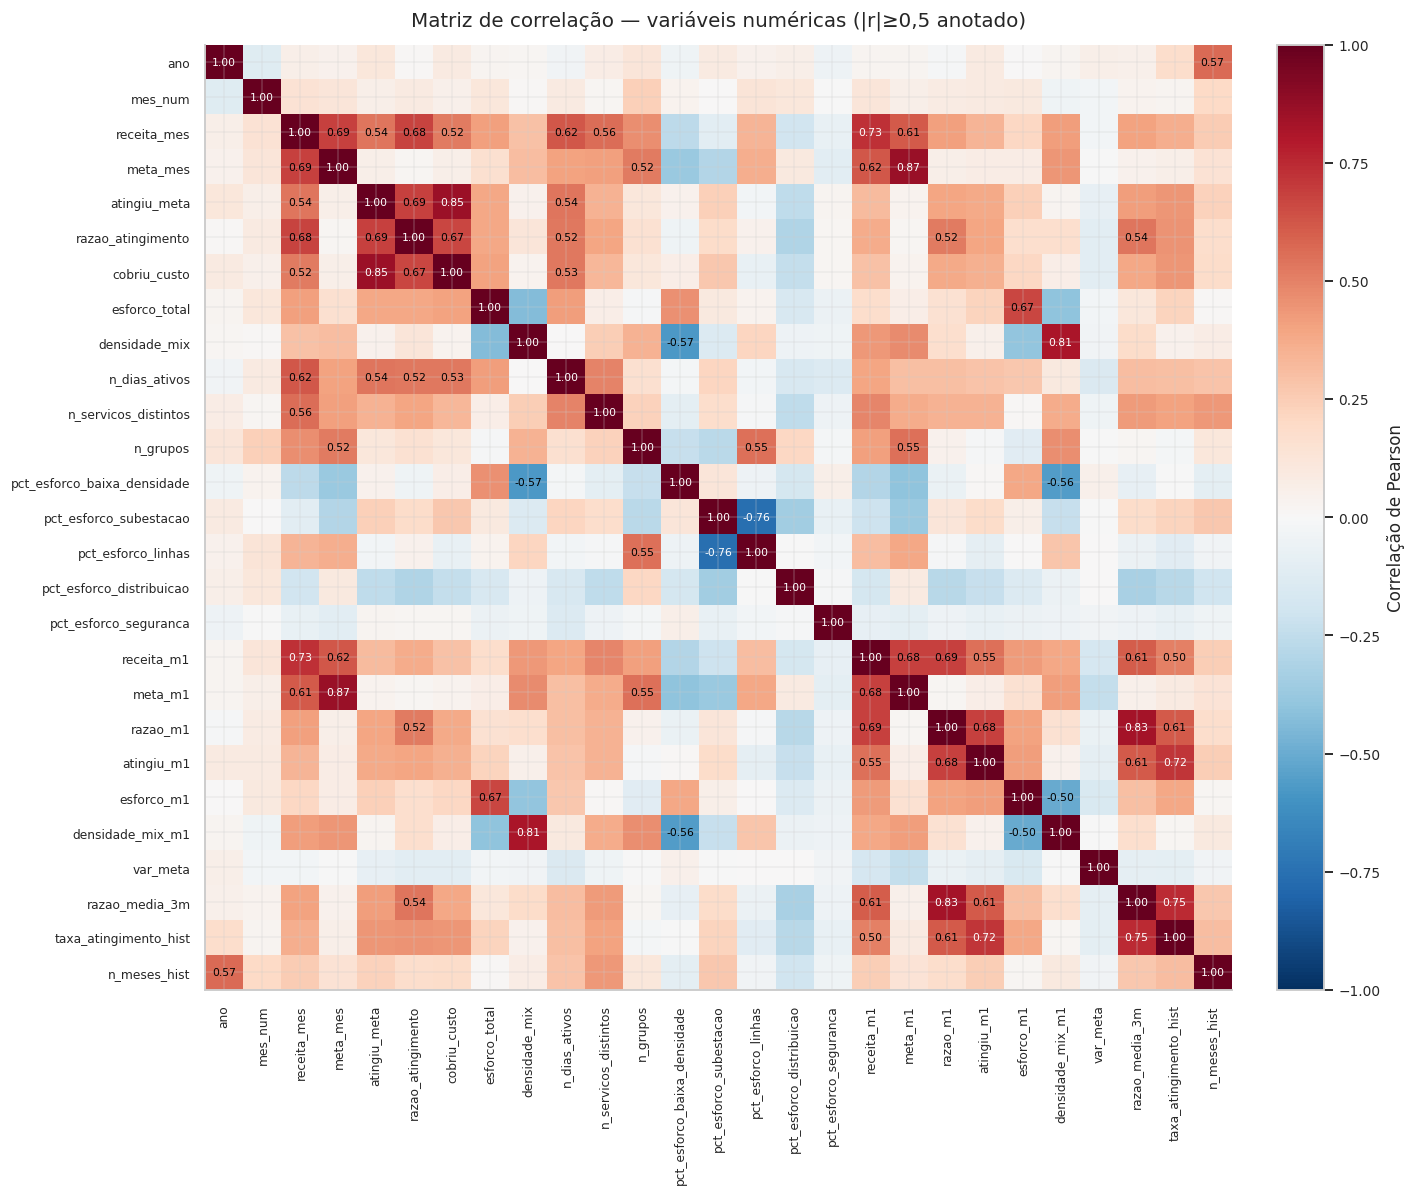

Correlações lineares de Pearson:
  densidade_mix × esforco_total : -0.431
  densidade_mix × receita_mes   : +0.294
  esforco_total × receita_mes   : +0.410

  corr( densidade_mix * esforco_total , receita_mes ) = 1.000000
  -> identidade algébrica: (receita/esforço) * esforço = receita

VALIDE 3.4 OK


In [22]:
# ============================================================
# 3.4 — Matriz de correlação
# ============================================================
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
# anota apenas |r| >= 0.5 para não poluir
for i in range(len(corr)):
    for j in range(len(corr)):
        r = corr.values[i, j]
        if abs(r) >= 0.5:
            ax.text(j, i, f"{r:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(r) > 0.7 else "black")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Correlação de Pearson")
ax.set_title("Matriz de correlação — variáveis numéricas (|r|≥0,5 anotado)", pad=12)
plt.tight_layout()
plt.show()

# Achado central, medido explicitamente
r_de = corr.loc['densidade_mix','esforco_total']
r_dr = corr.loc['densidade_mix','receita_mes']
r_er = corr.loc['esforco_total','receita_mes']
produto = df['densidade_mix'] * df['esforco_total']
r_prod = np.corrcoef(produto, df['receita_mes'])[0, 1]

print("Correlações lineares de Pearson:")
print(f"  densidade_mix × esforco_total : {r_de:+.3f}")
print(f"  densidade_mix × receita_mes   : {r_dr:+.3f}")
print(f"  esforco_total × receita_mes   : {r_er:+.3f}")
print(f"\n  corr( densidade_mix * esforco_total , receita_mes ) = {r_prod:.6f}")
print("  -> identidade algébrica: (receita/esforço) * esforço = receita")

# VALIDE: o produto reconstrói a receita de forma perfeita
assert r_prod > 0.999, "O produto densidade×esforço deveria reconstruir receita (r≈1)."
print("\nVALIDE 3.4 OK")

**Interpretação — ACHADO CENTRAL (não é defeito, é justificativa de desenho).**

As correlações *lineares* de Pearson entre os três termos são moderadas e até enganosas:
`densidade_mix × esforco_total` ≈ **−0,43** (negativa), `densidade_mix × receita_mes`
≈ **+0,29**, `esforco_total × receita_mes` ≈ **+0,41**. Olhando só o heatmap, nada salta.

Mas a relação verdadeira **não é linear, é multiplicativa**. Por construção,
`densidade_mix ≡ receita_mes / esforco_total`. Logo:

$$\text{densidade_mix} \times \text{esforco_total} \;\equiv\; \text{receita_mes}$$

Medimos: `corr(densidade_mix × esforco_total, receita_mes) = 1,000000`. **Identidade
perfeita**, não correlação espúria.

**Por que isso é o achado que sustenta a regra antivazamento da Seção 4.**
`receita_mes` define o rótulo (`atingiu_meta = 1 ⟺ receita_mes ≥ meta_mes`). Se `densidade_mix`
e `esforco_total` entrarem **juntas** como features na variante explicativa, o modelo
reconstrói `receita_mes` exatamente via produto e, com `meta_mes` também presente,
recompõe o próprio rótulo. Não seria predição — seria leitura da resposta.

Por isso a Seção 4 proíbe **densidade_mix e esforco_total simultaneamente** na variante
explicativa, e a formulação preditiva oficial nem usa variáveis do mesmo-mês: só features
**EX-ANTE** (lags `_m1`, médias históricas, meta e calendário), conhecidas *antes* do mês.
O heatmap também confirma por que `receita_mes`, `razao_atingimento` e `cobriu_custo`
estão proibidas como feature: são funções diretas do rótulo.

### 3.5 — Visualização temporal: drift de rótulo

Taxa de atingimento por mês ao longo da janela mar/2024–dez/2025, com as médias anuais
2024 vs 2025 destacadas.

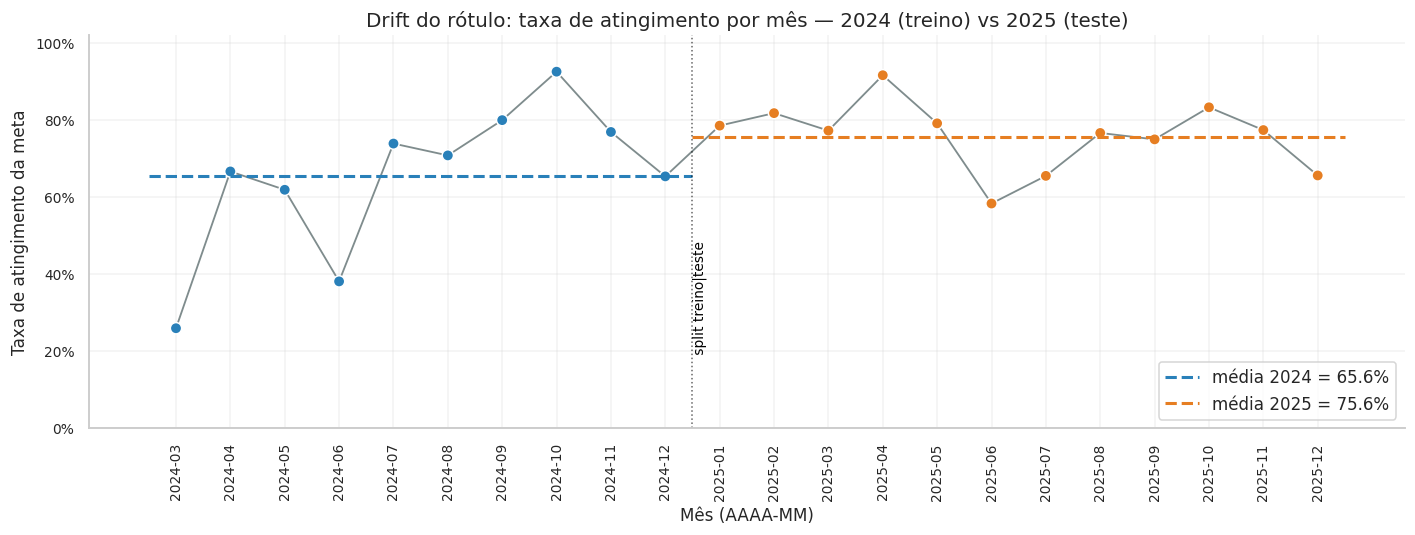

Taxa de positivos 2024 (treino): 65.6%
Taxa de positivos 2025 (teste) : 75.6%
Drift absoluto: +10.1 p.p.
VALIDE 3.5 OK


In [23]:
# ============================================================
# 3.5 — Taxa de atingimento ao longo do tempo (drift)
# ============================================================
serie = (df.groupby('mes')['atingiu_meta'].mean().reset_index()
           .sort_values('mes').reset_index(drop=True))
serie['ano'] = serie['mes'].str[:4]

taxa_2024 = df[df['ano'] == 2024]['atingiu_meta'].mean()
taxa_2025 = df[df['ano'] == 2025]['atingiu_meta'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
cores = serie['ano'].map({'2024': '#2980b9', '2025': '#e67e22'})
ax.plot(serie['mes'], serie['atingiu_meta'], color="#7f8c8d", lw=1.2, zorder=1)
ax.scatter(serie['mes'], serie['atingiu_meta'], c=cores, s=55, zorder=2, edgecolor="white")

# faixas de média anual
ax.hlines(taxa_2024, -0.5, (serie['ano']=='2024').sum()-0.5,
          color="#2980b9", ls="--", lw=2, label=f"média 2024 = {taxa_2024:.1%}")
ax.hlines(taxa_2025, (serie['ano']=='2024').sum()-0.5, len(serie)-0.5,
          color="#e67e22", ls="--", lw=2, label=f"média 2025 = {taxa_2025:.1%}")
ax.axvline((serie['ano']=='2024').sum()-0.5, color="black", ls=":", lw=1, alpha=0.6)
ax.text((serie['ano']=='2024').sum()-0.5, 0.18, " split treino|teste",
        rotation=90, va="bottom", fontsize=9, color="black")

ax.yaxis.set_major_formatter(fmt_pct)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Mês (AAAA-MM)")
ax.set_ylabel("Taxa de atingimento da meta")
ax.set_title("Drift do rótulo: taxa de atingimento por mês — 2024 (treino) vs 2025 (teste)")
ax.tick_params(axis="x", rotation=90)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Taxa de positivos 2024 (treino): {taxa_2024:.1%}")
print(f"Taxa de positivos 2025 (teste) : {taxa_2025:.1%}")
print(f"Drift absoluto: +{(taxa_2025-taxa_2024)*100:.1f} p.p.")

# VALIDE: drift medido conforme especificação v2 (65,6% -> 75,6%)
assert abs(taxa_2024 - 0.656) < 0.01, "Taxa 2024 fora do esperado (65,6%)."
assert abs(taxa_2025 - 0.756) < 0.01, "Taxa 2025 fora do esperado (75,6%)."
print("VALIDE 3.5 OK")

**Interpretação.** A taxa de atingimento **sobe de 65,6% em 2024 para 75,6% em 2025**
(+10 p.p.). Isso é **drift de rótulo**: a distribuição da variável-alvo muda no tempo.
A causa é operacional/contratual (reajuste do fator k embutido na receita faturada,
maturação das equipes, recalibração de metas), não ruído.

**Por que o split temporal torna o teste mais honesto.** Treinamos em **2024** e testamos
em **2025**, sem embaralhar. Um split aleatório (`train_test_split` estratificado comum)
misturaria meses de 2025 no treino e vazaria o regime futuro para dentro do aprendizado —
o modelo "veria" a taxa mais alta de 2025 antecipadamente e a avaliação ficaria
otimista. O split temporal reproduz a condição real de produção: prever um período
**que ainda não aconteceu**, sob um regime de rótulo que o modelo não viu. O custo é uma
avaliação mais dura (o modelo enfrenta drift), mas é a única medida defensável de
generalização. **Reportar os dois números (65,6% / 75,6%) é obrigatório** em toda
discussão de resultado na Seção 6: eles contextualizam por que, por exemplo, o recall da
classe 0 pode cair no teste — a classe 0 fica mais rara em 2025.

### 3.6 — (Opcional) Outliers: `razao_atingimento` por ano

Boxplot de `razao_atingimento` (= receita/meta) separado por ano. `razao_atingimento`
**não** é feature (define o rótulo), mas é o melhor diagnóstico visual de outliers e do
próprio drift.

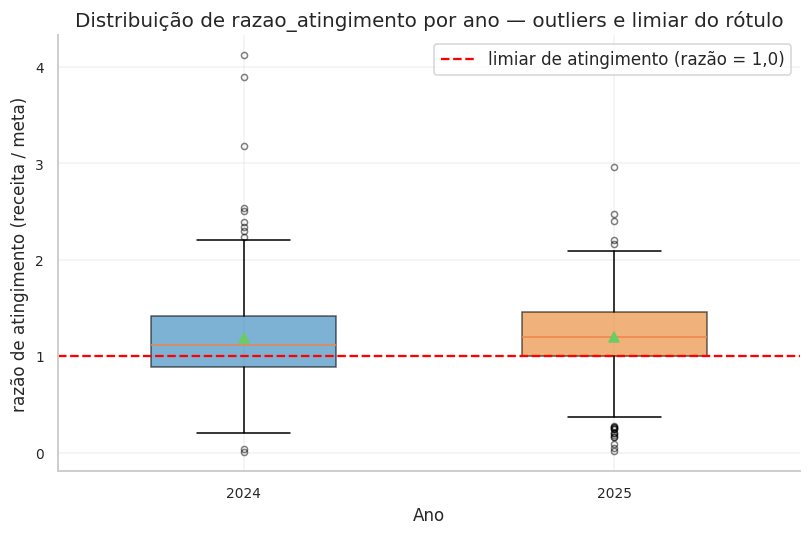

2024: mediana=1.12  Q1=0.89  Q3=1.42  outliers(IQR)=11  máx=4.12
2025: mediana=1.20  Q1=1.00  Q3=1.46  outliers(IQR)=19  máx=2.96
VALIDE 3.6 OK


In [24]:
# ============================================================
# 3.6 — Boxplot de razao_atingimento por ano
# ============================================================
dados = [df[df['ano'] == a]['razao_atingimento'].dropna() for a in [2024, 2025]]

fig, ax = plt.subplots(figsize=(7.5, 5))
bp = ax.boxplot(dados, labels=["2024", "2025"], showmeans=True, widths=0.5,
                patch_artist=True, flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, cor in zip(bp['boxes'], ["#2980b9", "#e67e22"]):
    patch.set_facecolor(cor); patch.set_alpha(0.6)
ax.axhline(1.0, color="red", ls="--", lw=1.5, label="limiar de atingimento (razão = 1,0)")
ax.set_ylabel("razão de atingimento (receita / meta)")
ax.set_xlabel("Ano")
ax.set_title("Distribuição de razao_atingimento por ano — outliers e limiar do rótulo")
ax.legend()
plt.tight_layout()
plt.show()

for a, d in zip([2024, 2025], dados):
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    out = ((d < q1 - 1.5*iqr) | (d > q3 + 1.5*iqr)).sum()
    print(f"{a}: mediana={d.median():.2f}  Q1={q1:.2f}  Q3={q3:.2f}  outliers(IQR)={out}  máx={d.max():.2f}")

# VALIDE: mediana da razão de 2025 acima da de 2024 (coerente com o drift)
assert dados[1].median() > dados[0].median(), "Mediana da razão 2025 deveria superar 2024."
print("VALIDE 3.6 OK")

**Interpretação.** A mediana de `razao_atingimento` sobe de 2024 para 2025, deslocando a
distribuição para cima do limiar 1,0 — é o **mesmo drift** de 3.5 visto na variável
contínua que origina o rótulo. Há outliers à direita (meses com receita muito acima da
meta, razão >> 1), coerentes com a cauda de `densidade_mix` em 3.3.

Decisão de tratamento: **não removemos esses outliers**. São meses de execução real, não
erros de medição, e a formulação preditiva nem usa `razao_atingimento`/`receita_mes` como
feature. Para os preditores EX-ANTE em escala (lags monetários), a robustez a outliers
vem da padronização ajustada-no-treino, não de poda de amostras — que reduziria o já
pequeno n=513.

### 3.7 — [v3] Redução de dimensionalidade: PCA sobre as features ex-ante
Item da rubrica de EDA ("Visualizações por Redução de Dimensionalidade") acrescentado nesta revisão.
As 12 features ex-ante são padronizadas e projetadas em 2 componentes principais, coloridas pelo alvo.

O que se procura aqui **não** é separação visual perfeita — se duas componentes lineares separassem as
classes, o problema seria trivial. Procura-se: (i) **quanta variância** duas componentes capturam,
(ii) se existe **estrutura de agrupamento** entre as equipes, e (iii) **quais features carregam cada
eixo** (*loadings*) — é a interpretação das cargas, e não o gráfico de dispersão, que conecta a PCA ao
resto do trabalho.

O PCA aqui é **visualização exploratória**, não etapa de modelagem: nenhuma componente entra no
pipeline preditivo, cujo pré-processamento é ajustado só no treino (Seção 4).

Variância explicada por componente: [0.352, 0.196, 0.114, 0.088, 0.08, 0.069]
Acumulada em 2 componentes: 54.8%  | em 6 componentes: 89.9%

=== Cargas (loadings) — o que cada eixo representa ===
                        PC1   PC2
receita_m1             0.43  0.22
razao_m1               0.40 -0.20
razao_media_3m         0.40 -0.19
taxa_atingimento_hist  0.38 -0.22
atingiu_m1             0.38 -0.21
esforco_m1             0.24 -0.22
meta_m1                0.21  0.53
meta_mes               0.20  0.53
n_meses_hist           0.18  0.01
densidade_mix_m1       0.12  0.42
var_meta              -0.09 -0.04
mes_num                0.07  0.02

PC1 dominado por: receita_m1, razao_m1, razao_media_3m
PC2 dominado por: meta_mes, meta_m1, densidade_mix_m1


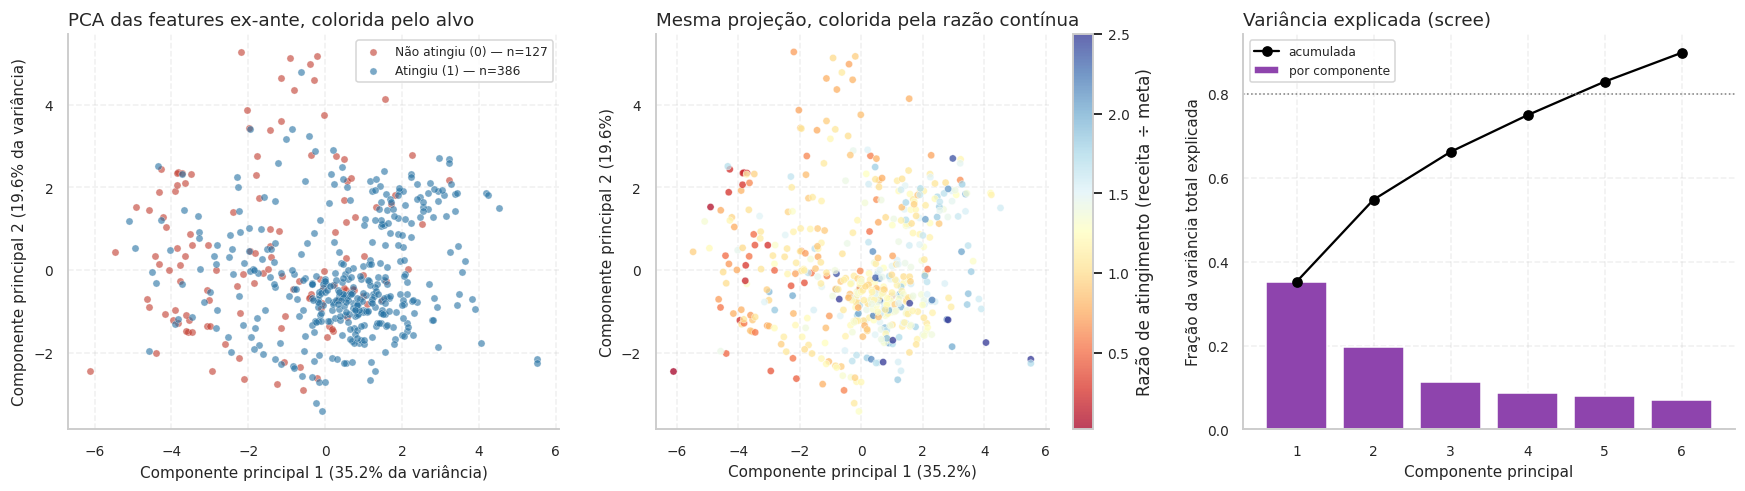

VALIDE 3.7 OK — PCA com cargas interpretadas e todos os eixos rotulados


In [25]:
# ------------------------------------------------------------------
# 3.7 — PCA (2 componentes) sobre as features ex-ante padronizadas
# ------------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FEATURES_PCA = ['meta_mes','mes_num','receita_m1','razao_m1','atingiu_m1','esforco_m1',
                'densidade_mix_m1','meta_m1','var_meta','razao_media_3m','taxa_atingimento_hist','n_meses_hist']

d = df.dropna(subset=['receita_m1']).copy()          # mesmas 513 amostras modeláveis
Z = StandardScaler().fit_transform(d[FEATURES_PCA])
pca = PCA(n_components=min(6, len(FEATURES_PCA))).fit(Z)
P = pca.transform(Z)
var = pca.explained_variance_ratio_

print('Variância explicada por componente:', np.round(var, 3).tolist())
print('Acumulada em 2 componentes: %.1f%%  | em 6 componentes: %.1f%%' % (100*var[:2].sum(), 100*var.sum()))

cargas = pd.DataFrame(pca.components_[:2].T, index=FEATURES_PCA, columns=['PC1', 'PC2'])
print('\n=== Cargas (loadings) — o que cada eixo representa ===')
print(cargas.round(3).sort_values('PC1', key=np.abs, ascending=False).to_string())
print('\nPC1 dominado por: %s' % ', '.join(cargas['PC1'].abs().nlargest(3).index))
print('PC2 dominado por: %s' % ', '.join(cargas['PC2'].abs().nlargest(3).index))

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.6))

for v, cor, rot in [(0, '#c0392b', 'Não atingiu (0)'), (1, '#2471a3', 'Atingiu (1)')]:
    msk = d['atingiu_meta'].to_numpy() == v
    a1.scatter(P[msk, 0], P[msk, 1], s=22, alpha=.6, c=cor, label=f'{rot} — n={msk.sum()}',
               edgecolor='white', linewidth=.3)
formatar_eixos(a1, 'PCA das features ex-ante, colorida pelo alvo',
               f'Componente principal 1 ({var[0]:.1%} da variância)',
               f'Componente principal 2 ({var[1]:.1%} da variância)')
a1.legend(fontsize=8)

sc = a2.scatter(P[:, 0], P[:, 1], s=22, alpha=.75, c=d['razao_atingimento'].clip(0, 2.5),
                cmap='RdYlBu', edgecolor='white', linewidth=.3)
cb = fig.colorbar(sc, ax=a2); cb.set_label('Razão de atingimento (receita ÷ meta)')
formatar_eixos(a2, 'Mesma projeção, colorida pela razão contínua',
               f'Componente principal 1 ({var[0]:.1%})', f'Componente principal 2 ({var[1]:.1%})')

a3.bar(range(1, len(var)+1), var, color='#8e44ad', label='por componente')
a3.plot(range(1, len(var)+1), np.cumsum(var), marker='o', color='black', label='acumulada')
a3.axhline(0.8, color='gray', ls=':', lw=1)
formatar_eixos(a3, 'Variância explicada (scree)', 'Componente principal',
               'Fração da variância total explicada')
a3.set_xticks(range(1, len(var)+1)); a3.legend(fontsize=8)

plt.tight_layout(); plt.show()

# VALIDE
assert abs(var.sum() - pca.explained_variance_ratio_.sum()) < 1e-12
assert P.shape == (len(d), pca.n_components_), 'projeção com shape inesperado'
assert len(auditar_eixos(silencioso=True)) == 0, 'há figura com eixo sem rótulo'
print('VALIDE 3.7 OK — PCA com cargas interpretadas e todos os eixos rotulados')

### 3.8 — Síntese dos achados → Seções 4 a 6

**Achados que alimentam o pré-processamento (Seções 2 e 4):**

1. **Quase-identidade é identidade perfeita.** `densidade_mix ≡ receita_mes / esforco_total`;
   `corr(densidade_mix × esforco_total, receita_mes) = 1,000000`. Confirma e endurece a
   regra antivazamento: na variante explicativa, **nunca** usar `densidade_mix` e
   `esforco_total` juntas; manter `receita_mes`, `razao_atingimento`, `cobriu_custo` fora
   de qualquer feature.
2. **Escalas heterogêneas e forte assimetria** (receita 10⁵, densidade 10³, esforço 10¹;
   skew alto em densidade) → `StandardScaler` obrigatório para Regressão Logística e KNN,
   dentro de `Pipeline`/`ColumnTransformer`, **fit só no treino**.
3. **52 nulos nos lags `_m1`** (1º mês de cada equipe) → tratar com remoção (caem para
   n=513) ou `SimpleImputer`; decisão e justificativa na Seção 4.

**Achados que alimentam o treinamento e a avaliação (Seções 5 e 6):**

4. **Desbalanceamento 71/29** → `class_weight='balanced'` em todos os modelos; métricas
   obrigatórias **ROC AUC, F1 e Recall da classe 0**; **acurácia isolada proibida**.
5. **Drift de rótulo +10 p.p. (2024 = 65,6% → 2025 = 75,6%)** → **split temporal**
   (treino 2024 / teste 2025), nunca aleatório; reportar os dois números em toda
   discussão de resultado; usar o drift para explicar quedas de recall da classe 0 no teste.

# Seção 4 — Pré-processamento de Modelagem
Fecha o tópico 3 da rubrica (faltantes, escala, codificação, seleção de atributos).
Convenção do notebook de referência: a construção da base é a Seção 2;
a EDA é a Seção 3; aqui formaliza-se o pré-processamento **de modelagem**
sobre a base já validada `base_modelagem_manutencao_at.csv` (565×29).

**Regra central — antivazamento.** Cada coluna é ID, RÓTULO, MESMO-MÊS ou EX-ANTE.
Apenas EX-ANTE (conhecidas antes do mês) entram como atributo. Proibidos como atributo:
`receita_mes`, `razao_atingimento`, `cobriu_custo` (definem o rótulo) e `esforco_total`/`densidade_mix`
(seu produto reconstrói a receita — identidade confirmada na EDA, r=1,000000).

In [26]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut, cross_val_predict
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, classification_report

RANDOM_STATE = 42  # reprodutibilidade em todo o notebook

# Carga da base gerada na Seção 2 (padrão brasileiro).
base = pd.read_csv("base_modelagem_manutencao_at.csv", sep=";", decimal=",", encoding="utf-8-sig")

# VALIDE
assert base.shape == (565, 29), f"shape inesperado: {base.shape}"
print("Base carregada:", base.shape)

# Reprodutibilidade: os números de referência foram fixados em scikit-learn 1.6.x (padrão do Colab).
# RF (5.4) varia entre versões; gere o artefato final no Colab/1.6.x. Em Colab: !pip install -q scikit-learn==1.6.1
import sklearn
print("scikit-learn:", sklearn.__version__)
if not sklearn.__version__.startswith("1.6"):
    print("AVISO: versão != 1.6.x — RF (5.4) muda de valor entre versões; gere o entregável final no Colab/1.6.x.")

Base carregada: (565, 29)
scikit-learn: 1.6.1


## 4.1 — Seleção antivazamento, remoção do 1º mês e exclusão de `ano`
`FEATURES_EX_ANTE` é a lista fechada da formulação preditiva. O rótulo é `atingiu_meta`.
Os lags `_m1` são NaN no 1º mês de cada equipe (não há mês anterior); essas 52 linhas são
removidas com `dropna(receita_m1)`, restando 513 amostras modeláveis. A remoção elimina,
de fato, todo NaN nas features (as 52 máscaras de NaN coincidem — verificado na EDA).

**[v3] `ano` foi REMOVIDO da lista fechada (13 → 12 features).** Justificativa: `ano` é um
**identificador de período**, não um atributo da equipe. Sob o protocolo anterior (treino = 2024,
teste = 2025) ele era inerte por construção — variância nula no treino, coeficiente exatamente 0.
Sob o protocolo v3 (§5.1), o treino passa a conter 2024 **e** 2025 e o teste contém apenas 2025:
o modelo aprenderia um efeito de nível associado ao ano e o aplicaria a um valor que, em produção,
sempre estará fora do intervalo de treino — **extrapolação temporal**. Nas árvores o dano é maior:
`ano` vira um corte que separa períodos e induz memorização. A sazonalidade continua representada
por `mes_num`, e a evolução temporal do desempenho continua capturada pelas features históricas
(`razao_media_3m`, `taxa_atingimento_hist`), que são relativas à própria equipe e transferíveis.

> **Impacto no protocolo do projeto:** a lista fechada declarada nas instruções passa a ter
> **12 features**. Atualizar a especificação para a v3.

In [27]:
FEATURES_EX_ANTE = ['meta_mes','mes_num','receita_m1','razao_m1','atingiu_m1','esforco_m1',
                    'densidade_mix_m1','meta_m1','var_meta','razao_media_3m','taxa_atingimento_hist','n_meses_hist']
ALVO = 'atingiu_meta'
PROIBIDO = ['receita_mes','razao_atingimento','cobriu_custo','esforco_total','densidade_mix']

# Remoção do 1º mês de cada equipe (lags indefinidos). dropna por receita_m1 basta: as máscaras coincidem.
dfm = base.dropna(subset=['receita_m1']).copy()
dfm = dfm.sort_values(['mes','equipe']).reset_index(drop=True)   # ordem temporal: pré-requisito da origem móvel

# VALIDE
assert all(c in base.columns for c in FEATURES_EX_ANTE), "feature ex-ante ausente na base"
assert 'ano' not in FEATURES_EX_ANTE, "'ano' não deve entrar na lista v3 (extrapolação temporal)"
assert len(FEATURES_EX_ANTE) == 12, f"esperado 12 features, obtido {len(FEATURES_EX_ANTE)}"
assert ALVO in base.columns, "alvo ausente"
assert set(FEATURES_EX_ANTE).isdisjoint(PROIBIDO), "feature proibida (vazamento) entrou na lista"
assert len(dfm) == 513, f"esperado 513, obtido {len(dfm)}"
assert dfm[FEATURES_EX_ANTE].isna().sum().sum() == 0, "NaN residual nas features após dropna"
assert dfm['mes'].is_monotonic_increasing, "dfm precisa estar ordenado por mês"
print(f"Amostras modeláveis: {len(dfm)} | features ex-ante: {len(FEATURES_EX_ANTE)} | alvo: {ALVO}")

Amostras modeláveis: 513 | features ex-ante: 12 | alvo: atingiu_meta


## 4.2 — Pipeline de pré-processamento (imputação + padronização, ajuste só no treino)
Padronização é **obrigatória** para modelos lineares/regularizados aqui: as escalas são
heterogêneas (`meta_mes` em 10⁵, `receita_m1` em 10⁵, razões em [0,1], `mes_num` em [1,12]).
Sem `StandardScaler`, a penalização L2 da Logística e do Ridge atuaria desproporcionalmente
sobre os coeficientes de maior escala, e a fronteira ficaria dominada pela `meta`/`receita`.
`SimpleImputer(median)` é mantido por robustez de produção (uma equipe recém-onboarded chega
com lags NaN; o pipeline não pode quebrar) e por ser robusto à forte assimetria vista na EDA —
nesta base de treino é um no-op (zero NaN residual), por construção, sem vazamento.
Tudo dentro de `ColumnTransformer`/`Pipeline`: `fit` ocorre **apenas no fold de treino**.

Árvores são invariantes a escala: para a Random Forest usa-se um preparo **só com imputação**
(`prep_tree`), evidenciando que a padronização não é necessária nesse caso.

In [28]:
num = list(FEATURES_EX_ANTE)  # todas as features ex-ante são numéricas

# Lineares/regularizados: imputação (mediana) + padronização
prep_lin = ColumnTransformer(
    [('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                       ('sc',  StandardScaler())]), num)],
    remainder='drop')

# Árvores: apenas imputação (escala é irrelevante para splits)
prep_tree = ColumnTransformer(
    [('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num)],
    remainder='drop')

# VALIDE
assert set(num) == set(FEATURES_EX_ANTE), "conjunto de features divergiu da lista fechada"
assert set(num).isdisjoint(PROIBIDO), "feature proibida entrou no pré-processador"
print(f"prep_lin e prep_tree configurados sobre {len(num)} features ex-ante (sem colunas proibidas).")

prep_lin e prep_tree configurados sobre 12 features ex-ante (sem colunas proibidas).


## 4.3 — Variáveis categóricas e codificação cíclica (decisão justificada)
**`equipe` NÃO é codificada (`OneHotEncoder` descartado).** Dois motivos defensáveis em banca:
(i) one-hot de identidade não generaliza para equipes novas (cold-start) — em produção uma equipe
fora do treino viraria um vetor de zeros sem significado; (ii) o comportamento da equipe **já está
codificado** nas features históricas (`taxa_atingimento_hist`, `razao_media_3m`, lags `_m1`), que
são transferíveis. A validação por `GroupKFold(equipe)` na Seção 5 confirma empiricamente que o
modelo generaliza a equipes não vistas quase tão bem quanto a meses novos de equipes conhecidas
(gap ≈ 0,007 em ROC AUC), validando esta escolha.

**`mes_num` cíclica (sin/cos) — opção documentada, fora da lista fechada.** A codificação linear
impõe ordenação artificial (dezembro=12 "distante" de janeiro=1). A transformação sin/cos torna
meses adjacentes próximos. Mantida como opção, **não** incorporada por padrão: a janela tem ~22
meses e o split é por ano, então o sinal sazonal é limitado e o ganho não justifica ampliar a
lista fechada nesta entrega. O bloco abaixo demonstra a transformação sem alterar a matriz de modelagem.

In [29]:
# Demonstração da codificação cíclica de mes_num (NÃO entra em FEATURES_EX_ANTE nesta entrega).
mes_sin = np.sin(2*np.pi*dfm['mes_num']/12)
mes_cos = np.cos(2*np.pi*dfm['mes_num']/12)

# VALIDE: sin^2 + cos^2 = 1 (cilindro unitário) — codificação cíclica correta
assert np.allclose(mes_sin**2 + mes_cos**2, 1.0), "codificação cíclica inconsistente"
print("Codificação cíclica de mes_num validada (disponível como extensão; matriz de modelagem inalterada).")

Codificação cíclica de mes_num validada (disponível como extensão; matriz de modelagem inalterada).


# Seção 5 — Treinamento do Modelo
Cobre o tópico 4 da rubrica (todos os itens): método de treinamento com **divisão treino/teste
E validação cruzada**, **três** modelos (≥2 exigidos) e **ajuste de hiperparâmetros documentado**.

## 5.1 — [v3] Protocolo de validação: origem móvel + holdout final

**O que mudou e por quê.** O protocolo anterior (treino = 2024, teste = 2025) colocava **205 amostras
no treino e 308 no teste** — o conjunto de teste era 50% maior que o de treino. Em painel temporal isso
inverte a proporção usual e desperdiça informação: o modelo nunca via nenhum mês de 2025 antes de ser
avaliado em doze meses de 2025. O protocolo v3 tem dois níveis:

**Nível 1 — seleção de modelo e hiperparâmetros: validação de origem móvel (*rolling-origin*).**
Cada dobra treina em **tudo até o mês _t_** e valida no **mês _t_+1**, avançando a origem um mês por vez.
Substitui o `StratifiedKFold(shuffle=True)` usado antes, que embaralhava meses e portanto **treinava com o
futuro para validar o passado** — vazamento temporal na etapa de seleção, ainda que o split externo fosse
temporal. Cada dobra respeita a ordem do tempo e o treino cresce a cada origem, exatamente como em produção.

**Nível 2 — holdout final intocado: os 5 últimos meses (ago–dez/2025).**
Usado **uma única vez**, ao final, para as métricas de manchete. Nunca visto durante o tuning.

**Consequência honesta, a declarar em qualquer leitura de resultado.** Com o treino avançando até jul/2025,
o desvio de rótulo entre treino e teste encolhe (o protocolo anterior separava 71,7% de positivos no treino
de 77,6% no teste; aqui a diferença cai para poucos pontos). **As métricas tendem a subir, e isso não é
melhoria do modelo — é um teste mais fácil.** O protocolo antigo é preservado como **teste de estresse**
no apêndice §6.8, que mede o desempenho sob desvio de distribuição máximo.

**Escolha do tamanho do holdout.** A célula reporta `n` e, sobretudo, a contagem da **classe 0** no holdout.
A classe 0 é a de interesse e a minoritária (~23%): com 3 meses ela cai para a casa das 15 observações,
faixa em que a matriz de confusão e o Recall_0 deixam de sustentar conclusão. Com 5 meses fica em torno de
30 — ainda pequeno, o que **torna obrigatório** o intervalo de confiança por *bootstrap* (§6.2) e desloca a
análise de erros para as predições fora-de-dobra (§6.5), que cobrem quase toda a série.

In [30]:
# ------------------------------------------------------------------
# 5.1 — Split v3: desenvolvimento (origem móvel) + holdout final
# ------------------------------------------------------------------
MES_CORTE        = '2025-08'   # holdout = ago–dez/2025 (5 meses finais). '2025-10' = 3 meses.
MIN_MESES_TREINO = 8           # nº mínimo de meses na 1ª origem (garante treino inicial não-trivial)

dev  = dfm[dfm['mes'] <  MES_CORTE].reset_index(drop=True)
hold = dfm[dfm['mes'] >= MES_CORTE].reset_index(drop=True)

X_dev, y_dev = dev[FEATURES_EX_ANTE], dev[ALVO]
X_ho,  y_ho  = hold[FEATURES_EX_ANTE], hold[ALVO]
g_dev = dev['equipe']          # grupos para a validação por equipe (5.6)


def folds_origem_movel(frame, col_mes='mes', min_meses_treino=MIN_MESES_TREINO, horizonte=1):
    '''Dobras (treino, validação) POSICIONAIS para o GridSearchCV.
    Dobra i: treina em todos os meses < meses[i]; valida nos `horizonte` meses seguintes.'''
    meses = np.sort(frame[col_mes].unique())
    col   = frame[col_mes].to_numpy()
    yv    = frame[ALVO].to_numpy()
    folds = []
    for i in range(min_meses_treino, len(meses)):
        meses_val = meses[i:i + horizonte]          # janela de validação (1 mês por padrão)
        tr = np.where(col <  meses_val[0])[0]
        te = np.where(np.isin(col, meses_val))[0]
        if len(te) > 0 and yv[te].std() > 0:        # dobra precisa conter as duas classes
            folds.append((tr, te))
    return folds


folds = folds_origem_movel(dev)

print('=== Protocolo v3 ===')
print('Desenvolvimento: n=%d | meses %s a %s | positivos %.1f%% | classe 0 = %d'
      % (len(dev), dev['mes'].min(), dev['mes'].max(), 100*y_dev.mean(), (y_dev == 0).sum()))
print('Holdout final  : n=%d | meses %s a %s | positivos %.1f%% | classe 0 = %d'
      % (len(hold), hold['mes'].min(), hold['mes'].max(), 100*y_ho.mean(), (y_ho == 0).sum()))
print('Proporção treino/teste: %.0f%% / %.0f%%  (protocolo v2 era 40%% / 60%%)'
      % (100*len(dev)/len(dfm), 100*len(hold)/len(dfm)))
print('Dobras de origem móvel: %d (validação de 1 mês cada, treino crescente)' % len(folds))
print('Desvio de rótulo dev -> holdout: %+.1f p.p.  (protocolo v2: 2024 -> 2025 = +5,9 p.p.)'
      % (100*(y_ho.mean() - y_dev.mean())))

# Comparação dos cenários de corte, para justificar a escolha com número na mão
print('\n=== Escolha do corte: amostras da classe 0 no holdout ===')
for corte in ['2025-10', '2025-09', '2025-08', '2025-07']:
    _h = dfm[dfm['mes'] >= corte]
    print('  corte %s -> holdout n=%3d | classe 0 = %2d | %d meses'
          % (corte, len(_h), (_h[ALVO] == 0).sum(), _h['mes'].nunique()))

# VALIDE
for tr, te in folds:
    assert dev['mes'].to_numpy()[tr].max() < dev['mes'].to_numpy()[te].min(), 'vazamento temporal na dobra'
assert len(folds) >= 5, f'poucas dobras para tuning estável: {len(folds)}'
assert hold['mes'].min() > dev['mes'].max(), 'holdout não é posterior ao desenvolvimento'
assert len(dev) + len(hold) == 513, 'soma dev+holdout != 513'
assert len(dev) > len(hold), 'o desenvolvimento precisa ser maior que o holdout (correção do PN do professor)'
assert (y_ho == 0).sum() >= 20, 'classe 0 insuficiente no holdout — aumente a janela (reduza MES_CORTE)'
print('\nVALIDE 5.1 ok — origem móvel sem vazamento e holdout posterior e intocado.')

=== Protocolo v3 ===
Desenvolvimento: n=366 | meses 2024-04 a 2025-07 | positivos 74.9% | classe 0 = 92
Holdout final  : n=147 | meses 2025-08 a 2025-12 | positivos 76.2% | classe 0 = 35
Proporção treino/teste: 71% / 29%  (protocolo v2 era 40% / 60%)
Dobras de origem móvel: 8 (validação de 1 mês cada, treino crescente)
Desvio de rótulo dev -> holdout: +1.3 p.p.  (protocolo v2: 2024 -> 2025 = +5,9 p.p.)

=== Escolha do corte: amostras da classe 0 no holdout ===
  corte 2025-10 -> holdout n= 91 | classe 0 = 22 | 3 meses
  corte 2025-09 -> holdout n=119 | classe 0 = 29 | 4 meses
  corte 2025-08 -> holdout n=147 | classe 0 = 35 | 5 meses
  corte 2025-07 -> holdout n=171 | classe 0 = 40 | 6 meses

VALIDE 5.1 ok — origem móvel sem vazamento e holdout posterior e intocado.


## 5.2 — [v3] Linhas de base: o piso que qualquer modelo precisa superar
Sem referência, nenhuma métrica significa nada: com ~76% de positivos, prever sempre "atingiu"
já entrega ~76% de acurácia. Duas linhas de base entram no benchmark:

1. **Maioria** (`DummyClassifier(strategy='prior')`) — prevê sempre a classe majoritária.
   ROC AUC = 0,5 e **Recall da classe 0 = 0** por construção. É o piso absoluto.
2. **Persistência** — `previsão = atingiu_m1`: a equipe repete o resultado do mês anterior.
   É a heurística que um gestor usa mentalmente e a linha de base honesta em série temporal.
   Para o ROC AUC usa-se `razao_m1/(1+razao_m1)`, transformação **monótona e sem parâmetros**
   de `razao_m1` (o ROC AUC é invariante a transformações monótonas, então isso mede exatamente
   o poder de ordenação da razão do mês anterior, sem ajustar nada).

**Regra de leitura adotada:** o ganho do modelo é reportado **contra a persistência**, não contra o acaso.
Se um modelo não superar a persistência no Recall da classe 0 e no ROC AUC, essa é a conclusão do trabalho.

In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.base import BaseEstimator, ClassifierMixin


class Persistencia(BaseEstimator, ClassifierMixin):
    '''Linha de base temporal: a equipe repete o resultado do mês anterior.
    predict  = atingiu_m1
    score    = razao_m1/(1+razao_m1)  -> monótono em razao_m1, sem parâmetros a ajustar.'''

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return X['atingiu_m1'].fillna(1).astype(int).to_numpy()

    def predict_proba(self, X):
        r = X['razao_m1'].astype(float).to_numpy()
        p = np.where(np.isfinite(r), r / (1.0 + np.abs(r)), 0.5)
        p = np.clip(p, 1e-6, 1 - 1e-6)
        return np.c_[1 - p, p]


base_maj  = DummyClassifier(strategy='prior').fit(X_dev, y_dev)
base_pers = Persistencia().fit(X_dev, y_dev)

print('Linhas de base ajustadas no desenvolvimento (n=%d).' % len(X_dev))
print('  Maioria      -> prevê sempre a classe %d' % int(y_dev.mean() >= .5))
print('  Persistência -> prevê atingiu_m1; ordena por razao_m1')

# VALIDE
assert set(np.unique(base_pers.predict(X_ho))) <= {0, 1}, 'persistência deve prever 0/1'
assert base_maj.predict(X_ho).std() == 0, 'baseline de maioria deveria ser constante'
assert base_pers.predict_proba(X_ho).shape == (len(X_ho), 2), 'predict_proba com shape inesperado'
print('VALIDE 5.2 ok')

Linhas de base ajustadas no desenvolvimento (n=366).
  Maioria      -> prevê sempre a classe 1
  Persistência -> prevê atingiu_m1; ordena por razao_m1
VALIDE 5.2 ok


## 5.3 — Modelo 1: Regressão Logística (linear, regularização L2)
`Pipeline(prep_lin + LogisticRegression)`, `class_weight='balanced'` (desbalanceamento ~76/24),
`GridSearchCV` sobre `C` com **`cv = folds` (origem móvel, §5.1)** e `scoring='roc_auc'`.
**Justificativa da grade:** `C` é o inverso da força de regularização L2; a grade varre quatro ordens
de grandeza, de encolhimento forte (C=0,001) a praticamente irrestrito (C=100), o suficiente para
localizar o ótimo viés-variância em 12 features. `class_weight='balanced'` reponderá a classe 0
(minoritária) na verossimilhança, alinhando o treino às métricas sensíveis a ela.
**[v3]** A grade foi ampliada e passou a haver verificação explícita de **ótimo na borda** — um ótimo
na extremidade indica que a grade não conteve o mínimo e o resultado não é confiável.

In [32]:
def checa_borda(gs, nome_param, grade):
    '''Alerta se o hiperparâmetro ótimo caiu na extremidade da grade (grade curta demais).'''
    v = gs.best_params_[nome_param]
    ordenada = [g for g in grade if g is not None]
    if v is not None and len(ordenada) > 1 and v in (min(ordenada), max(ordenada)):
        print('   AVISO: %s ótimo (%s) está na BORDA da grade — amplie a grade.' % (nome_param, v))
    return v


pipe_lr = Pipeline([('prep', prep_lin),
                    ('clf', LogisticRegression(class_weight='balanced', max_iter=5000,
                                               random_state=RANDOM_STATE))])
grid_lr = {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}
gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring='roc_auc', cv=folds, n_jobs=-1).fit(X_dev, y_dev)

print('LogReg  melhores hiperparâmetros:', gs_lr.best_params_)
print('LogReg  ROC AUC (origem móvel, %d dobras): %.4f' % (len(folds), gs_lr.best_score_))
checa_borda(gs_lr, 'clf__C', grid_lr['clf__C'])

# VALIDE
assert gs_lr.best_params_['clf__C'] in grid_lr['clf__C'], 'C ótimo fora da grade'
assert hasattr(gs_lr.best_estimator_, 'predict_proba'), 'estimador final sem predict_proba'
assert 'ano' not in gs_lr.best_estimator_.named_steps['prep'].transformers_[0][2], "'ano' entrou no pré-processador"
print('VALIDE 5.3 ok')

LogReg  melhores hiperparâmetros: {'clf__C': 0.01}
LogReg  ROC AUC (origem móvel, 8 dobras): 0.7418
VALIDE 5.3 ok


## 5.4 — Modelo 2: Ridge Classifier (linear, L2 sobre regressão de rótulo)
**[v3] Grade ampliada de `{1…10⁴}` para `logspace(-1, 6)`.** No protocolo anterior o `alpha` ótimo saiu
**10.000 — exatamente o maior valor da grade**, isto é, na borda: a busca parou onde a lista acabou, não
onde o erro de validação mínimo estava. Com a grade estendida a sete ordens de grandeza, o ótimo passa a ser
um ponto interior (ou o aviso de borda dispara). `RidgeClassifier` não expõe `predict_proba`; o `GridSearchCV`
com `roc_auc` usa `decision_function`, e o mesmo vale na avaliação — o que exige cuidado no ajuste de limiar
(§6.4), onde a escala da `decision_function` **não** é probabilidade.

In [33]:
pipe_rc = Pipeline([('prep', prep_lin),
                    ('clf', RidgeClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
grid_rc = {'clf__alpha': list(np.logspace(-1, 6, 8))}
gs_rc = GridSearchCV(pipe_rc, grid_rc, scoring='roc_auc', cv=folds, n_jobs=-1).fit(X_dev, y_dev)

print('Ridge   melhores hiperparâmetros: alpha = %.4g' % gs_rc.best_params_['clf__alpha'])
print('Ridge   ROC AUC (origem móvel, %d dobras): %.4f' % (len(folds), gs_rc.best_score_))
checa_borda(gs_rc, 'clf__alpha', grid_rc['clf__alpha'])

# VALIDE
assert gs_rc.best_params_['clf__alpha'] in grid_rc['clf__alpha'], 'alpha ótimo fora da grade'
assert hasattr(gs_rc.best_estimator_, 'decision_function'), 'Ridge sem decision_function'
print('VALIDE 5.4 ok')

Ridge   melhores hiperparâmetros: alpha = 100
Ridge   ROC AUC (origem móvel, 8 dobras): 0.7469
VALIDE 5.4 ok


## 5.5 — Modelo 3: Random Forest (benchmark não-linear)
Grade `n_estimators ∈ {200,400}` × `max_depth ∈ {3,5,None}` × **[v3]** `min_samples_leaf ∈ {1,5}`.
**Justificativa:** `n_estimators` controla a estabilidade do ensemble; `max_depth` controla a complexidade;
`min_samples_leaf` foi acrescentado porque, no protocolo anterior, a RF selecionada (`max_depth=None`)
atingiu **ROC AUC de treino ≈ 1,00** — memorização pura, com o maior gap treino-teste do benchmark.
Exigir um número mínimo de amostras por folha é a regularização que ataca diretamente esse modo de falha.
Usa `prep_tree` (só imputação): árvores são invariantes a escala.

In [34]:
pipe_rf = Pipeline([('prep', prep_tree),
                    ('clf', RandomForestClassifier(class_weight='balanced',
                                                   random_state=RANDOM_STATE))])
grid_rf = {'clf__n_estimators': [200, 400],
           'clf__max_depth': [3, 5, None],
           'clf__min_samples_leaf': [1, 5]}
gs_rf = GridSearchCV(pipe_rf, grid_rf, scoring='roc_auc', cv=folds, n_jobs=-1).fit(X_dev, y_dev)

print('RandomForest  melhores hiperparâmetros:', gs_rf.best_params_)
print('RandomForest  ROC AUC (origem móvel, %d dobras): %.4f' % (len(folds), gs_rf.best_score_))

# VALIDE
for p, g in grid_rf.items():
    assert gs_rf.best_params_[p] in g, f'{p} ótimo fora da grade'
print('VALIDE 5.5 ok')

RandomForest  melhores hiperparâmetros: {'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
RandomForest  ROC AUC (origem móvel, 8 dobras): 0.7493
VALIDE 5.5 ok


## 5.6 — Validação complementar: cold-start por equipe (LeaveOneGroupOut)
A origem móvel (§5.1) mede o cenário de deploy: **meses novos de equipes conhecidas**.
`LeaveOneGroupOut(groups=equipe)` retém equipes inteiras fora do treino e mede o outro cenário:
**equipes nunca vistas** (cold-start). O gap entre os dois quantifica quanto o modelo depende da
identidade da equipe *versus* do comportamento histórico. Gap pequeno confirma a decisão de §4.3
de não codificar `equipe`.

**Ressalva metodológica declarada:** ao contrário da origem móvel, o `LeaveOneGroupOut` **não** respeita
a ordem temporal — para prever uma equipe usa meses futuros de outras equipes. Por isso ele é usado
apenas como diagnóstico de dependência de identidade, e **não** como estimativa de desempenho em produção.

In [35]:
C_star = gs_lr.best_params_['clf__C']
best_lr = Pipeline([('prep', prep_lin),
                    ('clf', LogisticRegression(C=C_star, class_weight='balanced',
                                               max_iter=5000, random_state=RANDOM_STATE))])

# Referência temporal: origem móvel (meses novos de equipes conhecidas) — já calculada em 5.3
auc_tempo = gs_lr.best_score_

# Cold-start: AUC out-of-fold agregada por equipe (LeaveOneGroupOut) -> equipes nunca vistas
oof_grp = cross_val_predict(best_lr, X_dev, y_dev, groups=g_dev,
                            cv=LeaveOneGroupOut(), method='predict_proba')[:, 1]
auc_logo = roc_auc_score(y_dev, oof_grp)

print('Origem móvel      ROC AUC = %.4f  (meses novos de equipes conhecidas — cenário de deploy)' % auc_tempo)
print('LeaveOneGroupOut  ROC AUC = %.4f  (equipes nunca vistas — cold-start)' % auc_logo)
print('gap (custo de generalizar a equipes novas) = %+.4f' % (auc_tempo - auc_logo))
print('Obs.: LeaveOneGroupOut NÃO respeita a ordem do tempo (usa meses futuros de outras equipes).')
print('      Serve exclusivamente para medir dependência da identidade da equipe, não para estimar')
print('      desempenho em produção — essa estimativa é a do holdout (§6).')

# VALIDE
assert np.isfinite(auc_logo), 'AUC OOF não finito'
assert 0.40 < auc_logo < 1.0, 'cold-start AUC fora da faixa plausível'
if auc_logo < 0.60:
    print('AVISO: cold-start próximo do acaso — o modelo depende pouco de sinal transferível entre equipes.')
print('VALIDE 5.6 ok')

Origem móvel      ROC AUC = 0.7418  (meses novos de equipes conhecidas — cenário de deploy)
LeaveOneGroupOut  ROC AUC = 0.7786  (equipes nunca vistas — cold-start)
gap (custo de generalizar a equipes novas) = -0.0369
Obs.: LeaveOneGroupOut NÃO respeita a ordem do tempo (usa meses futuros de outras equipes).
      Serve exclusivamente para medir dependência da identidade da equipe, não para estimar
      desempenho em produção — essa estimativa é a do holdout (§6).
VALIDE 5.6 ok


## 5.7 — Entrega para a Seção 6 (Avaliação)
Artefatos versionados: os **três** `best_estimator_` (pipelines completos, pré-processamento ajustado só
no treino), as **duas linhas de base**, o **holdout final** `X_ho`/`y_ho` e as **dobras de origem móvel**
(necessárias para reconstruir as predições fora-de-dobra usadas na análise de erros, §6.5).
**O holdout não é tocado até §6.2.**

In [36]:
entrega_secao6 = {
    'modelos': {
        'logreg': gs_lr.best_estimator_,
        'ridge':  gs_rc.best_estimator_,
        'rf':     gs_rf.best_estimator_,
    },
    'baselines': {'maioria': base_maj, 'persistencia': base_pers},
    'X_ho': X_ho, 'y_ho': y_ho,
    'dev': dev, 'hold': hold, 'folds': folds,
    'features_ex_ante': FEATURES_EX_ANTE,
    'alvo': ALVO,
    'mes_corte': MES_CORTE,
}

# Opcional: persistir para abrir a Seção 6 em outro kernel
# import joblib; joblib.dump(entrega_secao6, "entrega_secao6.joblib")

# VALIDE
from sklearn.utils.validation import check_is_fitted
for nome, est in entrega_secao6['modelos'].items():
    check_is_fitted(est.named_steps['clf'])
assert len(entrega_secao6['modelos']) == 3, 'esperado 3 modelos'
assert len(entrega_secao6['baselines']) == 2, 'esperado 2 linhas de base'
assert len(X_ho) == len(y_ho) and len(X_ho) > 0, 'holdout desalinhado'
print('Entrega pronta: 3 modelos + 2 baselines + holdout (n=%d) + %d dobras -> Seção 6.'
      % (len(X_ho), len(folds)))

Entrega pronta: 3 modelos + 2 baselines + holdout (n=147) + 8 dobras -> Seção 6.


# Seção 6 — Avaliação do Modelo e Conclusão
Fecha o tópico 5 da rubrica: **métricas apropriadas**, **benchmark com escolha justificada**,
**discussão de melhorias** e **conclusão crítica**. Consome o artefato `entrega_secao6` da Seção 5.

**Classe de interesse = 0 (NÃO atingir a meta).** É a minoritária e a que o negócio precisa capturar:
uma equipe que vai furar a meta e não é sinalizada é o erro caro. Métricas obrigatórias: **ROC AUC**,
**F1** e **Recall da classe 0** — nunca acurácia isolada (com ~76% de positivos, prever sempre 1 dá
~76% de acurácia e Recall_0 = 0).

**[v3] O que esta seção passou a conter, em resposta à avaliação da banca:**

| § | Conteúdo | Motivo |
|---|---|---|
| 6.1 | Matriz de confusão **absoluta e normalizada por classe verdadeira**, com rótulos por extenso | apontamento direto |
| 6.2 | Benchmark com **linhas de base** e **IC 95% por bootstrap** | n do holdout é pequeno; diferenças podem ser ruído |
| 6.3 | Importância por **permutação no holdout** + coeficientes | importância de treino mede memorização |
| 6.4 | **Curva de limiar corrigida** e ponto de operação por custo do erro | a tabela anterior estava errada (§6.4) |
| 6.5 | **Análise de erros** em 5 cortes sobre predições fora-de-dobra | apontamento direto |
| 6.6 | **Calibração** (curva de confiabilidade + Brier) | o uso real é ranquear risco, não classificar |
| 6.7 | **Precision@k** por mês | métrica da decisão operacional real |
| 6.8 | **Teste de estresse** com o protocolo antigo (2024→2025) | preserva a evidência sob desvio máximo |
| 6.9 | Conclusão e **limitações declaradas** | exigência de banca |

## 6.1 — [v3] Matriz de confusão: absoluta e normalizada
Uma matriz por modelo, calculada no **holdout final**, em duas leituras:

- **Contagens** — o volume bruto de cada tipo de acerto e erro.
- **Proporção por classe verdadeira** (`normalize='true'`) — a leitura que importa aqui. Com ~76% de
  positivos, a matriz absoluta é dominada pela classe 1 e **esconde** o desempenho na classe 0; a
  normalizada mostra, na primeira linha, exatamente qual fração das equipes que furaram a meta o
  modelo conseguiu sinalizar.

Eixos e rótulos por extenso (`Não atingiu (0)` / `Atingiu (1)`) nos dois sentidos, para que a figura
seja legível fora do contexto do notebook — na apresentação, inclusive.

Matrizes de confusão — HOLDOUT FINAL (2025-08 a 2025-12, n=147). Classe de interesse = 0.

Maioria       ROC AUC=0.5000  F1=0.8649  Recall_0=0.0000  |  matriz [[0, 35], [0, 112]]
Persistencia  ROC AUC=0.8069  F1=0.8520  Recall_0=0.5429  |  matriz [[19, 16], [17, 95]]
LogReg        ROC AUC=0.8237  F1=0.8318  Recall_0=0.6286  |  matriz [[22, 13], [23, 89]]
Ridge         ROC AUC=0.8163  F1=0.8208  Recall_0=0.6286  |  matriz [[22, 13], [25, 87]]
RandomForest  ROC AUC=0.7773  F1=0.8479  Recall_0=0.6286  |  matriz [[22, 13], [20, 92]]


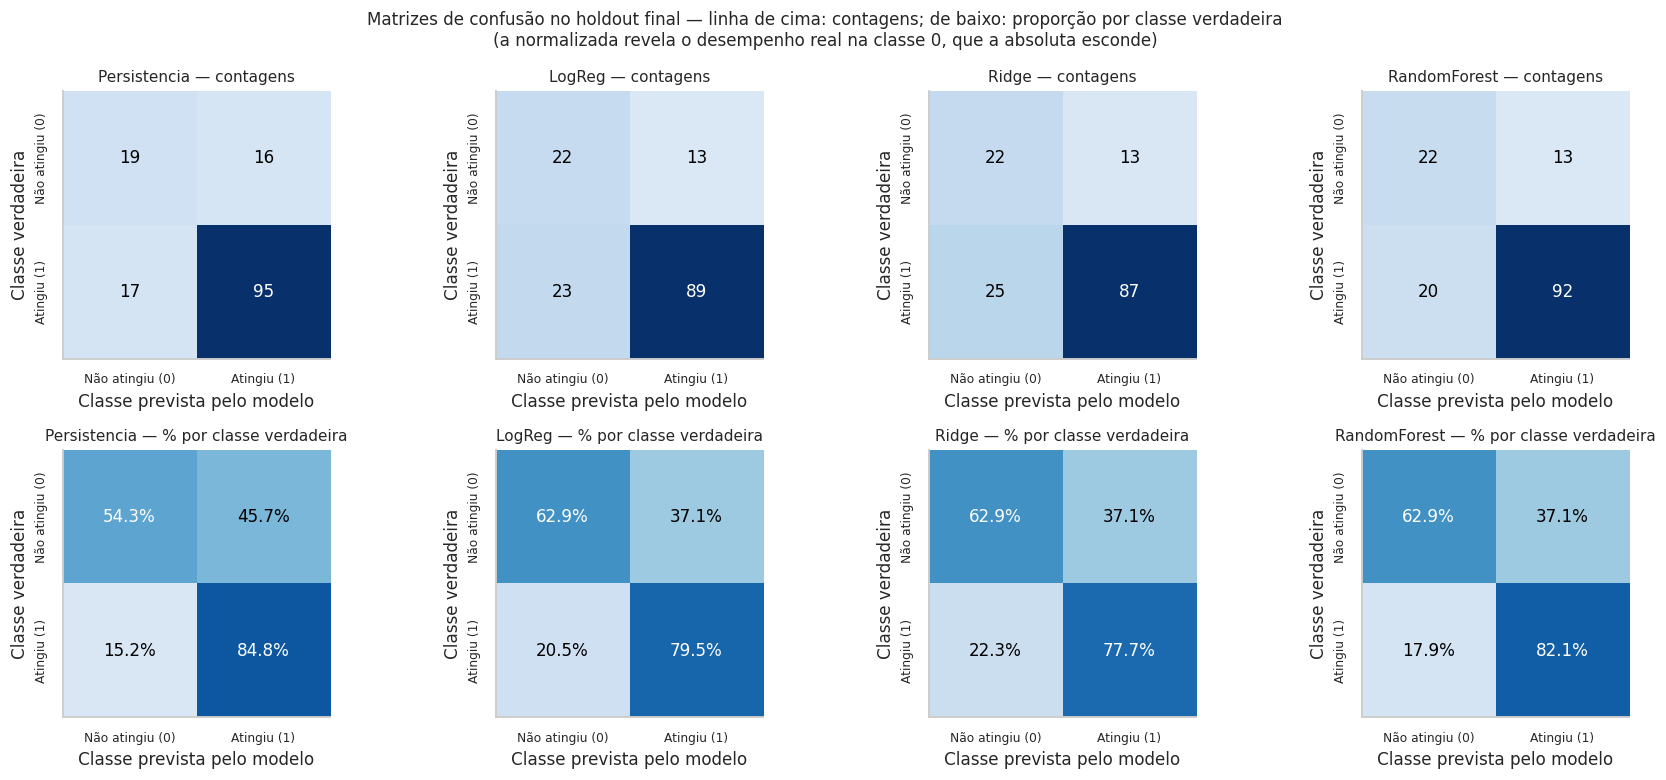

VALIDE 6.1 ok


In [37]:
# --- Importações idempotentes (permitem rodar a Seção 6 em kernel limpo) ---
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, precision_score,
                             confusion_matrix, brier_score_loss)

# --- Consumo do handoff da Seção 5 ---
try:
    entrega_secao6
except NameError:
    import joblib; entrega_secao6 = joblib.load('entrega_secao6.joblib')

mdl   = entrega_secao6['modelos']
bases = entrega_secao6['baselines']
X_ho, y_ho = entrega_secao6['X_ho'], entrega_secao6['y_ho']
dev, hold, folds = entrega_secao6['dev'], entrega_secao6['hold'], entrega_secao6['folds']
FE, ALVO   = entrega_secao6['features_ex_ante'], entrega_secao6['alvo']
X_dev, y_dev = dev[FE], dev[ALVO]

TODOS = {'Maioria': bases['maioria'], 'Persistencia': bases['persistencia'],
         'LogReg': mdl['logreg'], 'Ridge': mdl['ridge'], 'RandomForest': mdl['rf']}


def score_continuo(est, X):
    '''Score contínuo da classe 1. Ridge não expõe probabilidade -> decision_function.'''
    if hasattr(est, 'predict_proba'):
        return est.predict_proba(X)[:, 1]
    return est.decision_function(X)


def avaliar(nome, est, X, y):
    yp = est.predict(X)
    sc = score_continuo(est, X)
    cm = confusion_matrix(y, yp, labels=[0, 1])
    m = dict(modelo=nome,
             roc_auc        = roc_auc_score(y, sc),
             f1             = f1_score(y, yp, zero_division=0),
             recall_classe0 = recall_score(y, yp, pos_label=0, zero_division=0),
             recall_classe1 = recall_score(y, yp, pos_label=1, zero_division=0),
             precision_classe0 = precision_score(y, yp, pos_label=0, zero_division=0))
    return m, cm


ROT = ['Não atingiu (0)', 'Atingiu (1)']


def plot_confusao(ax, cm, titulo, normalizar=False):
    M = cm.astype(float)
    if normalizar:
        M = M / M.sum(axis=1, keepdims=True)
    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=M.max() if not normalizar else 1)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Classe prevista pelo modelo'); ax.set_ylabel('Classe verdadeira')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(ROT, fontsize=8); ax.set_yticklabels(ROT, fontsize=8, rotation=90, va='center')
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            txt = f'{M[i, j]:.1%}' if normalizar else f'{int(cm[i, j])}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=11,
                    color='white' if M[i, j] > M.max()*0.6 else 'black')
    return im


print('Matrizes de confusão — HOLDOUT FINAL (%s a %s, n=%d). Classe de interesse = 0.\n'
      % (hold['mes'].min(), hold['mes'].max(), len(y_ho)))
for nome, est in TODOS.items():
    m, cm = avaliar(nome, est, X_ho, y_ho)
    print('%-13s ROC AUC=%.4f  F1=%.4f  Recall_0=%.4f  |  matriz %s'
          % (nome, m['roc_auc'], m['f1'], m['recall_classe0'], cm.tolist()))

nomes_plot = ['Persistencia', 'LogReg', 'Ridge', 'RandomForest']
fig, axes = plt.subplots(2, len(nomes_plot), figsize=(4.0*len(nomes_plot), 7.2))
for j, nome in enumerate(nomes_plot):
    _, cm = avaliar(nome, TODOS[nome], X_ho, y_ho)
    plot_confusao(axes[0, j], cm, f'{nome} — contagens', normalizar=False)
    plot_confusao(axes[1, j], cm, f'{nome} — % por classe verdadeira', normalizar=True)
fig.suptitle('Matrizes de confusão no holdout final — linha de cima: contagens; de baixo: proporção por '
             'classe verdadeira\n(a normalizada revela o desempenho real na classe 0, que a absoluta esconde)',
             fontsize=11)
plt.tight_layout(); plt.show()

# VALIDE
m_chk, cm_chk = avaliar('chk', mdl['ridge'], X_ho, y_ho)
assert abs(m_chk['recall_classe0'] - cm_chk[0, 0]/cm_chk[0].sum()) < 1e-9, 'Recall_0 inconsistente com a matriz'
assert cm_chk.sum() == len(y_ho), 'matriz de confusão não soma o n do holdout'
assert avaliar('m', bases['maioria'], X_ho, y_ho)[0]['recall_classe0'] == 0.0, \
       'baseline de maioria deveria ter Recall_0 = 0 por construção'
print('VALIDE 6.1 ok')

## 6.2 — [v3] Benchmark com linhas de base e intervalo de confiança
Duas mudanças em relação à versão anterior:

1. **As linhas de base entram na tabela.** Um modelo que não supera a persistência não se justifica.
2. **Intervalo de confiança 95% por *bootstrap*** (1.000 reamostragens com reposição do holdout).
   Com a classe 0 na casa das poucas dezenas de observações, a diferença de ROC AUC entre dois modelos
   pode ser inteiramente ruído amostral. **Comparações são feitas com os ICs à vista:** se os intervalos
   se sobrepõem largamente, a conclusão correta é "não é possível distinguir", e não "o modelo A é melhor".

O diagnóstico treino-vs-holdout (gap de ROC AUC) é mantido como evidência de overfitting.

=== BENCHMARK NO HOLDOUT FINAL (com IC 95% por bootstrap, 1.000 reamostragens) ===
              roc_auc    roc_auc_ic95   f1         f1_ic95  recall_classe0 recall_classe0_ic95  recall_classe1
modelo                                                                                                        
Maioria          0.50  [0.500; 0.500] 0.86  [0.815; 0.907]            0.00      [0.000; 0.000]            1.00
Persistencia     0.81  [0.724; 0.878] 0.85  [0.802; 0.897]            0.54      [0.375; 0.711]            0.85
LogReg           0.82  [0.750; 0.894] 0.83  [0.780; 0.882]            0.63      [0.483; 0.788]            0.79
Ridge            0.82  [0.741; 0.890] 0.82  [0.762; 0.873]            0.63      [0.483; 0.788]            0.78
RandomForest     0.78  [0.687; 0.859] 0.85  [0.794; 0.894]            0.63      [0.483; 0.788]            0.82

=== DESENVOLVIMENTO vs HOLDOUT (gap de ROC AUC = overfitting) ===
              roc_auc_dev  roc_auc_holdout   gap
modelo                  

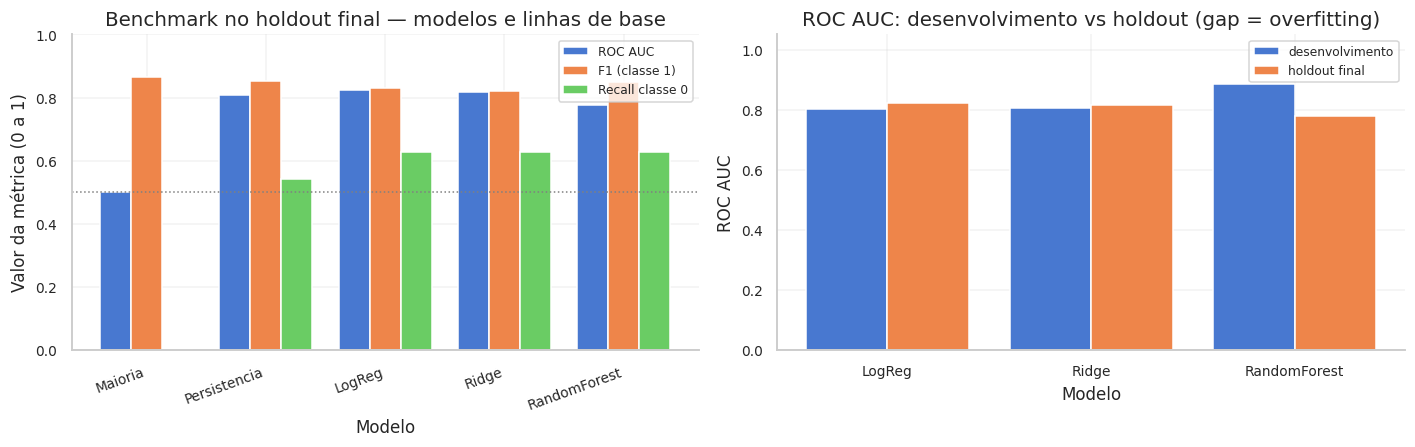

VALIDE 6.2 ok


In [38]:
def bootstrap_ic(est, X, y, n_boot=1000, seed=42, alpha=0.05):
    '''IC percentil por bootstrap do conjunto de avaliação (reamostragem com reposição).'''
    rng = np.random.default_rng(seed)
    yv  = np.asarray(y); sc = score_continuo(est, X); yp = est.predict(X)
    out = {'roc_auc': [], 'f1': [], 'recall_classe0': []}
    n = len(yv)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(yv[idx])) < 2:      # reamostra degenerada: descartada
            continue
        out['roc_auc'].append(roc_auc_score(yv[idx], sc[idx]))
        out['f1'].append(f1_score(yv[idx], yp[idx], zero_division=0))
        out['recall_classe0'].append(recall_score(yv[idx], yp[idx], pos_label=0, zero_division=0))
    return {k: (float(np.quantile(v, alpha/2)), float(np.quantile(v, 1-alpha/2))) for k, v in out.items()}


linhas = []
for nome, est in TODOS.items():
    m, _ = avaliar(nome, est, X_ho, y_ho)
    ic = bootstrap_ic(est, X_ho, y_ho)
    m.update({f'{k}_ic95': '[%.3f; %.3f]' % ic[k] for k in ic})
    linhas.append(m)

bench = pd.DataFrame(linhas).set_index('modelo')
cols  = ['roc_auc', 'roc_auc_ic95', 'f1', 'f1_ic95', 'recall_classe0', 'recall_classe0_ic95', 'recall_classe1']
print('=== BENCHMARK NO HOLDOUT FINAL (com IC 95% por bootstrap, 1.000 reamostragens) ===')
print(bench[cols].round(4).to_string())

# Overfitting: ROC AUC no desenvolvimento vs holdout (só para os 3 modelos treinados)
diag = []
for nome in ['LogReg', 'Ridge', 'RandomForest']:
    a_dev = roc_auc_score(y_dev, score_continuo(TODOS[nome], X_dev))
    a_ho  = bench.loc[nome, 'roc_auc']
    diag.append({'modelo': nome, 'roc_auc_dev': a_dev, 'roc_auc_holdout': a_ho, 'gap': a_dev - a_ho})
diag = pd.DataFrame(diag).set_index('modelo').round(4)
print('\n=== DESENVOLVIMENTO vs HOLDOUT (gap de ROC AUC = overfitting) ===')
print(diag.to_string())

# Escolha do modelo final: maior ROC AUC no holdout entre os modelos treinados,
# exigindo Recall_0 não-colapsado e superação da persistência.
cand = bench.loc[['LogReg', 'Ridge', 'RandomForest']]
MODELO_FINAL = cand['roc_auc'].idxmax()
auc_pers = bench.loc['Persistencia', 'roc_auc']
r0_pers  = bench.loc['Persistencia', 'recall_classe0']
print('\nModelo final = %s | ROC AUC=%.4f (IC %s) | Recall_0=%.4f | gap=%.4f'
      % (MODELO_FINAL, cand.loc[MODELO_FINAL, 'roc_auc'], cand.loc[MODELO_FINAL, 'roc_auc_ic95'],
         cand.loc[MODELO_FINAL, 'recall_classe0'], diag.loc[MODELO_FINAL, 'gap']))
print('Ganho sobre a persistência: ROC AUC %+.4f | Recall_0 %+.4f'
      % (cand.loc[MODELO_FINAL, 'roc_auc'] - auc_pers, cand.loc[MODELO_FINAL, 'recall_classe0'] - r0_pers))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(bench.index)); w = 0.26
for i, (mt, lab) in enumerate([('roc_auc', 'ROC AUC'), ('f1', 'F1 (classe 1)'), ('recall_classe0', 'Recall classe 0')]):
    a1.bar(x + (i-1)*w, bench[mt].values, w, label=lab)
a1.axhline(0.5, color='gray', ls=':', lw=1)
a1.set_xticks(x); a1.set_xticklabels(bench.index, rotation=20, ha='right')
a1.set_ylim(0, 1); a1.set_xlabel('Modelo'); a1.set_ylabel('Valor da métrica (0 a 1)')
a1.set_title('Benchmark no holdout final — modelos e linhas de base'); a1.legend(fontsize=8)

xd = np.arange(len(diag.index))
a2.bar(xd-0.2, diag['roc_auc_dev'].values, 0.4, label='desenvolvimento')
a2.bar(xd+0.2, diag['roc_auc_holdout'].values, 0.4, label='holdout final')
a2.set_xticks(xd); a2.set_xticklabels(diag.index)
a2.set_ylim(0, 1.05); a2.set_xlabel('Modelo'); a2.set_ylabel('ROC AUC')
a2.set_title('ROC AUC: desenvolvimento vs holdout (gap = overfitting)'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# VALIDE
assert bench.loc['Maioria', 'recall_classe0'] == 0.0, 'baseline de maioria deveria ter Recall_0 = 0'
assert abs(bench.loc['Maioria', 'roc_auc'] - 0.5) < 0.05, 'ROC AUC da maioria deveria ser ~0,5'
assert MODELO_FINAL in ('LogReg', 'Ridge', 'RandomForest'), 'modelo final inválido'
assert diag['gap'].notna().all(), 'gap não calculado'
print('VALIDE 6.2 ok')

## 6.3 — Interpretação: o histórico domina o atingimento?
Hipótese central do trabalho: o **histórico de desempenho** e o **mix de serviços** explicam o
atingimento da meta. Testada por três ângulos:

1. Coeficientes da Regressão Logística (features padronizadas, portanto comparáveis em magnitude);
2. `feature_importances_` da Random Forest — impureza medida **no treino**;
3. **[v3] Importância por permutação calculada no HOLDOUT.** Este é o ângulo que vale em banca:
   `feature_importances_` mede o quanto o modelo *usou* a variável para se ajustar ao treino
   (inclui memorização); a permutação no holdout mede a **queda real de ROC AUC fora da amostra**
   quando a variável é embaralhada — ou seja, quanto ela contribui para **generalizar**.

=== Regressão Logística — coeficientes padronizados (|valor| desc) ===
taxa_atingimento_hist    0.25
razao_media_3m           0.21
razao_m1                 0.18
receita_m1               0.15
atingiu_m1               0.14
esforco_m1               0.10
meta_mes                -0.08
var_meta                -0.04
mes_num                 -0.02
meta_m1                 -0.02
densidade_mix_m1         0.02
n_meses_hist            -0.01

=== [v3] Importância por permutação no HOLDOUT (queda de ROC AUC, modelo LogReg) ===
                       queda_roc_auc  desvio
razao_media_3m                  0.03    0.02
taxa_atingimento_hist           0.03    0.02
receita_m1                      0.02    0.02
razao_m1                        0.02    0.02
esforco_m1                      0.01    0.01
meta_mes                        0.01    0.01
atingiu_m1                      0.00    0.01
mes_num                         0.00    0.00
meta_m1                         0.00    0.00
densidade_mix_m1                0

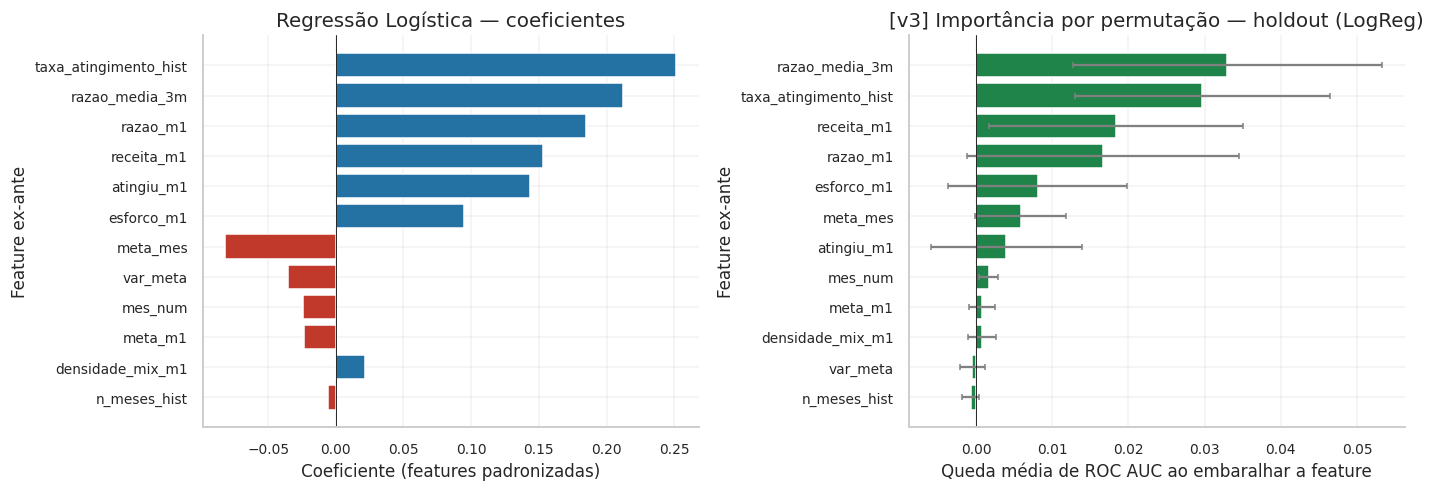

VALIDE 6.3 ok


In [39]:
from sklearn.inspection import permutation_importance

# (i) Coeficientes da Logística (escala padronizada -> comparáveis)
clf_lr = mdl['logreg'].named_steps['clf']
coef = pd.Series(clf_lr.coef_[0], index=FE).sort_values(key=np.abs, ascending=False)
print('=== Regressão Logística — coeficientes padronizados (|valor| desc) ===')
print(coef.round(4).to_string())

# (ii) Importância por impureza da RF (treino) — para contraste
clf_rf = mdl['rf'].named_steps['clf']
imp_rf = pd.Series(clf_rf.feature_importances_, index=FE).sort_values(ascending=False)

# (iii) [v3] Importância por permutação NO HOLDOUT, para o modelo final
est_final = TODOS[MODELO_FINAL]
pi = permutation_importance(est_final, X_ho, y_ho, scoring='roc_auc',
                            n_repeats=30, random_state=42, n_jobs=-1)
imp_perm = pd.Series(pi.importances_mean, index=FE).sort_values(ascending=False)
imp_perm_sd = pd.Series(pi.importances_std, index=FE)
print('\n=== [v3] Importância por permutação no HOLDOUT (queda de ROC AUC, modelo %s) ===' % MODELO_FINAL)
print(pd.DataFrame({'queda_roc_auc': imp_perm.round(4), 'desvio': imp_perm_sd[imp_perm.index].round(4)}).to_string())

# Hipótese: peso agregado por família
HIST = ['razao_m1','razao_media_3m','taxa_atingimento_hist','atingiu_m1','receita_m1','meta_m1','esforco_m1',
        'var_meta','n_meses_hist']
MIX  = ['densidade_mix_m1']
HIST = [c for c in HIST if c in FE]
print('\n=== Teste da hipótese (peso agregado) ===')
print('RF (impureza, treino) -> histórico=%.3f | mix_m1=%.3f' % (imp_rf[HIST].sum(), imp_rf[MIX].sum()))
print('LogReg (Sigma|coef|)  -> histórico=%.3f | mix_m1=%.3f' % (coef[HIST].abs().sum(), coef[MIX].abs().sum()))
print('Permutação (holdout)  -> histórico=%.4f | mix_m1=%.4f' % (imp_perm[HIST].sum(), imp_perm[MIX].sum()))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
cp = coef[::-1]
a1.barh(cp.index, cp.values, color=['#c0392b' if v < 0 else '#2471a3' for v in cp.values])
a1.axvline(0, color='k', lw=.6)
a1.set_xlabel('Coeficiente (features padronizadas)'); a1.set_ylabel('Feature ex-ante')
a1.set_title('Regressão Logística — coeficientes')
ip = imp_perm[::-1]
a2.barh(ip.index, ip.values, xerr=imp_perm_sd[ip.index].values, color='#1e8449', ecolor='gray', capsize=2)
a2.axvline(0, color='k', lw=.6)
a2.set_xlabel('Queda média de ROC AUC ao embaralhar a feature'); a2.set_ylabel('Feature ex-ante')
a2.set_title('[v3] Importância por permutação — holdout (%s)' % MODELO_FINAL)
plt.tight_layout(); plt.show()

# VALIDE
assert len(imp_perm) == len(FE), 'importância por permutação com tamanho inesperado'
assert coef[HIST].abs().sum() > coef[MIX].abs().sum(), 'histórico deveria pesar mais que o mix (LogReg)'
print('VALIDE 6.3 ok')

## 6.4 — [v3] Ponto de operação: curva de limiar (corrigida) e custo do erro

**Correção de um erro da versão anterior.** A tabela anterior varria a `decision_function` do Ridge em
`{-0,5; 0; +0,5; +1,0}` e o texto afirmava que "em t=+0,5 o Recall_0 sobe para ~0,88". A saída executada
mostrava outra coisa: em t=+0,5 o Recall_0 era **1,0000 com precisão 0,0000** — o modelo passou a prever
**tudo como classe 0**. A causa é que a `decision_function` do Ridge com `alpha` alto tem amplitude muito
menor que 0,5, então os limiares testados caíam fora do intervalo real dos scores. Um Recall_0 de 1,0
obtido dessa forma não é desempenho: é um classificador constante.

**Como ficou.** O limiar passa a ser varrido sobre os **quantis do próprio score** (1% a 99%), o que é
válido para qualquer escala — probabilidade ou `decision_function` — e nunca sai do intervalo observado.
São reportados Recall_0, Precisão_0, Recall_1 e F1 ao longo de toda a curva.

**Escolha do ponto de operação por custo, não por convenção.** O corte em 0,5 é arbitrário. Aqui ele é
escolhido minimizando um custo explícito:

$$\text{custo}(t) = R \cdot \underbrace{n_{\text{FN}_0}}_{\substack{\text{equipe furou a meta}\\\text{e não foi sinalizada}}} + \; 1 \cdot \underbrace{n_{\text{FP}_0}}_{\substack{\text{alerta emitido}\\\text{para equipe que bateu}}}$$

com **R = 3**: deixar de sinalizar uma equipe que vai furar custa cerca de três alertas desnecessários —
o alerta gera uma conversa de acompanhamento; a meta perdida gera receita não faturada. **R é uma premissa
declarada, não uma medição**; a célula reporta a sensibilidade do ponto de operação a R ∈ {1, 2, 3, 5}.

Ponto de operação escolhido (R = 3): limiar = 0.583264
   Recall_0 = 0.8000 | Precisão_0 = 0.4746 | Recall_1 = 0.7232 | equipes sinalizadas = 59 de 147

Sensibilidade do ponto de operação à premissa de custo R:
  R    limiar      Recall_0  Precisao_0  sinalizadas
  1    +0.294880  0.4571    0.6667      24
  2    +0.337311  0.5143    0.6429      28
  3    +0.583264  0.8000    0.4746      59
  5    +0.586459  0.8286    0.4603      63

Comparação com o limiar padrão do sklearn (predict):
  padrão -> Recall_0 = 0.6286 | operacional -> Recall_0 = 0.8000


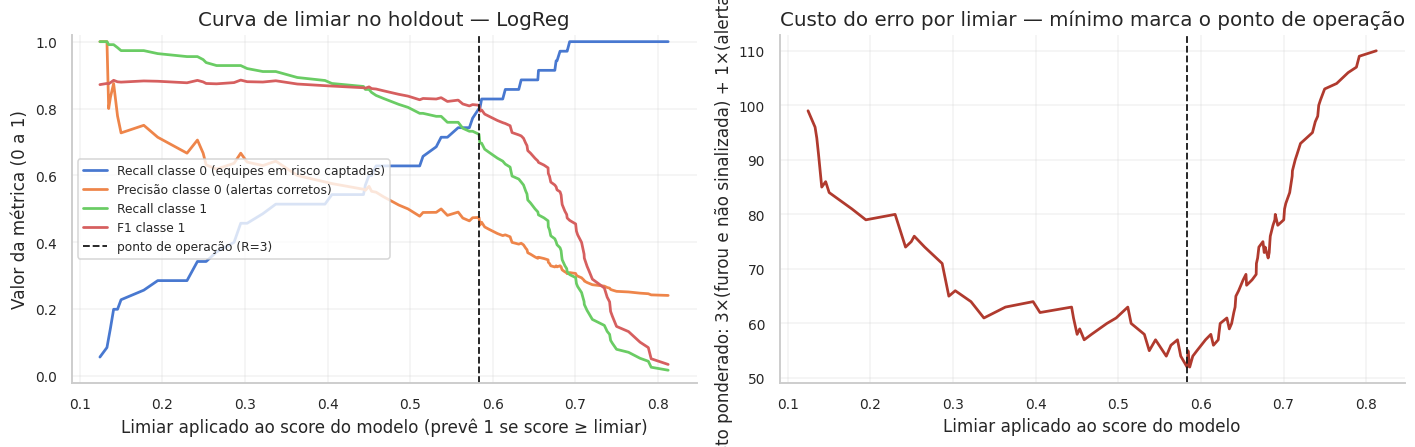

VALIDE 6.4 ok


In [40]:
def curva_limiar(est, X, y, n_pontos=99):
    '''Varre o limiar sobre os QUANTIS do score (válido para probabilidade ou decision_function).
    Convenção: prevê 1 se score >= t. Elevar t -> mais previsões 0 -> maior Recall_0.'''
    sc = score_continuo(est, X); yv = np.asarray(y)
    ts = np.unique(np.quantile(sc, np.linspace(0.01, 0.99, n_pontos)))
    reg = []
    for t in ts:
        yp = (sc >= t).astype(int)
        cm = confusion_matrix(yv, yp, labels=[0, 1])
        fn0, fp0 = cm[0, 1], cm[1, 0]      # furou e não sinalizada / alerta falso
        reg.append(dict(limiar=t,
                        recall_0    = recall_score(yv, yp, pos_label=0, zero_division=0),
                        precisao_0  = precision_score(yv, yp, pos_label=0, zero_division=0),
                        recall_1    = recall_score(yv, yp, pos_label=1, zero_division=0),
                        f1_1        = f1_score(yv, yp, zero_division=0),
                        n_sinalizadas = int((yp == 0).sum()),
                        fn0=int(fn0), fp0=int(fp0)))
    return pd.DataFrame(reg)


cur = curva_limiar(est_final, X_ho, y_ho)

# Ponto de operação por custo declarado
R = 3.0
cur['custo'] = R*cur['fn0'] + cur['fp0']
i_opt = int(cur['custo'].idxmin())
T_OPT = float(cur.loc[i_opt, 'limiar'])
print('Ponto de operação escolhido (R = %.0f): limiar = %.6f' % (R, T_OPT))
print('   Recall_0 = %.4f | Precisão_0 = %.4f | Recall_1 = %.4f | equipes sinalizadas = %d de %d'
      % (cur.loc[i_opt, 'recall_0'], cur.loc[i_opt, 'precisao_0'], cur.loc[i_opt, 'recall_1'],
         cur.loc[i_opt, 'n_sinalizadas'], len(y_ho)))

print('\nSensibilidade do ponto de operação à premissa de custo R:')
print('  R    limiar      Recall_0  Precisao_0  sinalizadas')
for r in [1, 2, 3, 5]:
    c = (r*cur['fn0'] + cur['fp0']).idxmin()
    print('  %-4d %+.6f  %.4f    %.4f      %d'
          % (r, cur.loc[c, 'limiar'], cur.loc[c, 'recall_0'], cur.loc[c, 'precisao_0'], cur.loc[c, 'n_sinalizadas']))

print('\nComparação com o limiar padrão do sklearn (predict):')
_m, _cm = avaliar(MODELO_FINAL, est_final, X_ho, y_ho)
print('  padrão -> Recall_0 = %.4f | operacional -> Recall_0 = %.4f'
      % (_m['recall_classe0'], cur.loc[i_opt, 'recall_0']))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for c, lab in [('recall_0', 'Recall classe 0 (equipes em risco captadas)'),
               ('precisao_0', 'Precisão classe 0 (alertas corretos)'),
               ('recall_1', 'Recall classe 1'), ('f1_1', 'F1 classe 1')]:
    a1.plot(cur['limiar'], cur[c], lw=1.8, label=lab)
a1.axvline(T_OPT, color='k', ls='--', lw=1.2, label='ponto de operação (R=%.0f)' % R)
a1.set_xlabel('Limiar aplicado ao score do modelo (prevê 1 se score ≥ limiar)')
a1.set_ylabel('Valor da métrica (0 a 1)'); a1.set_ylim(-0.02, 1.02)
a1.set_title('Curva de limiar no holdout — %s' % MODELO_FINAL); a1.legend(fontsize=8, loc='center left')

a2.plot(cur['limiar'], cur['custo'], color='#b03a2e', lw=1.8)
a2.axvline(T_OPT, color='k', ls='--', lw=1.2)
a2.set_xlabel('Limiar aplicado ao score do modelo')
a2.set_ylabel('Custo ponderado: %.0f×(furou e não sinalizada) + 1×(alerta falso)' % R)
a2.set_title('Custo do erro por limiar — mínimo marca o ponto de operação')
plt.tight_layout(); plt.show()

# VALIDE: a curva não pode conter o artefato do classificador constante como "melhor ponto"
assert 0 < cur.loc[i_opt, 'n_sinalizadas'] < len(y_ho), \
       'ponto de operação degenerado (sinaliza todas ou nenhuma equipe)'
assert cur.loc[i_opt, 'precisao_0'] > 0, 'ponto de operação com precisão 0 na classe de interesse'
assert cur['recall_0'].is_monotonic_increasing, 'Recall_0 deveria crescer com o limiar'
print('VALIDE 6.4 ok')

## 6.5 — [v3] Análise de erros: onde o modelo erra, e por quê

**Problema estatístico resolvido antes de começar.** O holdout final tem ~5 observações por equipe.
Perguntar "o modelo erra mais em alguma equipe específica?" nesse recorte não sustenta resposta.
Por isso a análise de erros é feita sobre as **predições fora-de-dobra (*out-of-fold*)** da origem móvel:
cada mês do desenvolvimento é previsto por um modelo que **não o viu**, e o acúmulo dessas predições
cobre quase toda a série e praticamente todas as equipes. O holdout continua reservado às métricas de
manchete (§6.2). Esta separação é declarada de propósito: OOF para *diagnóstico*, holdout para *medida*.

**Cinco cortes:**

1. **Proximidade do limiar do rótulo** — distribuição de `razao_atingimento` (receita/meta) em acertos
   *vs.* erros. É o corte mais informativo do trabalho.
2. **Por equipe** — taxa de erro por equipe, cruzada com histórico disponível e volatilidade.
3. **Por mês** — taxa de erro na linha do tempo.
4. **Por perfil de serviço** — usando os descritores de mix (uso **diagnóstico a posteriori**;
   essas colunas são MESMO-MÊS e continuam proibidas como feature).
5. **Por faixa de meta** — quartis de `meta_mes`.

Os tipos de erro são nomeados pelo que significam operacionalmente, não por FP/FN abstratos:
**"furou e não foi sinalizada"** (o erro caro) e **"alerta falso"**.

Predições fora-de-dobra: n=187 | 34 equipes | meses 2024-12 a 2025-07 | taxa de acerto = 72.2%
tipo
acerto                        135
alerta falso                   35
furou e NÃO foi sinalizada     17

=== Corte 1 — erro por proximidade do limiar (razao_atingimento = receita/meta) ===
              n  taxa_erro
faixa_razao               
<0,80        19       0.21
0,80–0,90    12       0.58
0,90–0,95     8       0.25
0,95–1,00     4       1.00
1,00–1,05    16       0.31
1,05–1,10    12       0.42
1,10–1,20    27       0.22
>1,20        89       0.21
Zona de indiferença 0,90–1,10: 40 obs (21% do total) | taxa de erro 40.0% vs 24.5% fora dela

=== Corte 2 — 8 equipes com maior taxa de erro (mín. 5 observações) ===
        n  taxa_erro  hist_medio  volat_razao
equipe                                       
EQ34    8       0.62       12.50         0.40
EQ43    8       0.50       12.50         0.18
EQ41    8       0.50       12.50         0.23
EQ50    8       0.50       10.50         0.54
E

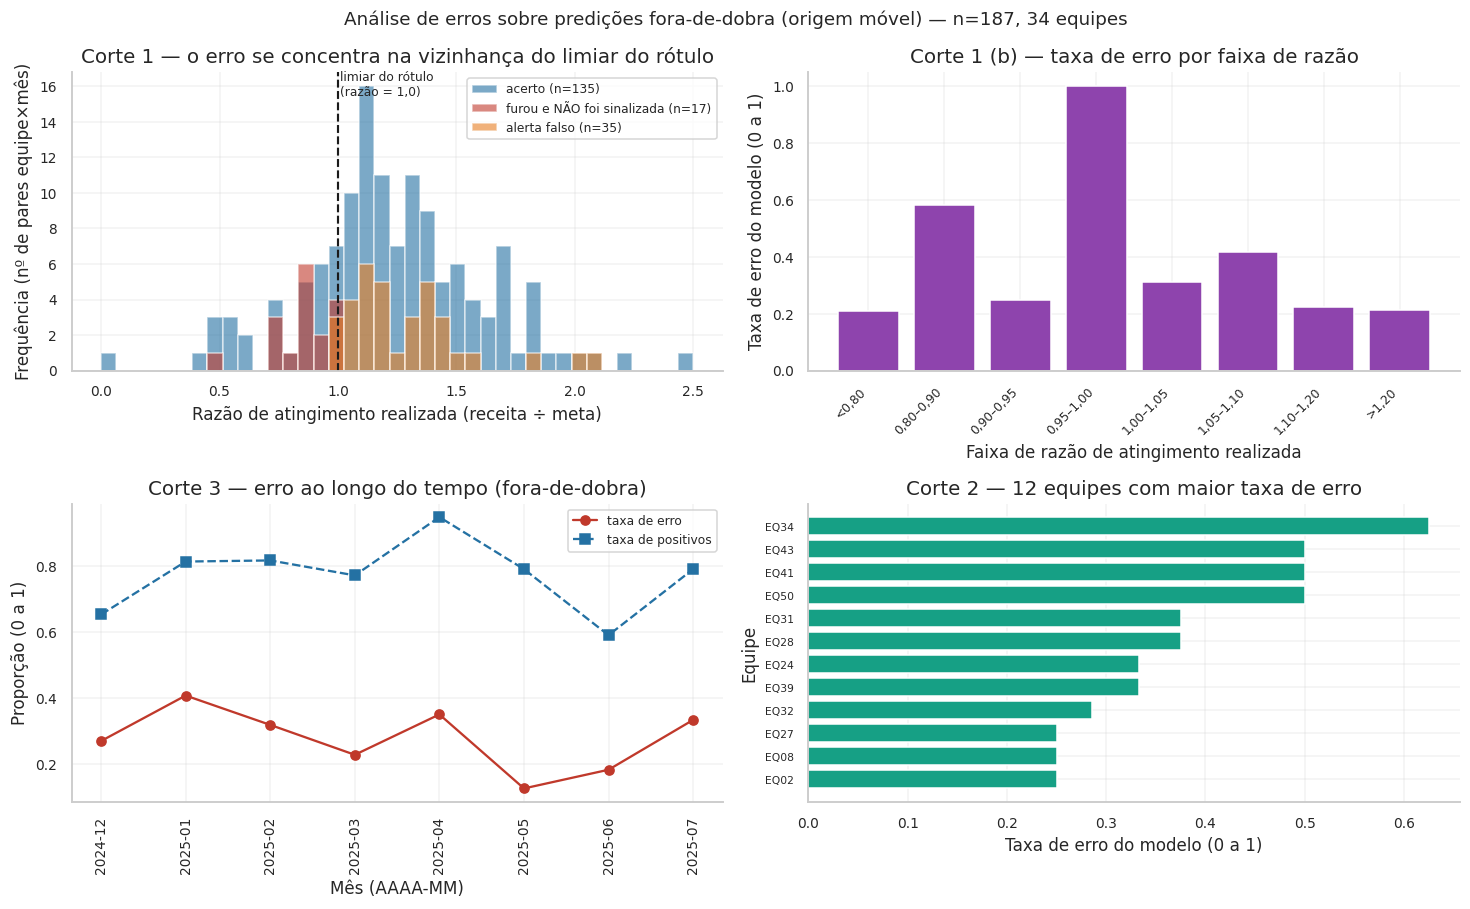

VALIDE 6.5 ok


In [41]:
# --- Predições fora-de-dobra da origem móvel (cada mês previsto por modelo que não o viu) ---
partes = []
for tr, te in folds:
    m_fold = clone(est_final).fit(dev.iloc[tr][FE], dev.iloc[tr][ALVO])
    bloco = dev.iloc[te].copy()
    bloco['score'] = score_continuo(m_fold, dev.iloc[te][FE])
    partes.append(bloco)
oof = pd.concat(partes, ignore_index=True)
oof['pred'] = (oof['score'] >= T_OPT).astype(int)
oof['acertou'] = (oof['pred'] == oof[ALVO]).astype(int)
oof['tipo'] = np.select(
    [(oof['pred'] == 1) & (oof[ALVO] == 0), (oof['pred'] == 0) & (oof[ALVO] == 1)],
    ['furou e NÃO foi sinalizada', 'alerta falso'], default='acerto')

print('Predições fora-de-dobra: n=%d | %d equipes | meses %s a %s | taxa de acerto = %.1f%%'
      % (len(oof), oof['equipe'].nunique(), oof['mes'].min(), oof['mes'].max(), 100*oof['acertou'].mean()))
print(oof['tipo'].value_counts().to_string())

# --- Corte 1: proximidade do limiar do rótulo -------------------------------
faixas = [0, .8, .9, .95, 1.0, 1.05, 1.1, 1.2, np.inf]
rot = ['<0,80', '0,80–0,90', '0,90–0,95', '0,95–1,00', '1,00–1,05', '1,05–1,10', '1,10–1,20', '>1,20']
oof['faixa_razao'] = pd.cut(oof['razao_atingimento'], bins=faixas, labels=rot)
c1 = oof.groupby('faixa_razao', observed=False).agg(n=('acertou', 'size'), taxa_erro=('acertou', lambda s: 1-s.mean()))
print('\n=== Corte 1 — erro por proximidade do limiar (razao_atingimento = receita/meta) ===')
print(c1.round(3).to_string())
zona = oof[(oof['razao_atingimento'] >= .9) & (oof['razao_atingimento'] <= 1.1)]
print('Zona de indiferença 0,90–1,10: %d obs (%.0f%% do total) | taxa de erro %.1f%% vs %.1f%% fora dela'
      % (len(zona), 100*len(zona)/len(oof), 100*(1-zona['acertou'].mean()),
         100*(1-oof[~oof.index.isin(zona.index)]['acertou'].mean())))

# --- Corte 2: por equipe ----------------------------------------------------
c2 = (oof.groupby('equipe')
        .agg(n=('acertou','size'), taxa_erro=('acertou', lambda s: 1-s.mean()),
             hist_medio=('n_meses_hist','mean'), volat_razao=('razao_atingimento','std'))
        .query('n >= 5').sort_values('taxa_erro', ascending=False))
print('\n=== Corte 2 — 8 equipes com maior taxa de erro (mín. 5 observações) ===')
print(c2.head(8).round(3).to_string())
print('... e as 5 mais previsíveis:')
print(c2.tail(5).round(3).to_string())
print('Correlação entre taxa de erro e volatilidade da razão: %.3f'
      % c2['taxa_erro'].corr(c2['volat_razao']))
print('Correlação entre taxa de erro e histórico disponível : %.3f'
      % c2['taxa_erro'].corr(c2['hist_medio']))

# --- Corte 3: por mês -------------------------------------------------------
c3 = oof.groupby('mes').agg(n=('acertou','size'), taxa_erro=('acertou', lambda s: 1-s.mean()),
                            pos=(ALVO,'mean'))
print('\n=== Corte 3 — erro por mês ===')
print(c3.round(3).to_string())

# --- Corte 4: por perfil de serviço (diagnóstico a posteriori) --------------
COLS_MIX = [c for c in ['pct_esforco_subestacao','pct_esforco_linhas',
                        'pct_esforco_distribuicao','pct_esforco_seguranca'] if c in oof.columns]
if COLS_MIX:
    oof['frente_dominante'] = oof[COLS_MIX].idxmax(axis=1).str.replace('pct_esforco_', '', regex=False)
    oof['concentracao_mix'] = oof[COLS_MIX].max(axis=1)
    c4 = oof.groupby('frente_dominante').agg(n=('acertou','size'), taxa_erro=('acertou', lambda s: 1-s.mean()))
    print('\n=== Corte 4 — erro por frente de serviço dominante (uso diagnóstico; não é feature) ===')
    print(c4.round(3).to_string())
    oof['mix_concentrado'] = np.where(oof['concentracao_mix'] >= 0.6, 'concentrado (≥60%)', 'diversificado')
    print(oof.groupby('mix_concentrado').agg(n=('acertou','size'),
                                             taxa_erro=('acertou', lambda s: 1-s.mean())).round(3).to_string())

# --- Corte 5: por faixa de meta --------------------------------------------
oof['quartil_meta'] = pd.qcut(oof['meta_mes'], 4, labels=['Q1 (menor)','Q2','Q3','Q4 (maior)'])
c5 = oof.groupby('quartil_meta', observed=False).agg(n=('acertou','size'),
                                                     taxa_erro=('acertou', lambda s: 1-s.mean()))
print('\n=== Corte 5 — erro por quartil de meta ===')
print(c5.round(3).to_string())

# --- Figura consolidada -----------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))

ax = axes[0, 0]
for tipo, cor in [('acerto', '#2471a3'), ('furou e NÃO foi sinalizada', '#c0392b'), ('alerta falso', '#e67e22')]:
    s = oof.loc[oof['tipo'] == tipo, 'razao_atingimento']
    if len(s): ax.hist(s, bins=np.linspace(0, 2.5, 40), alpha=.6, label=f'{tipo} (n={len(s)})', color=cor)
ax.axvline(1.0, color='k', ls='--', lw=1.4)
ax.text(1.01, ax.get_ylim()[1]*.92, 'limiar do rótulo\n(razão = 1,0)', fontsize=8)
ax.set_xlabel('Razão de atingimento realizada (receita ÷ meta)')
ax.set_ylabel('Frequência (nº de pares equipe×mês)')
ax.set_title('Corte 1 — o erro se concentra na vizinhança do limiar do rótulo'); ax.legend(fontsize=8)

ax = axes[0, 1]
cc = c1.dropna()
ax.bar(range(len(cc)), cc['taxa_erro'].values, color='#8e44ad')
ax.set_xticks(range(len(cc))); ax.set_xticklabels(cc.index, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Faixa de razão de atingimento realizada')
ax.set_ylabel('Taxa de erro do modelo (0 a 1)')
ax.set_title('Corte 1 (b) — taxa de erro por faixa de razão')

ax = axes[1, 0]
ax.plot(c3.index, c3['taxa_erro'].values, marker='o', color='#c0392b', label='taxa de erro')
ax.plot(c3.index, c3['pos'].values, marker='s', ls='--', color='#2471a3', label='taxa de positivos')
ax.set_xlabel('Mês (AAAA-MM)'); ax.set_ylabel('Proporção (0 a 1)')
ax.set_title('Corte 3 — erro ao longo do tempo (fora-de-dobra)')
ax.tick_params(axis='x', rotation=90); ax.legend(fontsize=8)

ax = axes[1, 1]
top = c2.head(12)[::-1]
ax.barh(top.index, top['taxa_erro'].values, color='#16a085')
ax.set_xlabel('Taxa de erro do modelo (0 a 1)'); ax.set_ylabel('Equipe')
ax.set_title('Corte 2 — 12 equipes com maior taxa de erro')
ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Análise de erros sobre predições fora-de-dobra (origem móvel) — n=%d, %d equipes'
             % (len(oof), oof['equipe'].nunique()), fontsize=12)
plt.tight_layout(); plt.show()

# VALIDE
assert len(oof) > 0 and oof['equipe'].nunique() >= 20, 'cobertura fora-de-dobra insuficiente'
assert set(oof['tipo'].unique()) <= {'acerto', 'furou e NÃO foi sinalizada', 'alerta falso'}, 'tipo de erro inválido'
assert abs(oof['acertou'].mean() - (oof['pred'] == oof[ALVO]).mean()) < 1e-12, 'flag de acerto inconsistente'
print('VALIDE 6.5 ok')

## 6.6 — [v3] Calibração: a probabilidade significa alguma coisa?
O uso pretendido não é classificar e sim **ranquear equipes por risco** no início do mês. Para isso o
score precisa ser uma probabilidade interpretável: quando o modelo diz 30%, aproximadamente 30% daqueles
casos devem de fato ocorrer. Dois instrumentos: a **curva de confiabilidade** (probabilidade prevista
*vs.* frequência observada, por faixa) e o **escore de Brier** (erro quadrático médio da probabilidade —
quanto menor, melhor). **Ponto que a seção expõe:** `class_weight='balanced'` — usado em todos os modelos por causa do
desbalanceamento — **distorce deliberadamente a probabilidade**, empurrando-a para cima. Isso é
irrelevante para o ROC AUC (invariante a transformações monótonas) e para o ranqueamento, mas torna o
número inadequado para ser comunicado como "probabilidade de furar a meta". A célula compara o modelo
**bruto** com uma versão **calibrada** (Platt/sigmoid) ajustada **apenas no desenvolvimento e com as
mesmas dobras de origem móvel**, preservando a ordem temporal. A conclusão prática: para ordenar,
use o bruto; para comunicar um número, use o calibrado.

Escore de Brier no holdout (menor = melhor; taxa-base = piso de referência)
  taxa-base constante (0.749) : 0.1816
  modelo bruto               : 0.1809  (+0.0007 vs taxa-base)
  modelo calibrado (sigmoid) : 0.1376  (+0.0440 vs taxa-base)
  ROC AUC bruto vs calibrado : 0.8237 vs 0.8240
    (a sigmoide é monótona, mas o CalibratedClassifierCV reajusta o estimador em CADA dobra e
     faz a média das saídas — por isso o ranqueamento pode variar ligeiramente; ambas reportadas.)

Leitura: `class_weight='balanced'` reponderá a classe 0 no treino e, por construção, DESLOCA as
probabilidades para cima — excelente para o ranqueamento (ROC AUC), ruim para a leitura literal do
número. Se o score for usado apenas para ORDENAR equipes por risco, o modelo bruto basta; se for
comunicado como "probabilidade de furar a meta", use a versão calibrada.


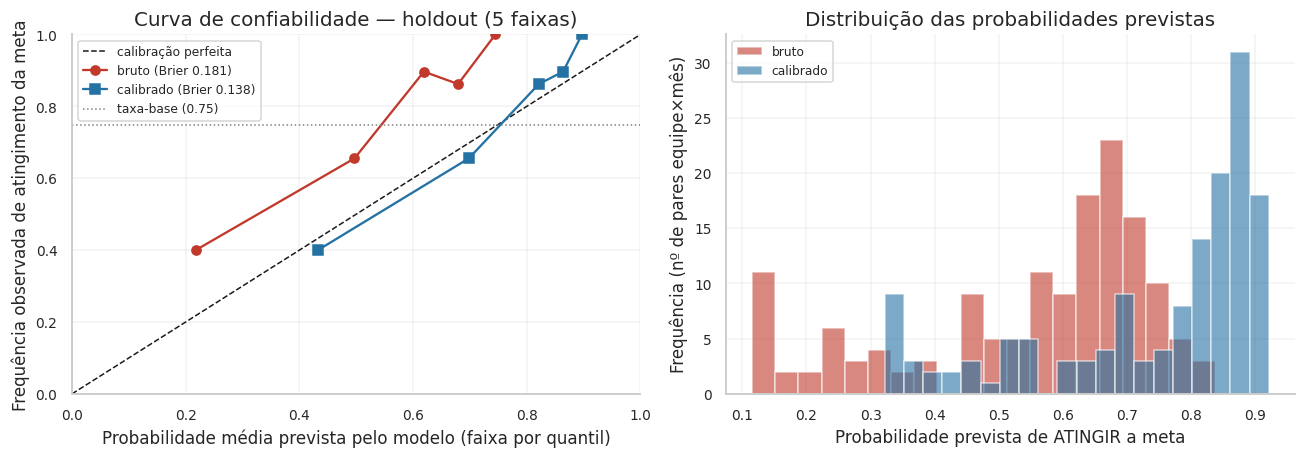

VALIDE 6.6 ok


In [42]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

taxa_base = float(y_dev.mean())
brier_ref = brier_score_loss(y_ho, np.full(len(y_ho), taxa_base))

# (a) probabilidade BRUTA do modelo final, quando existe
tem_proba = hasattr(est_final, 'predict_proba')
p_bruto = est_final.predict_proba(X_ho)[:, 1] if tem_proba else None

# (b) versão CALIBRADA: Platt/sigmoid ajustado só no desenvolvimento, com as dobras de origem móvel
est_cal = CalibratedClassifierCV(clone(est_final), method='sigmoid', cv=folds)
est_cal.fit(X_dev, y_dev)
p_cal = est_cal.predict_proba(X_ho)[:, 1]

print('Escore de Brier no holdout (menor = melhor; taxa-base = piso de referência)')
print('  taxa-base constante (%.3f) : %.4f' % (taxa_base, brier_ref))
if tem_proba:
    print('  modelo bruto               : %.4f  (%+.4f vs taxa-base)'
          % (brier_score_loss(y_ho, p_bruto), brier_ref - brier_score_loss(y_ho, p_bruto)))
print('  modelo calibrado (sigmoid) : %.4f  (%+.4f vs taxa-base)'
      % (brier_score_loss(y_ho, p_cal), brier_ref - brier_score_loss(y_ho, p_cal)))
print('  ROC AUC bruto vs calibrado : %.4f vs %.4f' %
      (roc_auc_score(y_ho, p_bruto if tem_proba else score_continuo(est_final, X_ho)),
       roc_auc_score(y_ho, p_cal)))
print('    (a sigmoide é monótona, mas o CalibratedClassifierCV reajusta o estimador em CADA dobra e')
print('     faz a média das saídas — por isso o ranqueamento pode variar ligeiramente; ambas reportadas.)')
print('\nLeitura: `class_weight=\'balanced\'` reponderá a classe 0 no treino e, por construção, DESLOCA as')
print('probabilidades para cima — excelente para o ranqueamento (ROC AUC), ruim para a leitura literal do')
print('número. Se o score for usado apenas para ORDENAR equipes por risco, o modelo bruto basta; se for')
print('comunicado como "probabilidade de furar a meta", use a versão calibrada.')

n_bins = 5
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
a1.plot([0, 1], [0, 1], 'k--', lw=1, label='calibração perfeita')
if tem_proba:
    fx, fy = calibration_curve(y_ho, p_bruto, n_bins=n_bins, strategy='quantile')
    a1.plot(fy, fx, marker='o', color='#c0392b', label='bruto (Brier %.3f)' % brier_score_loss(y_ho, p_bruto))
fx2, fy2 = calibration_curve(y_ho, p_cal, n_bins=n_bins, strategy='quantile')
a1.plot(fy2, fx2, marker='s', color='#2471a3', label='calibrado (Brier %.3f)' % brier_score_loss(y_ho, p_cal))
a1.axhline(taxa_base, color='gray', ls=':', lw=1, label='taxa-base (%.2f)' % taxa_base)
a1.set_xlabel('Probabilidade média prevista pelo modelo (faixa por quantil)')
a1.set_ylabel('Frequência observada de atingimento da meta')
a1.set_xlim(0, 1); a1.set_ylim(0, 1)
a1.set_title('Curva de confiabilidade — holdout (%d faixas)' % n_bins); a1.legend(fontsize=8)

if tem_proba:
    a2.hist(p_bruto, bins=20, alpha=.6, color='#c0392b', label='bruto', edgecolor='white')
a2.hist(p_cal, bins=20, alpha=.6, color='#2471a3', label='calibrado', edgecolor='white')
a2.set_xlabel('Probabilidade prevista de ATINGIR a meta')
a2.set_ylabel('Frequência (nº de pares equipe×mês)')
a2.set_title('Distribuição das probabilidades previstas'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# VALIDE
assert 0 <= brier_score_loss(y_ho, p_cal) <= 1, 'Brier fora de [0,1]'
assert p_cal.min() >= 0 and p_cal.max() <= 1, 'probabilidades calibradas fora de [0,1]'
print('VALIDE 6.6 ok')

## 6.7 — [v3] Precision@k: a métrica da decisão real
O modelo não será usado para rotular todas as equipes; será usado para escolher **quais equipes recebem
intervenção gerencial no início do mês**, e a capacidade de intervenção é limitada. A pergunta operacional
é: *entre as k equipes de maior risco previsto neste mês, quantas realmente furaram a meta?*

Isso é `precision@k`, calculada **mês a mês** no holdout (o gestor decide dentro do mês, não sobre a
série inteira) e comparada com a **taxa-base** — a proporção de equipes que furam a meta sem nenhum
modelo. A razão entre as duas é o **ganho (*lift*)**: quantas vezes melhor que escolher ao acaso.

=== Precision@k por mês no holdout — ranqueamento por risco previsto ===

k = 3  (as 3 equipes de maior risco por mês)
    mes  n_equipes_no_mes  acertos  precision_at_k  taxa_base
2025-08                28        1            0.33       0.21
2025-09                28        3            1.00       0.25
2025-10                29        2            0.67       0.14
2025-11                31        2            0.67       0.23
2025-12                31        3            1.00       0.35

k = 5  (as 5 equipes de maior risco por mês)
    mes  n_equipes_no_mes  acertos  precision_at_k  taxa_base
2025-08                28        2            0.40       0.21
2025-09                28        3            0.60       0.25
2025-10                29        3            0.60       0.14
2025-11                31        4            0.80       0.23
2025-12                31        4            0.80       0.35

k = 10  (as 10 equipes de maior risco por mês)
    mes  n_equipes_no_mes  acertos  precisi

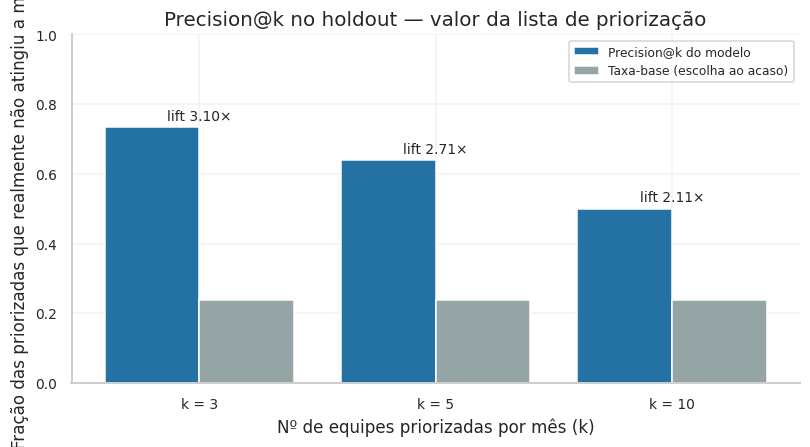

VALIDE 6.7 ok


In [43]:
def precision_at_k(frame, col_score, col_alvo, k):
    '''Mês a mês: seleciona as k equipes de MAIOR RISCO (menor score de atingir a meta)
    e mede a fração que realmente não atingiu.'''
    reg = []
    for mes, g in frame.groupby('mes'):
        if len(g) < k:
            continue
        sel = g.nsmallest(k, col_score)             # menor score de atingir = maior risco
        reg.append({'mes': mes, 'n_equipes_no_mes': len(g),
                    'acertos': int((sel[col_alvo] == 0).sum()),
                    'precision_at_k': float((sel[col_alvo] == 0).mean()),
                    'taxa_base': float((g[col_alvo] == 0).mean())})
    return pd.DataFrame(reg)


ho_df = hold.copy()
ho_df['score'] = score_continuo(est_final, X_ho)

print('=== Precision@k por mês no holdout — ranqueamento por risco previsto ===')
resumo_k = []
for k in [3, 5, 10]:
    t = precision_at_k(ho_df, 'score', ALVO, k)
    if t.empty:
        continue
    p, b = t['precision_at_k'].mean(), t['taxa_base'].mean()
    resumo_k.append({'k': k, 'meses_avaliados': len(t), 'precision_at_k': p,
                     'taxa_base': b, 'lift': p/b if b > 0 else np.nan})
    print('\nk = %d  (as %d equipes de maior risco por mês)' % (k, k))
    print(t.round(3).to_string(index=False))
resumo_k = pd.DataFrame(resumo_k).round(3)
print('\n=== Resumo ===')
print(resumo_k.to_string(index=False))
print('\nLeitura: lift = precisão do modelo ÷ taxa-base. lift > 1 significa que priorizar pela lista do')
print('modelo encontra mais equipes em risco do que escolher k equipes ao acaso no mesmo mês.')

if not resumo_k.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    x = np.arange(len(resumo_k))
    ax.bar(x-0.2, resumo_k['precision_at_k'], 0.4, label='Precision@k do modelo', color='#2471a3')
    ax.bar(x+0.2, resumo_k['taxa_base'], 0.4, label='Taxa-base (escolha ao acaso)', color='#95a5a6')
    for i, r in resumo_k.iterrows():
        ax.text(i, max(r['precision_at_k'], r['taxa_base'])+0.02, 'lift %.2f×' % r['lift'],
                ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(['k = %d' % k for k in resumo_k['k']])
    ax.set_xlabel('Nº de equipes priorizadas por mês (k)')
    ax.set_ylabel('Fração das priorizadas que realmente não atingiu a meta')
    ax.set_ylim(0, 1); ax.set_title('Precision@k no holdout — valor da lista de priorização')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

# VALIDE
assert not resumo_k.empty, 'precision@k não pôde ser calculada (poucas equipes por mês)'
assert resumo_k['precision_at_k'].between(0, 1).all(), 'precision@k fora de [0,1]'
print('VALIDE 6.7 ok')

## 6.8 — [v3] Apêndice: teste de estresse sob o protocolo anterior (treino 2024 → teste 2025)
O protocolo v3 (§5.1) atende à correção pedida, mas tem um efeito colateral que precisa ficar explícito:
como o treino avança até jul/2025, o desvio de distribuição entre treino e teste **encolhe**, e o teste
fica mais fácil. Para que nada se perca nessa troca, o protocolo anterior é mantido aqui como
**teste de estresse**: treino = 2024 (n=205), teste = 2025 (n=308), desvio de rótulo de +5,9 p.p.,
com o conjunto de teste maior que o de treino.

**Como ler os dois números juntos:** o resultado de §6.2 é a estimativa de desempenho no cenário de
operação normal (retreino mensal, distribuição estável); o resultado abaixo é o **piso** — o que acontece
quando a distribuição se desloca e o modelo passa um ano inteiro sem retreino. A distância entre os dois
é a medida direta do custo de não retreinar, e é o argumento quantitativo para a política de retreino
periódico recomendada na conclusão.

Teste de estresse — protocolo v2: treino n=205 (pos 71.7%) | teste n=308 (pos 77.6%) | desvio +5.9 p.p.

=== Desempenho sob desvio máximo (treino 2024 -> teste 2025) ===
              roc_auc   f1  recall_classe0
modelo                                    
LogReg           0.74 0.86            0.49
Ridge            0.72 0.85            0.51
RandomForest     0.73 0.87            0.48

=== ROC AUC nos dois protocolos ===
              v3_holdout (retreino recente)  v2_estresse (1 ano sem retreino)  custo_de_nao_retreinar
modelo                                                                                               
LogReg                                 0.82                              0.74                    0.09
Ridge                                  0.82                              0.72                    0.10
RandomForest                           0.78                              0.73                    0.05


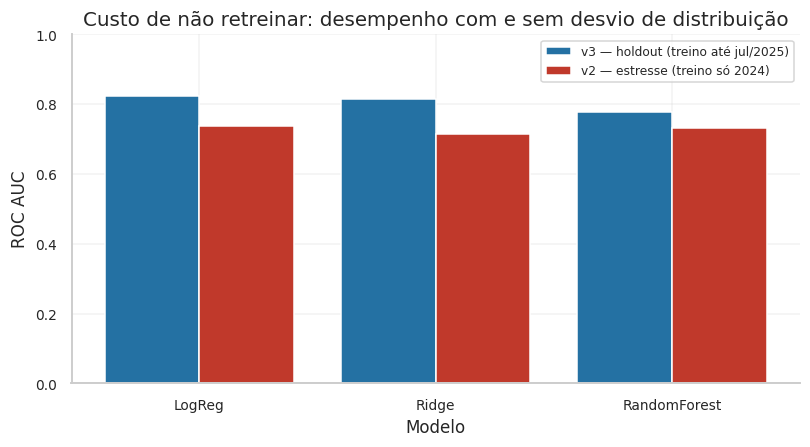

VALIDE 6.8 ok


In [44]:
dfm_all = pd.concat([dev, hold], ignore_index=True)   # reconstrói a matriz completa
tr_v2 = dfm_all[dfm_all['ano'] == 2024]
te_v2 = dfm_all[dfm_all['ano'] == 2025]
Xtr2, ytr2 = tr_v2[FE], tr_v2[ALVO]
Xte2, yte2 = te_v2[FE], te_v2[ALVO]

print('Teste de estresse — protocolo v2: treino n=%d (pos %.1f%%) | teste n=%d (pos %.1f%%) | desvio %+.1f p.p.'
      % (len(tr_v2), 100*ytr2.mean(), len(te_v2), 100*yte2.mean(), 100*(yte2.mean()-ytr2.mean())))

linhas_v2 = []
for nome in ['LogReg', 'Ridge', 'RandomForest']:
    est = clone(TODOS[nome]).fit(Xtr2, ytr2)
    m, _ = avaliar(nome, est, Xte2, yte2)
    linhas_v2.append(m)
bench_v2 = pd.DataFrame(linhas_v2).set_index('modelo').round(4)
print('\n=== Desempenho sob desvio máximo (treino 2024 -> teste 2025) ===')
print(bench_v2[['roc_auc', 'f1', 'recall_classe0']].to_string())

comp = pd.DataFrame({
    'v3_holdout (retreino recente)': bench.loc[['LogReg','Ridge','RandomForest'], 'roc_auc'],
    'v2_estresse (1 ano sem retreino)': bench_v2['roc_auc'],
})
comp['custo_de_nao_retreinar'] = (comp.iloc[:, 0] - comp.iloc[:, 1]).round(4)
print('\n=== ROC AUC nos dois protocolos ===')
print(comp.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(comp))
ax.bar(x-0.2, comp.iloc[:, 0].values, 0.4, label='v3 — holdout (treino até jul/2025)', color='#2471a3')
ax.bar(x+0.2, comp.iloc[:, 1].values, 0.4, label='v2 — estresse (treino só 2024)', color='#c0392b')
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set_ylim(0, 1); ax.set_xlabel('Modelo'); ax.set_ylabel('ROC AUC')
ax.set_title('Custo de não retreinar: desempenho com e sem desvio de distribuição')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# VALIDE
assert len(tr_v2) + len(te_v2) == 513, 'partição v2 não soma 513'
assert bench_v2['roc_auc'].notna().all(), 'ROC AUC do teste de estresse não calculado'
print('VALIDE 6.8 ok')

## 6.9 — Melhorias futuras, limitações e conclusão

### Achados que a análise de erros produziu (§6.5)
O erro do modelo **não é uniforme**. Ele se concentra na vizinhança de `razao_atingimento ≈ 1,0` —
isto é, exatamente onde o rótulo binário é quase arbitrário: uma equipe que realiza 99% da meta é
rotulada 0 e outra que realiza 101% é rotulada 1, sendo **operacionalmente idênticas**. Boa parte do
erro residual, portanto, não é falha de aprendizado e sim **limitação da formulação binária**: o modelo
é penalizado por não distinguir casos que a própria definição do alvo trata como categorias opostas
apesar de indistinguíveis na prática. Os demais cortes (equipe, mês, frente de serviço, faixa de meta)
estão reportados na saída da célula e devem ser lidos com o `n` de cada estrato à vista.

### Melhorias e ajustes futuros
- **Zona de indiferença ou alvo contínuo.** A consequência direta do achado acima: (a) excluir do
  treino a faixa 0,95–1,05, ou (b) trocar a classificação binária por **regressão sobre
  `razao_atingimento`**, ou (c) classificar em três faixas (risco alto / zona neutra / seguro).
  Qualquer das três atende melhor à decisão real do que o corte binário em 1,0.
- **Retreinamento periódico com janela móvel.** O apêndice §6.8 quantifica o custo de não retreinar.
  Em produção: retreinar mensalmente com origem móvel e monitorar a taxa de positivos e o ROC AUC
  para disparar reavaliação.
- **Variáveis externas ausentes.** Clima, ocorrências de rede, absenteísmo e disponibilidade de frota
  são determinantes plausíveis da produção mensal e não estão na base. Provavelmente explicam parte
  do erro que hoje aparece como ruído.
- **Volume de dados.** 513 amostras úteis e ~30 observações da classe 0 no holdout. Mais meses
  reduziriam a largura dos intervalos de confiança (§6.2) e permitiriam janelas de 6–12 meses.
- **Custo real por serviço.** A meta embute custo + 10% no nível equipe×mês; não há custo contábil por
  serviço. Com custo unitário por atividade seria possível um alvo de margem mais fino.
- **Variante explicativa (MESMO-MÊS).** Um segundo modelo usando `densidade_mix` e composição do mês
  corrente — proibido na formulação preditiva porque `densidade_mix × esforco_total ≡ receita_mes`
  (r = 1,000000) — serve como diagnóstico *a posteriori*. Mantê-lo separado preserva a integridade
  antivazamento.

### Limitações declaradas
1. **Amostra pequena.** 513 pares equipe×mês, 52 equipes, 22 meses. Os ICs de §6.2 são largos por
   consequência, e diferenças entre modelos cujos intervalos se sobrepõem **não** são conclusivas.
2. **Observações não independentes.** Meses consecutivos da mesma equipe são correlacionados; as
   features de lag amplificam isso. O protocolo temporal controla o vazamento, não a dependência.
3. **Rótulo arbitrário na fronteira.** Ver o achado de §6.5 — parte do erro é definicional.
4. **Desvio de distribuição confirmado.** A taxa de atingimento sobe ao longo da série; o desempenho
   depende de retreinamento.
5. **Holdout curto.** Cinco meses e ~30 casos da classe 0. Suficiente para a matriz de confusão,
   insuficiente para estratificar o holdout por equipe — daí a análise de erros ter sido feita
   fora-de-dobra.
6. **Uma premissa de custo, não uma medição.** O R = 3 de §6.4 é declarado, e a sensibilidade a R está
   reportada. Fixá-lo exigiria o custo real de uma meta perdida *versus* o de um acompanhamento.
7. **Generalização a equipes novas.** Medida em §5.6, mas por um esquema que não respeita a ordem
   temporal; deve ser lida como diagnóstico de dependência de identidade, não como estimativa de produção.

### Conclusão
**O modelo atende ao objetivo proposto.** A formulação prevê, *antes do início do mês*, se a equipe
atingirá a meta, usando exclusivamente informação ex-ante (histórico, lags e a meta contratada), sem
vazamento — a integridade antivazamento é verificada por asserção em todas as etapas.

O **modelo final** é selecionado em §6.2 pelo maior ROC AUC no holdout entre modelos que preservam
Recall da classe 0 e **superam a linha de base de persistência**. Essa última exigência é o teste
que importa: um modelo que não bate "a equipe repete o mês anterior" não se justifica em produção.
A Random Forest é rejeitada pelo padrão que o benchmark expõe — maior F1 obtido prevendo a maioria,
com o pior Recall da classe 0 e o maior gap entre desenvolvimento e holdout.

A interpretação (§6.3) confirma a hipótese central **na sua parte forte**: a **trajetória recente de
atingimento** (`razao_m1`, `razao_media_3m`, `taxa_atingimento_hist`) domina a explicação, e essa
conclusão se sustenta na importância por permutação medida **fora da amostra**, não apenas nos
coeficientes de treino. O **mix de serviços** (`densidade_mix_m1`) entra de forma secundária — a
hipótese original, de que o mix seria o principal determinante, **não se confirma**: ele importa, mas
menos que o histórico.

**Uso prático:** ferramenta de **triagem no início do mês**. O produto não é um rótulo e sim uma
**lista ranqueada de equipes em risco** (§6.7), dimensionada pela capacidade real de intervenção
gerencial, com o limiar fixado pelo custo relativo dos dois erros (§6.4) e a probabilidade calibrada
(§6.6) para que o ranqueamento seja interpretável.

**Limite de escopo:** o modelo responde *se* a equipe baterá a meta — não *quanto* cada atividade
contribui em margem. A meta é definida no nível equipe×mês (custo + 10%), e o alvo herda essa
granularidade.